<a href="https://colab.research.google.com/github/vedantikanade/Data_Mining_Colabs_Assignment2/blob/main/final_pandas_zero_to_hero.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🐼 pandas: Zero to Hero
## One messy dataset, ten parts, every operation built up from the one before

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com)
![Python](https://img.shields.io/badge/Python-3.10+-blue.svg)
![No installs](https://img.shields.io/badge/installs-none%20needed-brightgreen.svg)
![CPU](https://img.shields.io/badge/runs%20on-CPU%20only-brightgreen.svg)
![Level](https://img.shields.io/badge/level-zero%20to%20hero-orange.svg)

---
<div style="background: linear-gradient(135deg, #11998e 0%, #38ef7d 100%); padding: 28px; border-radius: 18px; color: white; margin: 12px 0;">


### You have a spreadsheet with 900 rows and a question about it.

The store manager wants to know which product sells best on weekends, by region, excluding the days the till was double-scanned. In a spreadsheet that is an afternoon of filtering, copying, and quietly getting one of the filters wrong.

In pandas it is four lines. But only if you know which four — and the gap between "I have seen `groupby` before" and "I can write those four lines without looking anything up" is what this notebook closes.

We will not use a clean teaching dataset. Ours has missing values in three columns for three *different reasons*, a price column that arrived as text with a dollar sign in it, fourteen duplicated rows, store names in inconsistent case, and six orders with a negative quantity. That is what real data looks like, and handling it is not an appendix to learning pandas — it is most of the job.


</div>

<div style="background-color: #f3e5f5; border-left: 5px solid #9c27b0; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📖 How to read this notebook

**Run every cell in order.** Each part uses names the previous parts defined, and the dataset is built once in this part and never re-downloaded.

**Every figure and every printed table has a caption** underneath explaining what you should actually see in it, ending with the most common way people misread it.

**The traps are marked ⚠️.** pandas has more sharp edges than almost any library you will use — chained assignment, views versus copies, silent dtype changes, alignment on index rather than position. Each one gets shown as a *failure first*, then explained, then fixed. You will remember the ones that bit you.

</div>

## 🎯 What you will be able to do

By the end you will be able to:

1. **Say what a Series and a DataFrame actually are** — and why the index is the thing that makes pandas different from a spreadsheet.
2. **Select rows and columns without guessing** — `loc`, `iloc`, boolean masks, and why `df[...]` means three different things depending on what you put in it.
3. **Clean data that arrived broken** — missing values, wrong dtypes, duplicates, whitespace.
4. **Transform columns without a `for` loop** — vectorised arithmetic, string methods, datetime accessors.
5. **Answer grouped questions** — split-apply-combine, multiple aggregations, and the difference between `agg`, `transform` and `apply`.
6. **Reshape between long and wide** — `pivot`, `melt`, `merge`, `concat`, and the four join types.
7. **Work with time** — parsing, resampling, rolling windows.
8. **Plot straight from a DataFrame** and know when your code is slow because you wrote a loop.

---
## 🗺️ The Ten Parts

Each part builds on the one before it, on a single dataset that is introduced in Part 0 and never leaves. By the end you will have cleaned it, reshaped it, grouped it, resampled it and plotted it.

| Part | What it covers | |
|---|---|---|
| **0** | Why pandas, and the one dataset we use |  &larr; **you are here**
| **1** | Series and DataFrame: the two objects |
| **2** | Loading data and looking at it |
| **3** | Selection: loc, iloc, and boolean masks |
| **4** | Cleaning: missing values, dtypes, duplicates |
| **5** | Transforming: vectorised ops, strings, dates |
| **6** | GroupBy: split, apply, combine |
| **7** | Reshaping: pivot, melt, merge, concat |
| **8** | Time series: resampling and rolling windows |
| **9** | Plotting, performance, and a capstone |


## ⚙️ Setup

Nothing to install. This runs on a bare Colab runtime.

In [ ]:
# ============================================================
#  Setup -- runs anywhere. No installs, no downloads, no keys.
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_rows", 12)
pd.set_option("display.width", 100)
plt.rcParams["figure.figsize"] = (9, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

C_IDX, C_DATA, C_GROUP = "#7C3AED", "#2563EB", "#059669"
C_NA, C_WARN, C_GREY, C_SOFT = "#DC2626", "#D97706", "#6B7280", "#E5E7EB"

print(f"pandas {pd.__version__}   numpy {np.__version__}")


pandas 2.2.3   numpy 2.1.3


---

# 0️⃣ The dataset

## A coffee chain's order log, six months, five stores

Everything in this notebook happens to **one** DataFrame called `sales`. We generate it rather than downloading it, so the notebook works offline forever and the messiness is reproducible.

It is deliberately dirty. Here is what is wrong with it, so you can watch each problem get fixed later rather than wondering whether you broke something:

| Problem | Where | Fixed in |
|---|---|---|
| `date` is text, not a datetime | every row | Part 5 |
| `unit_price` is text with a `$` | every row | Part 4 |
| Missing `rating` (customer declined) | ~8% | Part 4 |
| Missing `quantity` (not recorded) | ~3% | Part 4 |
| Missing `region` (new store) | ~2% | Part 4 |
| Inconsistent case in `store` | ~6% | Part 5 |
| Stray whitespace in `product` | ~5% | Part 5 |
| 14 exact duplicate rows | scattered | Part 4 |
| 6 rows with negative `quantity` | scattered | Part 4 |

**Three different reasons for missing data, in three columns.** That matters more than it looks, and Part 4 is where it pays off: a missing rating means the customer declined to give one, a missing quantity means the till failed, and a missing region means the store is too new to be assigned. Those three want three different treatments, and a single `.fillna(0)` across the frame would be wrong for all three.


In [ ]:
# ============================================================
#  The dataset -- generated here so the notebook needs no
#  downloads, no API keys and no network. It is deliberately
#  MESSY: missing values, wrong dtypes, duplicates, stray
#  whitespace and a few impossible numbers. Cleaning it is
#  most of Parts 4 and 5.
# ============================================================
import numpy as np
import pandas as pd

RNG = np.random.default_rng(7)

N_ROWS = 900
STORES  = ["Bakersfield", "Fresno", "Modesto", "Salinas", "Stockton"]
REGIONS = {"Bakersfield": "South", "Fresno": "Central", "Modesto": "Central",
           "Salinas": "Coast", "Stockton": "North"}
PRODUCTS = ["espresso", "latte", "cold brew", "muffin", "bagel", "cookie"]
CATEGORY = {"espresso": "drink", "latte": "drink", "cold brew": "drink",
            "muffin": "food", "bagel": "food", "cookie": "food"}
UNIT_PRICE = {"espresso": 3.25, "latte": 4.75, "cold brew": 4.25,
              "muffin": 3.50, "bagel": 2.75, "cookie": 2.25}

dates = pd.date_range("2024-01-01", periods=180, freq="D")

rows = []
for i in range(N_ROWS):
    d = RNG.choice(dates)
    store = RNG.choice(STORES)
    product = RNG.choice(PRODUCTS)
    # weekends sell more; drinks sell more in the morning half of the year
    weekend = 1.6 if pd.Timestamp(d).dayofweek >= 5 else 1.0
    base = RNG.poisson(6 * weekend) + 1
    rows.append({
        "order_id":   1000 + i,
        "date":       str(pd.Timestamp(d).date()),      # str, not datetime -- on purpose
        "store":      store,
        "region":     REGIONS[store],
        "product":    product,
        "category":   CATEGORY[product],
        "quantity":   base,
        "unit_price": UNIT_PRICE[product],
        "rating":     round(float(np.clip(RNG.normal(4.1, 0.6), 1, 5)), 1),
    })

sales = pd.DataFrame(rows)

# --- now make it realistically dirty -------------------------------------
# stray whitespace and inconsistent case in a key column
mask = RNG.random(len(sales)) < 0.06
sales.loc[mask, "store"] = sales.loc[mask, "store"].str.upper()
mask = RNG.random(len(sales)) < 0.05
sales.loc[mask, "product"] = "  " + sales.loc[mask, "product"] + " "

# missing values, in three columns, for three different reasons
sales.loc[RNG.random(len(sales)) < 0.08, "rating"] = np.nan        # not asked
sales.loc[RNG.random(len(sales)) < 0.03, "quantity"] = np.nan      # not recorded
sales.loc[RNG.random(len(sales)) < 0.02, "region"] = None          # new store

# a numeric column that arrived as text, with a currency symbol
sales["unit_price"] = "$" + sales["unit_price"].astype(str)

# a few exact duplicate rows, as a double-scanned batch would produce
dupes = sales.sample(14, random_state=7)
sales = pd.concat([sales, dupes], ignore_index=True)

# and a handful of impossible values
bad = RNG.choice(len(sales), 6, replace=False)
sales.loc[bad, "quantity"] = -1

sales = sales.sample(frac=1, random_state=7).reset_index(drop=True)

print(f"sales: {sales.shape[0]:,} rows x {sales.shape[1]} columns")
print(f"memory: {sales.memory_usage(deep=True).sum() / 1024:,.1f} KB")
sales.head()


sales: 914 rows x 9 columns
memory: 359.3 KB


,order_id,date,store,region,product,category,quantity,unit_price,rating
0,1063,2024-02-08,Stockton,North,cold brew,drink,6.0,$4.25,4.2
1,1677,2024-05-17,Fresno,Central,espresso,drink,9.0,$3.25,5.0
2,1140,2024-03-19,Stockton,North,muffin,food,9.0,$3.5,4.1
3,1053,2024-05-27,Stockton,North,latte,drink,5.0,$4.75,2.6
4,1825,2024-06-01,Stockton,North,bagel,food,9.0,$2.75,4.3


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

The first five rows of `sales`, and its shape and memory footprint. Nine columns: an order id, a date, where and what was sold, and how the customer rated it. Look at `unit_price` — the values are strings like `'$3.25'`, not numbers, so `sales['unit_price'].sum()` would concatenate text rather than add money. Look at `date` too: `'2024-03-14'` is a string, so sorting works by luck (ISO dates sort correctly as text) but `.dt.month` does not exist yet.

**The common misread:** assuming the `head()` looks fine so the data is fine. `head()` shows five rows out of 914 and cannot show you a missing value that happens to be on row 600, a duplicate pair 300 rows apart, or a dtype that is wrong everywhere. Part 2 is about looking properly.

</div>

<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ The trap

`sales.head()` renders a table, but `print(sales.head())` renders text — and in a notebook the last expression of a cell is what gets displayed. That is why the cell above ends with `sales.head()` on its own line rather than wrapping it in `print`. If you add a line after it, the table disappears and you will think something broke.

</div>

### One more thing before we start

`sales` is the *raw* frame and we will keep it that way. When a part cleans
something, it makes a **new** frame rather than overwriting this one, so you can
always re-run a cell without rebuilding the dataset from scratch. Part 4 will
introduce `df.copy()` and explain exactly why that matters — it is the single
most common source of "but it worked a minute ago" in pandas.

---


# 1️⃣ Series and DataFrame: the two objects

## Everything in pandas is one of two things, and one of them is secretly the other

You can go a long way in pandas by pattern-matching on code you have seen before.
You will also, sooner or later, get an answer that is silently wrong — a column of
`NaN` that should have been numbers, a merge that dropped half the rows, a
`groupby` that aggregated the wrong thing. Almost every one of those bugs comes
from the same misunderstanding: **thinking a pandas object is an array when it is
actually an array plus a set of labels.**

So this part is not a tour of methods. It is the answer to three questions:

| Question | Short answer | Why it matters later |
|---|---|---|
| What is a **Series**? | A 1-D array **plus an index** | It is what every column, every `groupby` result and every `value_counts()` hands you |
| What is a **DataFrame**? | A dict of Series **sharing one index** | Selecting a column gives you a Series; the frame is the container |
| What is the **index** for? | Aligning data by *label*, not by *position* | This is the biggest difference from NumPy, and the source of most surprises |

If you take one thing from this notebook, take the third row.

---

## 1.1 A Series is an array with labels bolted on

Build one by hand — no DataFrame, no file, just values and the labels that go
with them. Then take it apart.


In [ ]:
# A Series = the values + the labels + a name + a dtype.
prices = pd.Series(
    [3.25, 4.75, 4.25, 3.50],
    index=["espresso", "latte", "cold brew", "muffin"],
    name="unit_price",
)

print(prices)
print()
print("type(prices)      ->", type(prices))
print(".values           ->", prices.values, " (a", type(prices.values).__name__ + ")")
print(".index            ->", prices.index)
print(".dtype            ->", prices.dtype)
print(".name             ->", prices.name)
print(".shape            ->", prices.shape)
print()
print("by label     prices['latte']  ->", prices["latte"])
print("by position  prices.iloc[1]   ->", prices.iloc[1])


espresso     3.25
latte        4.75
cold brew    4.25
muffin       3.50
Name: unit_price, dtype: float64

type(prices)      -> <class 'pandas.core.series.Series'>
.values           -> [3.25 4.75 4.25 3.5 ]  (a ndarray)
.index            -> Index(['espresso', 'latte', 'cold brew', 'muffin'], dtype='object')
.dtype            -> float64
.name             -> unit_price
.shape            -> (4,)

by label     prices['latte']  -> 4.75
by position  prices.iloc[1]   -> 4.75


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

One Series printed twice over. The two-column block at the top is the whole object: labels on the left (`espresso`, `latte`, ...), values on the right, and a footer line carrying the `Name:` and the `dtype:`. Underneath, the same object taken apart — `.values` is a plain NumPy `ndarray` with no labels in it at all, and `.index` is a separate object holding the labels. A Series is exactly those two things glued together, plus a name.

Look at the last two lines: `prices['latte']` asks by **label** and `prices.iloc[1]` asks by **position**, and here they agree only because `latte` happens to be the second label.

**The common misread:** reading the left-hand column as row numbers. Here they are product names, so there is no temptation — but when the index is `0, 1, 2, 3` (as it is in `sales`) it looks exactly like a row counter, and people start assuming `s[2]` means *the third row*. It does not; it means *the value labelled 2*, which is the same thing only by coincidence.

</div>

## 1.2 A DataFrame is a dict of Series that share one index

Not a metaphor — that is the actual data model. Each column is a Series, all the
columns are lined up against the *same* index object, and the DataFrame is the
thing that holds them together and keeps them in step.

Two consequences that trip people up:

- **Pulling out a column gives you a Series, not a list and not an array.** So
  every Series method you learn works on every column, for free.
- **The columns are also an index.** `df.columns` is an `Index` object, exactly
  the same class as `df.index`. That is why you can slice, filter and rename
  columns with the same tools you use on rows.


In [ ]:
# 1. A column of the real dataset IS a Series.
rat = sales["rating"]
print("type(sales)           ->", type(sales))
print("type(sales['rating']) ->", type(rat))
print("its name              ->", rat.name)
print("its dtype             ->", rat.dtype)
print("its index equals the frame's index? ->", rat.index.equals(sales.index))
print()
print(rat.head(3))
print()

# 2. And a DataFrame really can be assembled from a dict of Series.
sold  = pd.Series([120, 95, 60], index=["espresso", "latte", "muffin"], name="sold")
stars = pd.Series([4.2, 4.6, 3.9], index=["espresso", "latte", "muffin"], name="rating")

menu = pd.DataFrame({"sold": sold, "rating": stars})
print(menu)
print()
print("menu.index   ->", menu.index)
print("menu.columns ->", menu.columns)
print("both are Index objects:", type(menu.index).__name__, "/", type(menu.columns).__name__)


type(sales)           -> <class 'pandas.core.frame.DataFrame'>
type(sales['rating']) -> <class 'pandas.core.series.Series'>
its name              -> rating
its dtype             -> float64
its index equals the frame's index? -> True

0    4.2
1    5.0
2    4.1
Name: rating, dtype: float64

          sold  rating
espresso   120     4.2
latte       95     4.6
muffin      60     3.9

menu.index   -> Index(['espresso', 'latte', 'muffin'], dtype='object')
menu.columns -> Index(['sold', 'rating'], dtype='object')
both are Index objects: Index / Index


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

The top block proves the claim: `sales['rating']` is a `pandas.Series`, it carries the column's name, it has its own dtype, and — the line that matters — its index `.equals()` the frame's index. Nothing was copied or renumbered; the column is lined up against the same labels as everything else in the frame.

The bottom block builds a two-column frame out of two hand-made Series. `menu.index` holds the product names, `menu.columns` holds `sold` and `rating`, and the final line shows they are the *same class* of object. Rows and columns are not two different mechanisms in pandas; they are one mechanism used twice.

**The common misread:** picturing a DataFrame as a 2-D array with headers stuck on top, like a spreadsheet range. It is not — it is a collection of 1-D columns, each with its own dtype, sharing one set of row labels. That is why one column can be `float64` while the one beside it is text, and why adding a column is cheap while adding a row is not.

</div>

## 1.3 The index is the whole point ⭐

This is the section that earns the notebook.

In NumPy, when you add two arrays, element *i* of the first is added to element
*i* of the second. **Position** is the contract. If the two arrays are the same
length the operation succeeds — whether or not the rows correspond to the same
things.

In pandas, when you add two Series, the label `"latte"` is added to the label
`"latte"`. **Label** is the contract. Length is irrelevant; order is irrelevant;
what matters is which labels appear on both sides. Labels that appear on only one
side produce `NaN`, because pandas genuinely does not know what the other value
would have been.

Below is Monday's sales count and Tuesday's, for overlapping — but not
identical — sets of products. Watch what each library does with them.


In [ ]:
monday  = pd.Series([12, 9, 5], index=["espresso", "latte", "muffin"], name="monday")
tuesday = pd.Series([7, 4, 6],  index=["latte", "muffin", "cookie"],   name="tuesday")

print("MONDAY");   print(monday)
print("\nTUESDAY"); print(tuesday)

print("\n" + "=" * 52)
print("pandas:  monday + tuesday          (aligns on LABEL)")
print("=" * 52)
print(monday + tuesday)

print("\n" + "=" * 52)
print("numpy:   monday.values + tuesday.values   (aligns on POSITION)")
print("=" * 52)
print(monday.values + tuesday.values)
print("...which pairs espresso with latte, latte with muffin, muffin with cookie.")

print("\n" + "=" * 52)
print("The fix, when you MEANT 'absent = zero sold'")
print("=" * 52)
print(monday.add(tuesday, fill_value=0))

print("\nlabels only Monday knows about ->", list(monday.index.difference(tuesday.index)))
print("labels only Tuesday knows about ->", list(tuesday.index.difference(monday.index)))


MONDAY
espresso    12
latte        9
muffin       5
Name: monday, dtype: int64

TUESDAY
latte     7
muffin    4
cookie    6
Name: tuesday, dtype: int64

pandas:  monday + tuesday          (aligns on LABEL)
cookie       NaN
espresso     NaN
latte       16.0
muffin       9.0
dtype: float64

numpy:   monday.values + tuesday.values   (aligns on POSITION)
[19 13 11]
...which pairs espresso with latte, latte with muffin, muffin with cookie.

The fix, when you MEANT 'absent = zero sold'
cookie       6.0
espresso    12.0
latte       16.0
muffin       9.0
dtype: float64

labels only Monday knows about -> ['espresso']
labels only Tuesday knows about -> ['cookie']


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Four printings of the same two Series. pandas lines the labels up: `latte` is in both, so 12 + 4 = 16.0; `muffin` is in both, so 5 + 4 = 9.0. `espresso` and `cookie` each appear on one side only, so both come back `NaN` — and the result carries **four** labels, sorted, which is longer than either input. Two three-element Series added to a four-element answer is not a bug; it is the union of the indexes.

NumPy, handed the same numbers with the labels stripped off, returns `[19 13 11]`: 12+7, 9+4, 5+6. Three numbers, every one arithmetically correct and every one meaningless, because it added espresso to latte. The `NaN`s in the pandas answer are the honest version of the same sum.

The third block is the fix for when the absent side really does mean zero: `.add(..., fill_value=0)` gives espresso 12.0 and cookie 6.0 instead of `NaN`. The last two lines show the diagnostic — `index.difference` names exactly which labels failed to line up.

**The common misread:** seeing `NaN` and reaching straight for `.fillna(0)`. The `NaN` here is not dirt in the data — it is pandas telling you the two operands did not cover the same labels. Fill it only after you have decided that *absent* genuinely means *zero*, which for a sales count it might and for a rating it certainly does not.

</div>

<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ The trap

**Alignment is silent, and it happens on every binary operation** — `+`, `-`, `*`, `/`, comparisons, and assigning one Series into a column of another frame. Nothing warns you. You never get a length error, because length is not the contract.

The failure mode in real code looks like this: you compute a per-store average, sort it, and assign it back into a frame. If the labels match, pandas puts every value on the right row and your sort is irrelevant — which is wonderful. If the labels *do not* match (one side is `0..913`, the other is store names) you get a column that is entirely `NaN`, and the only clue is that the numbers vanished.

**What to do:** when an operation produces unexpected `NaN`, print the two indexes before you print the data — `a.index.difference(b.index)` names the labels that failed to line up, as the cell above shows. If you truly want positional arithmetic, drop to `.values` deliberately and say so in a comment. If you want alignment with a default, use `.add` / `.sub` / `.mul` with `fill_value=`.

</div>

## 1.4 The five things to ask a DataFrame you have just met

`shape`, `columns`, `index`, `dtypes`, `info()` — in that order, before you do
anything else. Four of them are attributes (no parentheses); `info()` is a method
that prints rather than returns, which is a small inconsistency you will simply
have to remember.


In [ ]:
print(".shape   ->", sales.shape, "  (rows, columns) -- an attribute, not a method")
print(".columns ->", list(sales.columns))
print(".index   ->", sales.index)
print()
print(".dtypes:")
print(sales.dtypes)
print()
print(".info():")
sales.info()


.shape   -> (914, 9)   (rows, columns) -- an attribute, not a method
.columns -> ['order_id', 'date', 'store', 'region', 'product', 'category', 'quantity', 'unit_price', 'rating']
.index   -> RangeIndex(start=0, stop=914, step=1)

.dtypes:
order_id        int64
date           object
store          object
region         object
product        object
category       object
quantity      float64
unit_price     object
rating        float64
dtype: object

.info():
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 914 entries, 0 to 913
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   order_id    914 non-null    int64  
 1   date        914 non-null    object 
 2   store       914 non-null    object 
 3   region      899 non-null    object 
 4   product     914 non-null    object 
 5   category    914 non-null    object 
 6   quantity    884 non-null    float64
 7   unit_price  914 non-null    object 
 8   rating      851 non

<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

The whole frame in one screen. `.shape` reports rows first, always. `.index` is a `RangeIndex` with step 1 — what pandas hands you when you never chose an index yourself. It is a *default*, not a row counter, and it is stored as a rule rather than as hundreds of actual integers.

`.dtypes` is where the trouble shows: `quantity` and `rating` are `float64`, `order_id` is `int64`, and everything else is `str` — including `unit_price`, which is money, and `date`, which is a date. Those two are on the fix list for Parts 4 and 5.

`.info()` adds the column that matters most on a first look: **Non-Null Count**. Every column matches the row count except `region`, `quantity` and `rating`, and the shortfall in each is the missing data Part 0 described — three columns, three different reasons.

**The common misread:** treating `Dtype: str` (`object` in older pandas) as *text, fine*. Read it instead as *pandas could not commit to anything more specific*. It is the reason `sales['unit_price'].sum()` would glue hundreds of price strings end to end instead of adding them up.

</div>

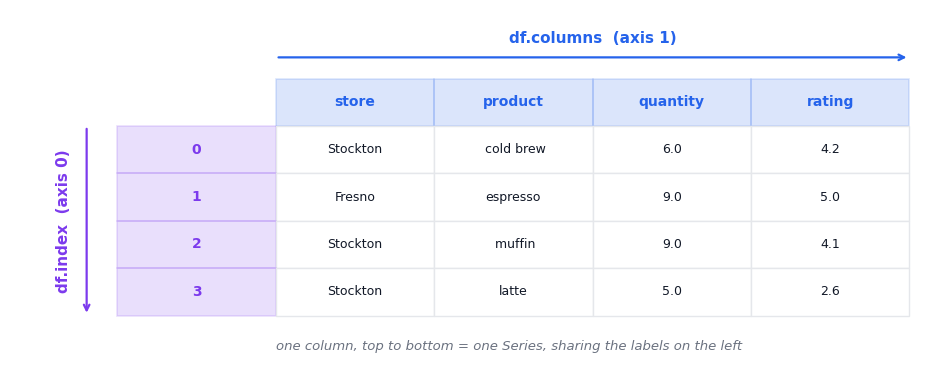

In [ ]:
# One picture of the two axes: index down the side, columns across the top.
demo = sales.loc[[0, 1, 2, 3], ["store", "product", "quantity", "rating"]]

nrow, ncol = demo.shape
cw, ch = 1.55, 0.62                      # cell width / height, in data units

fig, ax = plt.subplots(figsize=(9.6, 3.9))
ax.set_axis_off()
ax.grid(False)

# --- column headers (the columns Index) ---------------------------------
for j, col in enumerate(demo.columns):
    ax.add_patch(plt.Rectangle((cw + j * cw, nrow * ch), cw, ch,
                               facecolor=C_DATA, alpha=0.16, edgecolor=C_DATA, lw=1.2))
    ax.text(cw + j * cw + cw / 2, nrow * ch + ch / 2, col,
            ha="center", va="center", color=C_DATA, fontweight="bold", fontsize=10)

# --- index labels (the row Index) + the values --------------------------
for i in range(nrow):
    y = (nrow - 1 - i) * ch
    ax.add_patch(plt.Rectangle((0, y), cw, ch,
                               facecolor=C_IDX, alpha=0.16, edgecolor=C_IDX, lw=1.2))
    ax.text(cw / 2, y + ch / 2, str(demo.index[i]),
            ha="center", va="center", color=C_IDX, fontweight="bold", fontsize=10)
    for j in range(ncol):
        ax.add_patch(plt.Rectangle((cw + j * cw, y), cw, ch,
                                   facecolor="white", edgecolor=C_SOFT, lw=1.0))
        ax.text(cw + j * cw + cw / 2, y + ch / 2, str(demo.iat[i, j]),
                ha="center", va="center", fontsize=9, color="#111827")

# --- the two axis labels ------------------------------------------------
ax.annotate("", xy=(cw + ncol * cw, nrow * ch + ch * 1.45),
            xytext=(cw, nrow * ch + ch * 1.45),
            arrowprops=dict(arrowstyle="->", color=C_DATA, lw=1.6))
ax.text(cw + ncol * cw / 2, nrow * ch + ch * 1.7, "df.columns  (axis 1)",
        ha="center", va="bottom", color=C_DATA, fontweight="bold", fontsize=11)

ax.annotate("", xy=(-0.30, 0), xytext=(-0.30, nrow * ch),
            arrowprops=dict(arrowstyle="->", color=C_IDX, lw=1.6))
ax.text(-0.45, nrow * ch / 2, "df.index  (axis 0)", rotation=90,
        ha="right", va="center", color=C_IDX, fontweight="bold", fontsize=11)

ax.text(cw, -ch * 0.65,
        "one column, top to bottom = one Series, sharing the labels on the left",
        ha="left", va="center", color=C_GREY, fontsize=9.5, style="italic")

ax.set_xlim(-1.05, cw + ncol * cw + 0.30)
ax.set_ylim(-ch * 1.15, nrow * ch + ch * 2.45)
plt.tight_layout()
plt.show()


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

The first four rows of `sales`, drawn with the machinery made visible. Purple down the left is `df.index` — here the default `0, 1, 2, 3`, sitting *outside* the data, which is why it gets its own colour. Blue across the top is `df.columns`, and it is outside the data too. Only the white block in the middle is values.

Read one white column top to bottom and you have a Series: those values, plus the purple labels beside them. Set four such Series side by side against one shared purple strip and you have the DataFrame. Every selection in Part 3 is a way of naming which purple labels and which blue labels you want.

**The common misread:** counting the purple strip as a column and the blue strip as a row. Neither is in `.shape` and neither is in `.values` — which is exactly why `sales.shape` reported 9 columns rather than 10. The labels describe the data; they are not part of it.

</div>

## 1.5 Choosing an index, and giving it back

`RangeIndex` is a placeholder. When a column already identifies the row — an
order id, a customer id, a timestamp — promoting it to the index buys you three
things:

1. **Lookup by the thing you actually know.** `by_id.loc[1042]` instead of
   hunting for which row number holds order 1042.
2. **Alignment on something meaningful.** Two frames that both know about order
   ids will line up on their own, instead of needing a merge spelled out by hand.
3. **A hash lookup instead of a scan**, once the index is unique.

`set_index(col)` moves a column into the index; `reset_index()` moves it back out
into a column and restores the default `RangeIndex`. Neither modifies the
original frame — both return a new one, which is why we assign the result.


In [ ]:
by_id = sales.set_index("order_id")

print("sales.shape ->", sales.shape, "  (order_id is one of the columns)")
print("by_id.shape ->", by_id.shape, "  (order_id became the index, so one column fewer)")
print("by_id.index.name ->", by_id.index.name)
print()
print("Look an order up by the id itself:")
print(by_id.loc[1000])

# ...and straight back out again.
back = by_id.reset_index()
print()
print("after reset_index, columns ->", list(back.columns))
print("after reset_index, index   ->", back.index)

# But: is this index actually unique?
print()
print("by_id.index.is_unique ->", by_id.index.is_unique)
dup_ids = by_id.index[by_id.index.duplicated()]
print("repeated order ids     ->", len(dup_ids))
print("first repeated id      ->", dup_ids[0])
print()
print("by_id.loc[", dup_ids[0], "] returns:")
print(by_id.loc[dup_ids[0], ["date", "store", "product", "quantity"]])
print("type ->", type(by_id.loc[dup_ids[0]]))


sales.shape -> (914, 9)   (order_id is one of the columns)
by_id.shape -> (914, 8)   (order_id became the index, so one column fewer)
by_id.index.name -> order_id

Look an order up by the id itself:
date          2024-06-19
store            Salinas
region             Coast
product            bagel
category            food
quantity             5.0
unit_price         $2.75
rating               4.9
Name: 1000, dtype: object

after reset_index, columns -> ['order_id', 'date', 'store', 'region', 'product', 'category', 'quantity', 'unit_price', 'rating']
after reset_index, index   -> RangeIndex(start=0, stop=914, step=1)

by_id.index.is_unique -> False
repeated order ids     -> 14
first repeated id      -> 1399

by_id.loc[ 1399 ] returns:
                date        store product  quantity
order_id                                           
1399      2024-02-02  Bakersfield   latte      10.0
1399      2024-02-02  Bakersfield   latte      10.0
type -> <class 'pandas.core.frame.DataFrame'>


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

The top half is the trade. The frame keeps every row but loses a column, because `order_id` stopped being data and became the row labels — nothing shrank, something moved. `by_id.loc[1000]` then returns that whole order as a **Series**, with the column names acting as *its* index, which is the duality from §1.2 seen from the other side. `reset_index()` puts the column back at position 0 and hands you a fresh `RangeIndex`.

The bottom half is the catch. `is_unique` comes back `False`: Part 0 duplicated some rows, so a handful of order ids appear twice. Asking for one of those returns a **DataFrame with two rows**, not a Series — the printed pair is identical in every column, which is what a double-scanned till batch looks like.

**The common misread:** assuming `set_index` enforces uniqueness the way a database primary key would. It does not — it will happily accept repeated labels, and the consequence surfaces much later as a merge that returns more rows than either input. Check `.index.is_unique` immediately after you set an index; it costs one line.

</div>

<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ The trap

**`.loc[label]` changes its return type depending on the data.** With a unique label you get a Series (one row, column names as its index). With a repeated label you get a DataFrame. So `by_id.loc[some_id]['quantity'] * 2` returns a number for most ids and a two-element Series for the duplicated ones — and if you feed that into something expecting a scalar, the error surfaces somewhere else entirely, long after the real cause.

**What to do:** either de-duplicate before setting the index (Part 4 does this properly with `drop_duplicates`), or ask for a frame every time by passing a list: `by_id.loc[[some_id]]` always returns a DataFrame, whether it matches one row or five. Those extra brackets are the cheapest defensive habit in pandas.

</div>

## 1.6 Columns: adding them, ordering them, and one trap in naming them

Assigning to a new key adds a column at the end. `insert` puts one at a chosen
position. Both mutate the frame in place — which is exactly why we do it on a
`.copy()` here and leave the raw `sales` untouched.


In [ ]:
# Five rows, picked to include a couple of missing ratings so the new
# column below has something to say. .copy(): never mutate the raw frame.
first5 = sales.loc[[0, 1, 2, 16, 29]].copy()
print("before ->", list(first5.columns))

# assignment appends at the end...
first5["rating_missing"] = first5["rating"].isna()

# ...insert() puts it exactly where you want it.
first5.insert(0, "row_tag", ["a", "b", "c", "d", "e"])

print("after  ->", list(first5.columns))
print()
print(first5[["row_tag", "store", "quantity", "rating", "rating_missing"]])


before -> ['order_id', 'date', 'store', 'region', 'product', 'category', 'quantity', 'unit_price', 'rating']
after  -> ['row_tag', 'order_id', 'date', 'store', 'region', 'product', 'category', 'quantity', 'unit_price', 'rating', 'rating_missing']

   row_tag        store  quantity  rating  rating_missing
0        a     Stockton       6.0     4.2           False
1        b       Fresno       9.0     5.0           False
2        c     Stockton       9.0     4.1           False
16       d      Salinas       9.0     NaN            True
29       e  Bakersfield       5.0     NaN            True


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Two ways of adding a column; the only difference is where it lands. `first5['rating_missing'] = ...` appends to the end of the column list, while `first5.insert(0, 'row_tag', ...)` puts `row_tag` at the front — you can see both in the before/after listings. In the table, the new boolean column agrees with the `rating` beside it: `True` exactly where the rating is `NaN`.

`first5['rating'].isna()` returned a Series carrying `first5`'s index, which is why each value landed on the right row. That is §1.3 doing its job quietly, and it is the reason you almost never need to worry about row order when you assign a column.

**The common misread:** thinking column order matters to pandas. It does not — selection is by name, and nothing runs faster because a column sits on the left. Order is for the human reading the output, so spend `insert` on readability and nothing else.

</div>

In [ ]:
# Attribute access LOOKS nicer... until a column name collides with pandas itself.
trap = pd.DataFrame({"count": [3, 1, 4], "unit price": [3.25, 4.75, 4.25]})
print(trap)
print()

print("trap['count'] (the column) ->", trap["count"].tolist())

print("\ntrap.count  (NOT the column):")
print("  ", trap.count)                  # a bound method, not your data
try:
    print("  trap.count.sum() ->", trap.count.sum())
except AttributeError as e:
    print("   AttributeError:", e)

print("\ntrap.unit_price:")
try:
    trap.unit_price                      # the real name has a space in it
except AttributeError as e:
    print("   AttributeError:", e)

# And a column named 'shape' loses to the attribute, every time.
trap["shape"] = [10, 20, 30]
print("\ntrap.shape    ->", trap.shape, "  <- the frame's dimensions, not the column")
print("trap['shape'] ->", trap["shape"].tolist())

print("\nOn the real frame, attribute access happens to work:")
print("  sales.rating.mean()    ->", round(sales.rating.mean(), 4))
print("  sales['rating'].mean() ->", round(sales["rating"].mean(), 4))


   count  unit price
0      3        3.25
1      1        4.75
2      4        4.25

trap['count'] (the column) -> [3, 1, 4]

trap.count  (NOT the column):
   <bound method DataFrame.count of    count  unit price
0      3        3.25
1      1        4.75
2      4        4.25>
   AttributeError: 'function' object has no attribute 'sum'

trap.unit_price:
   AttributeError: 'DataFrame' object has no attribute 'unit_price'

trap.shape    -> (3, 3)   <- the frame's dimensions, not the column
trap['shape'] -> [10, 20, 30]

On the real frame, attribute access happens to work:
  sales.rating.mean()    -> 4.043
  sales['rating'].mean() -> 4.043


<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ The trap

**`df.column_name` is not a way to select a column. It is attribute lookup that sometimes happens to find one.**

All three failure modes are printed above. `trap.count` returned a bound *method* — pandas' own `.count()` — so `trap.count.sum()` raised an `AttributeError` about a method rather than adding your numbers. `trap.unit_price` raised `AttributeError` because the real column is `'unit price'` with a space, and no attribute name can contain a space. And after adding a column literally called `shape`, `trap.shape` still returned the frame's dimensions, because the built-in property wins.

The last two lines are the seductive part: on `sales`, `sales.rating.mean()` gives exactly the same number as `sales['rating'].mean()`. It works right up until someone renames a column, or a CSV arrives with a trailing space in a header, or a column is called `count`, `max`, `min`, `sum`, `size`, `index`, `shape` or `T` — all real column names, all existing pandas attributes.

**What to do:** use `df['col']` in anything you will run twice. Attribute access is fine for a throwaway line in a console; it does not belong in a script, and it can never *create* a column — `df.newcol = ...` sets an attribute on the object and silently adds no column at all.

</div>

---

## ✅ Part 1 in one paragraph

A **Series** is values plus labels plus a name. A **DataFrame** is several Series
sharing one set of labels, with a second `Index` naming the columns. Operations
line up on **labels**, not positions, which is why two Series of different lengths
can be added and why an unexpected `NaN` almost always means *these indexes did
not agree* rather than *this data is missing*. `set_index` lets you choose labels
that mean something, and `.index.is_unique` tells you whether you can trust them.
And `df['col']` is the only column access worth typing.

Next: we have been reading `sales` for a whole part without ever really
**looking** at it. Part 2 is about doing that properly — `head`, `sample`,
`describe`, `value_counts`, `nunique`, and the handful of lines that find a
frame's problems before those problems find you.

---


---

# 2️⃣ Loading data, and looking at it properly

## `head()` is not inspection. It is a thumbnail.

Every pandas tutorial opens the same way: read the file, call `head()`, admire the
table, start writing `groupby`. That habit is where most data bugs are born.

`head()` shows you **five rows out of hundreds or millions**, in file order, with
no dtype, no null count, and no idea whether row 600 is a duplicate of row 300.
It is a thumbnail of a photograph — useful for confirming the file opened, useless
for deciding whether the data is fit to compute on.

This part does two things:

1. **Reads a file for real** — `read_csv` and the handful of arguments that decide
   whether your dtypes survive the trip, plus why parquet exists.
2. **Replaces `head()` with a ritual** — a fixed sequence of about ten one-liners,
   each of which tells you something the previous one could not. Run it on every
   dataset you ever open, in this order, before you write a single line of analysis.

---
## 🗺️ The Ten Parts

Each part builds on the one before it, on a single dataset that is introduced in Part 0 and never leaves. By the end you will have cleaned it, reshaped it, grouped it, resampled it and plotted it.

| Part | What it covers | |
|---|---|---|
| **0** | Why pandas, and the one dataset we use |
| **1** | Series and DataFrame: the two objects |
| **2** | Loading data and looking at it |  &larr; **you are here**
| **3** | Selection: loc, iloc, and boolean masks |
| **4** | Cleaning: missing values, dtypes, duplicates |
| **5** | Transforming: vectorised ops, strings, dates |
| **6** | GroupBy: split, apply, combine |
| **7** | Reshaping: pivot, melt, merge, concat |
| **8** | Time series: resampling and rolling windows |
| **9** | Plotting, performance, and a capstone |


## 2.1 The thumbnail

Here is `sales` as almost everybody would first look at it.


In [ ]:
sales.head()


,order_id,date,store,region,product,category,quantity,unit_price,rating
0,1063,2024-02-08,Stockton,North,cold brew,drink,6.0,$4.25,4.2
1,1677,2024-05-17,Fresno,Central,espresso,drink,9.0,$3.25,5.0
2,1140,2024-03-19,Stockton,North,muffin,food,9.0,$3.5,4.1
3,1053,2024-05-27,Stockton,North,latte,drink,5.0,$4.75,2.6
4,1825,2024-06-01,Stockton,North,bagel,food,9.0,$2.75,4.3


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Five tidy rows. An order id, a date, a store, a region, a product, a category, a quantity, a price, a rating. Nothing looks broken: no blank cells, no obvious nonsense, columns lined up. If you stopped here you would conclude the file is clean and start aggregating.

**The common misread:** treating “I can see no problem” as “there is no problem”. `head()` samples 5 of 914 rows — about half a percent of the data, and always the *same* half percent. Every defect in this frame is invisible in the picture above, and the next cell finds four of them in four lines.

</div>

## 2.2 Four lines that disagree with the thumbnail

Same frame, four questions the thumbnail cannot answer: *what type is each
column, what is missing, what is repeated, and what is impossible?*


In [ ]:
# The same frame the thumbnail came from -- asked four harder questions.
print("shape:", sales.shape)

print("\n--- 1. what is each column, really? ------------------")
sales.info()

print("\n--- 2. what is missing? ------------------------------")
print(sales.isna().sum().to_string())

print("\n--- 3. what is repeated? -----------------------------")
print("exact duplicate rows:", int(sales.duplicated().sum()))

print("\n--- 4. what is impossible? ---------------------------")
print("smallest quantity in the file:", sales["quantity"].min())
print("orders with quantity < 0     :", int((sales["quantity"] < 0).sum()))


shape: (914, 9)

--- 1. what is each column, really? ------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 914 entries, 0 to 913
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   order_id    914 non-null    int64  
 1   date        914 non-null    object 
 2   store       914 non-null    object 
 3   region      899 non-null    object 
 4   product     914 non-null    object 
 5   category    914 non-null    object 
 6   quantity    884 non-null    float64
 7   unit_price  914 non-null    object 
 8   rating      851 non-null    float64
dtypes: float64(2), int64(1), object(6)
memory usage: 64.4+ KB

--- 2. what is missing? ------------------------------
order_id       0
date           0
store          0
region        15
product        0
category       0
quantity      30
unit_price     0
rating        63

--- 3. what is repeated? -----------------------------
exact duplicate rows: 14

--- 4. what is impo

<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Four defects the thumbnail hid, in the order the four questions asked them.

**1. Dtypes.** `date` and `unit_price` are text, not a datetime and not a number. `quantity` is `float64` rather than an integer — which is itself a *clue*, because pandas only floats an integer column when it has to hold a `NaN`.

**2. Missing.** Three columns have holes: `rating` 63, `quantity` 30, `region` 15. That is why `quantity` is a float.

**3. Repeated.** 14 rows are exact duplicates of other rows. Sum any column and you over-count by those 14 orders.

**4. Impossible.** The minimum quantity is `-1.0`, across 6 rows. A negative number of muffins is not a value, it is a data-entry mode you have not been told about.

**The common misread:** reading `info()` as a formality and skipping to the numbers. `info()` is the *only* one of these four that told you `unit_price` is text — and text prices do not add up, they concatenate. `sales['unit_price'].sum()` would happily return a several-thousand-character string rather than raising.

</div>

---

## 2.3 Reading a file: the round trip that loses your work

`sales` was generated in memory, which is convenient and dishonest — real data
arrives in a file. So let us make a file.

The demonstration below is deliberately unfair to CSV, and that is the point.
We build a small frame with the four dtypes people care about — a **datetime**, a
**category**, a **nullable integer**, and a **zero-padded id string** — write it to
CSV, read it straight back, and compare dtypes column by column.

A CSV file has no type system. It is text with commas. Everything you knew about
your columns is thrown away at `to_csv` and *guessed* at `read_csv`.


In [ ]:
import os, io, tempfile

# A small typed frame, carved out of sales. We are NOT cleaning sales here --
# this is a separate demo frame that exists to be written to disk and read back.
n = 200
typed = pd.DataFrame({
    "order_id": sales["order_id"].head(n).astype(str).str.zfill(8),  # ids keep leading zeros
    "date":     pd.to_datetime(sales["date"].head(n)),               # a real datetime
    "store":    sales["store"].head(n).astype("category"),           # a category
    "quantity": sales["quantity"].head(n).astype("Int64"),           # nullable integer
})

TMPDIR = os.path.join(tempfile.gettempdir(), "pandas_z2h_part2")
os.makedirs(TMPDIR, exist_ok=True)
CSV = os.path.join(TMPDIR, "typed.csv")

typed.to_csv(CSV, index=False)
naive = pd.read_csv(CSV)          # no arguments -- let pandas guess

print("the first two lines of the file on disk:")
with open(CSV) as f:
    print("    " + next(f).strip())
    print("    " + next(f).strip())

before, after = typed.dtypes.astype(str), naive.dtypes.astype(str)
print()
print(pd.DataFrame({"written as": before,
                    "read back as": after,
                    "survived": before.values == after.values}).to_string())

print("\norder_id first value -- before:", repr(typed["order_id"].iloc[0]),
      "  after:", repr(naive["order_id"].iloc[0]))


the first two lines of the file on disk:
    order_id,date,store,quantity
    00001063,2024-02-08,Stockton,6

              written as read back as  survived
order_id          object        int64     False
date      datetime64[ns]       object     False
store           category       object     False
quantity           Int64      float64     False

order_id first value -- before: '00001063'   after: np.int64(1063)


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

A dtype-by-dtype scorecard of one CSV round trip. **Nothing survived except the column names.** The datetime came back as text. The category came back as text and lost its category list. The nullable `Int64` came back as `float64`, because a blank in the file is indistinguishable from a missing value and `NaN` forces a float. And the zero-padded `'00001063'` came back as the integer `1063` — pandas saw digits and helpfully removed the leading zeros, which for an account number, a ZIP code or a product SKU is silent data destruction.

**The common misread:** blaming pandas. `read_csv` is guessing because the file gave it nothing to go on — look at the two printed lines, they are just characters and commas, with no type information anywhere. The fix is not a better guesser, it is telling `read_csv` what you already know.

</div>

<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ The trap

`read_csv` infers a dtype **per column, from the values it happens to see**. Two consequences bite constantly:

1. **A column of digits becomes a number.** ZIP code `02134` becomes `2134`. Phone numbers, SKUs and account ids all lose their leading zeros, and no warning is raised — from the file's point of view nothing went wrong.
2. **The same pipeline can infer different dtypes on different days.** If today's export happens to have no blanks in `quantity` it reads as `int64`; tomorrow's has one blank and it reads as `float64` — and code that did `df['quantity'].astype(int)` breaks in production on a Tuesday.

**Fix:** pass `dtype=` for every column you care about. That is not defensive programming, it is the only way to make the read reproducible.

</div>

### The `read_csv` arguments that actually matter

Out of roughly fifty parameters, these seven carry almost all the weight:

| Argument | What it does | When you need it |
|---|---|---|
| `dtype=` | forces a column's type instead of guessing | ids, codes, anything zero-padded |
| `parse_dates=` | turns text columns into `datetime64` at read time | every date column, always |
| `na_values=` | extra strings to treat as missing | `"N/A"`, `"-"`, `"unknown"`, `"NULL"` |
| `usecols=` | read only these columns | wide files where you need four columns |
| `nrows=` | read only the first N rows | probing a 4 GB file before committing |
| `index_col=` | which column becomes the index | when a natural key exists |
| `thousands=` | strips the grouping separator from numbers | `"1,234"` as written by Excel |

Below: the same file, read properly — then the same trick on a small ugly file
that has commas inside its numbers and three different spellings of "missing".


In [ ]:
# --- the same CSV, read with the dtypes declared instead of guessed ---------
restored = pd.read_csv(
    CSV,
    dtype={"order_id": "str", "store": "category", "quantity": "Int64"},
    parse_dates=["date"],
)
print("restored dtypes:")
print(restored.dtypes.to_string())
print("order_id first value:", repr(restored["order_id"].iloc[0]))
print("store is a category again:", list(restored["store"].cat.categories)[:3], "...")

# --- a deliberately ugly file: grouped numbers and three spellings of NA ----
UGLY = (
    "store,units_sold,revenue\n"
    'Fresno,"1,204","12,450.50"\n'
    'Salinas,N/A,"9,001.00"\n'
    "Modesto,876,unknown\n"
    'Stockton,-,"4,110.25"\n'
)
print("\nthe raw file:")
print(UGLY)

lazy    = pd.read_csv(io.StringIO(UGLY))
careful = pd.read_csv(io.StringIO(UGLY), thousands=",",
                      na_values=["N/A", "unknown", "-"])
print("read with no arguments      ->", dict(lazy.dtypes.astype(str)))
print("read with thousands+na_values ->", dict(careful.dtypes.astype(str)))
print()
print(careful.to_string())
print("\nrevenue total, the careful way:", careful["revenue"].sum())

# --- usecols / nrows / index_col: probing a file you have not seen ----------
peek = pd.read_csv(CSV, usecols=["order_id", "quantity"], nrows=4,
                   index_col="order_id")
print("\nusecols + nrows + index_col -- 2 columns, 4 rows, keyed by order_id:")
print(peek.to_string())


restored dtypes:
order_id            object
date        datetime64[ns]
store             category
quantity             Int64
order_id first value: '00001063'
store is a category again: ['BAKERSFIELD', 'Bakersfield', 'FRESNO'] ...

the raw file:
store,units_sold,revenue
Fresno,"1,204","12,450.50"
Salinas,N/A,"9,001.00"
Modesto,876,unknown
Stockton,-,"4,110.25"

read with no arguments      -> {'store': 'object', 'units_sold': 'object', 'revenue': 'object'}
read with thousands+na_values -> {'store': 'object', 'units_sold': 'float64', 'revenue': 'float64'}

      store  units_sold   revenue
0    Fresno      1204.0  12450.50
1   Salinas         NaN   9001.00
2   Modesto       876.0       NaN
3  Stockton         NaN   4110.25

revenue total, the careful way: 25561.75

usecols + nrows + index_col -- 2 columns, 4 rows, keyed by order_id:
          quantity
order_id          
1063             6
1677             9
1140             9
1053             5


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Two reads of the same bytes, producing two different datasets.

With no arguments, `units_sold` and `revenue` come back as **text**, because `"1,204"` is not a number to a parser that has not been told what a comma means — so the revenue column cannot be summed at all. With `thousands=","` and `na_values=[...]` they come back as `float64`, the three different spellings of missing (`N/A`, `unknown`, `-`) all collapse to one `NaN`, and the total is a number.

The last block is the probe pattern: `usecols` plus `nrows` reads two columns and four rows out of a file, which is how you look inside something far too large to open.

**The common misread:** assuming a column will be fine because it *looks* numeric in `head()`. Text and numbers render identically in a notebook table. The difference only surfaces when you sum the column and get a concatenated string, or sort it and get `"1,204"` before `"876"` because text sorts character by character.

</div>

### Other readers, and the one that makes this whole problem go away

`read_csv` has siblings, and they all return a DataFrame:

| Reader | Reads | Dtypes survive? | Notes |
|---|---|---|---|
| `pd.read_csv` | text with a delimiter | ❌ everything is guessed | universal, lossy |
| `pd.read_excel` | `.xlsx` / `.xls` sheets | partly | needs `openpyxl`; `sheet_name=` picks the sheet |
| `pd.read_json` | JSON records or tables | partly | `orient=` matters more than people expect |
| `pd.read_parquet` | columnar binary | ✅ **exactly** | needs `pyarrow`; also fast and small |
| `pd.read_sql` | a query against a database | mostly | takes a connection and a SQL string |

**Parquet stores the schema inside the file.** A datetime comes back a datetime,
a category comes back a category with its category list, a nullable integer comes
back `Int64`. If you control the format — an intermediate file between two steps
of your own pipeline, a cached extract, anything that is not being emailed to a
human — parquet is the right answer and CSV is a tax you keep paying.


In [ ]:
# The same frame through parquet instead of CSV.
PARQ = os.path.join(TMPDIR, "typed.parquet")
if not os.path.exists(CSV):          # so this cell can be re-run on its own
    typed.to_csv(CSV, index=False)
typed.to_parquet(PARQ, index=False)  # needs pyarrow, preinstalled on Colab
pq = pd.read_parquet(PARQ)

print(pd.DataFrame({"original":    typed.dtypes.astype(str),
                    "via parquet": pq.dtypes.astype(str),
                    "via csv":     naive.dtypes.astype(str)}).to_string())
print("\norder_id first value via parquet:", repr(pq["order_id"].iloc[0]))
print("store categories survived       :", list(pq["store"].cat.categories)[:3], "...")
print()
print(f"file sizes: csv {os.path.getsize(CSV)} bytes, "
      f"parquet {os.path.getsize(PARQ)} bytes")

# tidy up -- the notebook leaves nothing behind on disk
import shutil
shutil.rmtree(TMPDIR, ignore_errors=True)
print("temp directory removed:", not os.path.exists(TMPDIR))


                original     via parquet  via csv
order_id          object          object    int64
date      datetime64[ns]  datetime64[ns]   object
store           category        category   object
quantity           Int64           Int64  float64

order_id first value via parquet: '00001063'
store categories survived       : ['BAKERSFIELD', 'Bakersfield', 'FRESNO'] ...

file sizes: csv 6273 bytes, parquet 5535 bytes
temp directory removed: True


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Three columns of dtypes: what we had, what parquet gave back, what CSV gave back. The parquet column is identical to the original — datetime, category with its category list intact, `Int64`, and `order_id` still the zero-padded string `'00001063'`. The CSV column is the wreckage from two cells ago. The byte counts are printed underneath, and the binary file is the smaller of the two despite carrying strictly more information.

**The common misread:** “parquet is a big-data thing, my file is small.” The reason to reach for it here has nothing to do with size — it is that the round trip is *lossless*, so the read step of your pipeline stops being a place where bugs get introduced. The smaller file is a bonus, and on a 200-row frame it is a modest one; the gap widens enormously on real data, because parquet compresses column by column.

</div>

---

## 2.4 The inspection ritual

Now the replacement for `head()`. This is a fixed sequence — run it in this
order, on every dataset, before any analysis. Each step answers a question the
step before it could not:

| # | Call | The question it answers |
|---|---|---|
| 1 | `.shape` | how much data is there? |
| 2 | `.head()` / `.tail()` / `.sample()` | what does a row look like — at the start, the end, and at random? |
| 3 | `.info()` | what type is each column, and how many non-nulls? |
| 4 | `.dtypes` | the same, as data you can filter on |
| 5 | `.describe()` | what is the range of the numeric columns? |
| 6 | `.describe(include="all")` | …and the text ones, which `describe()` skipped |
| 7 | `.nunique()` | which columns are keys, which are labels, which are constants? |
| 8 | `.value_counts(dropna=False)` | what values does a label column actually take? |
| 9 | `.isna().sum()` | where are the holes? |
| 10 | `.duplicated().sum()` | are any rows repeated? |
| 11 | `.memory_usage(deep=True)` | what does it cost, and which column is the pig? |

Steps 1, 2, 4, 7 and 11 first. Steps 3, 5, 6 and 8 each hide a trap, so they get
their own sections after.


In [ ]:
print("1. shape:", sales.shape, "-> %d rows, %d columns" % sales.shape)

print("\n2a. head -- the first rows, in file order")
print(sales.head(3).to_string())
print("\n2b. tail -- the last rows. Trailing junk, spurious totals rows and")
print("    truncated exports show up here and nowhere else.")
print(sales.tail(3).to_string())
print("\n2c. sample -- rows from anywhere. head() can never show you row 600.")
print(sales.sample(3, random_state=0).to_string())

print("\n4. dtypes, as a Series you can query:")
print(sales.dtypes.to_string())
print("   numeric columns:", list(sales.select_dtypes("number").columns))

print("\n7. nunique -- distinct values per column:")
print(sales.nunique().to_string())

print("\n11. memory_usage(deep=True), bytes per column:")
mem = sales.memory_usage(deep=True)
print(mem.to_string())
print("   total: %.1f KB for %d rows" % (mem.sum() / 1024, len(sales)))
print("   store stored as text    : %d bytes" % mem["store"])
cat_bytes = sales["store"].astype("category").memory_usage(deep=True)
print(f"   store stored as category: {cat_bytes} bytes")


1. shape: (914, 9) -> 914 rows, 9 columns

2a. head -- the first rows, in file order
   order_id        date     store   region       product category  quantity unit_price  rating
0      1063  2024-02-08  Stockton    North    cold brew     drink       6.0      $4.25     4.2
1      1677  2024-05-17    Fresno  Central      espresso    drink       9.0      $3.25     5.0
2      1140  2024-03-19  Stockton    North       muffin      food       9.0       $3.5     4.1

2b. tail -- the last rows. Trailing junk, spurious totals rows and
    truncated exports show up here and nowhere else.
     order_id        date     store   region    product category  quantity unit_price  rating
911      1537  2024-03-14  Stockton    North      bagel     food       3.0      $2.75     5.0
912      1196  2024-03-29   Modesto  Central     bagel      food       6.0      $2.75     4.2
913      1175  2024-05-24    Fresno  Central    cookie      food       4.0      $2.25     3.5

2c. sample -- rows from anywhere. hea

<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

The ritual, minus the four steps that need their own discussion.

**`nunique` is the most under-used line here.** Read it as a shape description of the table. `order_id` has 900 distinct values in 914 rows, so it is *nearly* a key — and the 14 values it is short by are exactly the 14 duplicate rows. `category` has 2 distinct values, so it is a flag. `store` has **10** distinct values across 5 real stores, which is the inconsistent-case problem showing up as a number. `product` has **12** for 6 real products — the stray whitespace, same story.

**Memory:** `store` costs roughly 14 KB as text and about 1 KB as a `category`, because a category stores each distinct name once plus a small integer code per row. On a low-cardinality label column that is better than a tenfold saving for a one-word change.

**The common misread:** using `sample()` as a substitute for the rest rather than an addition to it. Three random rows are *also* a third of a percent of the data — sampling protects you against defects clustered at the start of the file, and against nothing else.

</div>

In [ ]:
print("describe() covered these columns:", list(sales.describe().columns))
print("the frame has these columns     :", list(sales.columns))
print()
print(sales.describe().to_string())

# 6. ask for the text columns explicitly -- a different set of statistics
print("\ndescribe(include='object'):")
print(sales.describe(include="object").to_string())

# ...or everything at once
print("\ndescribe(include='all'):")
print(sales.describe(include="all").to_string())


describe() covered these columns: ['order_id', 'quantity', 'rating']
the frame has these columns     : ['order_id', 'date', 'store', 'region', 'product', 'category', 'quantity', 'unit_price', 'rating']

          order_id    quantity      rating
count   914.000000  884.000000  851.000000
mean   1449.762582    7.875566    4.043008
std     260.482078    3.107787    0.561496
min    1000.000000   -1.000000    2.100000
25%    1225.250000    6.000000    3.700000
50%    1450.500000    8.000000    4.000000
75%    1674.750000   10.000000    4.400000
max    1899.000000   22.000000    5.000000

describe(include='object'):
              date        store   region product category unit_price
count          914          914      899     914      914        914
unique         179           10        4      12        2          6
top     2024-04-21  Bakersfield  Central   latte    drink      $4.75
freq            12          181      344     171      467        180

describe(include='all'):
          

<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ The trap

**`describe()` silently summarises only the numeric columns.** Above it reported on 3 of the 9 columns and said nothing at all about the other 6 — no warning, no note, just a smaller table than you thought you asked for. Skim it and you will believe you have inspected the frame.

The default is `include=None`, meaning “numeric only”. Use `include="all"` for every column, or `include="str"` for just the text ones — and note that the text summary reports a *different set of statistics*: `count`, `unique`, `top`, `freq` instead of mean and quartiles. That `unique` row is where `store` confesses to 10 distinct values, and `count` is where `region` confesses to 899 non-null out of 914.

Two more sharp edges in the numeric table. `count` is the **non-null** count, not the row count, so a short count is a missing-data alarm (`quantity` 884 and `rating` 851 against 914 rows). And `order_id` is summarised as though it were a measurement, complete with a meaningless mean of about 1,450 — `describe()` cannot tell an identifier from a quantity.

On pandas 3 text columns have dtype `str`, so the old `include="object"` spelling still selects them but raises a deprecation warning. Prefer `"str"`.

</div>

In [ ]:
# 8. value_counts -- and the default that quietly under-reports
vc_default = sales["region"].value_counts()
vc_all     = sales["region"].value_counts(dropna=False)

print(pd.DataFrame({"value_counts()": vc_default,
                    "value_counts(dropna=False)": vc_all}).to_string())
print()
print("rows accounted for by the default   :", int(vc_default.sum()))
print("rows accounted for with dropna=False:", int(vc_all.sum()))
print("rows actually in the frame          :", len(sales))
print()
print("as proportions -- normalize=True divides by whichever total you chose:")
print("  default    :", round(float(sales["region"].value_counts(normalize=True).iloc[0]), 4))
print("  dropna=False:", round(float(sales["region"].value_counts(normalize=True, dropna=False).iloc[0]), 4))


         value_counts()  value_counts(dropna=False)
region                                             
Central           344.0                         344
Coast             192.0                         192
North             178.0                         178
South             185.0                         185
None                NaN                          15

rows accounted for by the default   : 899
rows accounted for with dropna=False: 914
rows actually in the frame          : 914

as proportions -- normalize=True divides by whichever total you chose:
  default    : 0.3826
  dropna=False: 0.3764


<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ The trap

**`value_counts()` drops `NaN` by default.** The two columns above differ: the default accounts for 899 rows, `dropna=False` accounts for all 914, and the 15 rows in the gap are a `NaN` category the default simply does not print.

This is the single most effective way to convince yourself a column is complete when it is not — and it compounds, because `normalize=True` then divides by 899 instead of 914, so every percentage you quote is silently inflated. The two printed proportions differ for exactly that reason. **Always pass `dropna=False`.** The habit costs nothing when there are no nulls and saves you when there are.

The same trap lives elsewhere: `groupby` drops rows whose key is `NaN` unless you pass `dropna=False`, and `nunique` excludes `NaN` unless you pass `dropna=False`. Part 6 comes back to the `groupby` version, which is the expensive one — there it silently deletes rows from your result.

</div>

In [ ]:
# 3. info() -- and the argument you need once the frame gets big
import io as _io

print("default info() on this frame -- per-column non-null counts are shown:")
buf = _io.StringIO(); sales.info(buf=buf); print(buf.getvalue())

# pandas stops counting nulls once a frame is 'large'. The threshold is an option:
print("display.max_info_rows default:", pd.get_option("display.max_info_rows"))

pd.set_option("display.max_info_rows", 500)   # pretend 914 rows counts as large
buf = _io.StringIO(); sales.info(buf=buf)
print("\nsame call, frame now counts as large -- a whole column has vanished:")
print(buf.getvalue())

buf = _io.StringIO(); sales.info(buf=buf, show_counts=True)
print("info(show_counts=True) brings it back:")
print(buf.getvalue())
pd.reset_option("display.max_info_rows")


default info() on this frame -- per-column non-null counts are shown:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 914 entries, 0 to 913
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   order_id    914 non-null    int64  
 1   date        914 non-null    object 
 2   store       914 non-null    object 
 3   region      899 non-null    object 
 4   product     914 non-null    object 
 5   category    914 non-null    object 
 6   quantity    884 non-null    float64
 7   unit_price  914 non-null    object 
 8   rating      851 non-null    float64
dtypes: float64(2), int64(1), object(6)
memory usage: 64.4+ KB

display.max_info_rows default: 1690785

same call, frame now counts as large -- a whole column has vanished:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 914 entries, 0 to 913
Data columns (total 9 columns):
 #   Column      Dtype  
---  ------      -----  
 0   order_id    int64  
 1   date        object

<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ The trap

**On a large frame, `info()` stops printing the `Non-Null Count` column.** Counting nulls means touching every value, so pandas skips it once the frame has more rows than `display.max_info_rows` — default 1,690,785, printed above. We lowered the option to 500 so the effect is visible on a frame small enough to print; the report loses the one column you were reading `info()` for, and gains no warning that it did.

**Fix:** `df.info(show_counts=True)` forces the count. A second, unrelated cut-off does the same thing to columns: past `display.max_info_columns` (default 100) `info()` collapses the per-column table entirely into a one-line `Columns: 120 entries` summary. `df.info(verbose=True, show_counts=True)` restores both.

Where this bites: you develop against a 10,000-row sample, read the null counts, ship, and on the full five-million-row table the identical line of notebook prints a report with the nulls quietly omitted — and you read it the same way you read the small one.

</div>

---

## 2.5 Seeing the holes

`.isna().sum()` gives you a count per column. It does not tell you **where** the
holes are, or whether two columns go missing *together* — which is the difference
between "the till drops the occasional reading" and "the till was unplugged for a
week in March".

`sales.isna()` is a DataFrame of booleans exactly the same shape as `sales`.
Draw it.


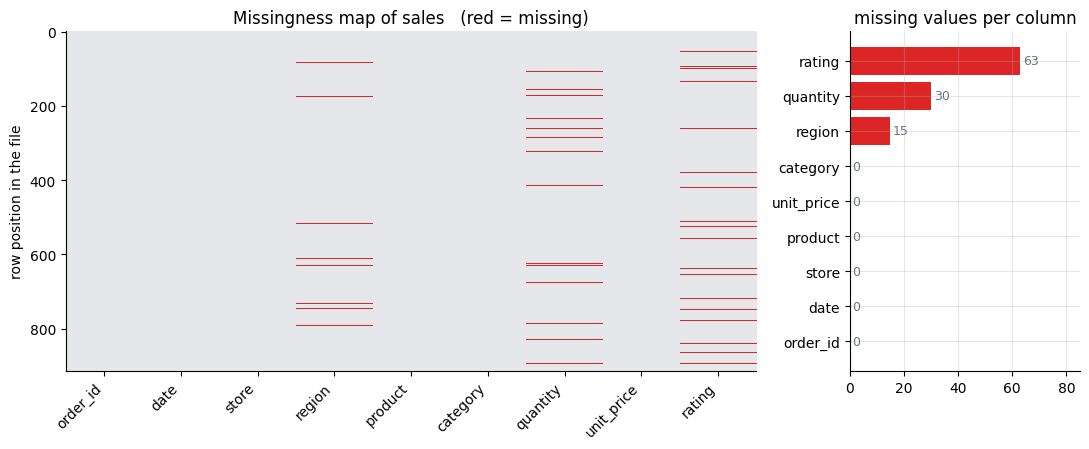

columns with any missing        : ['region', 'quantity', 'rating']
rows missing more than one field: 4
rows with nothing missing at all: 810


In [ ]:
from matplotlib.colors import ListedColormap

na = sales.isna()

fig, (ax, axb) = plt.subplots(1, 2, figsize=(11, 4.6),
                              gridspec_kw={"width_ratios": [3, 1]})

ax.imshow(na.values, aspect="auto", interpolation="nearest",
          cmap=ListedColormap([C_SOFT, C_NA]))
ax.set_xticks(range(len(na.columns)))
ax.set_xticklabels(na.columns, rotation=45, ha="right")
ax.set_ylabel("row position in the file")
ax.set_title("Missingness map of sales   (red = missing)")
ax.grid(False)

counts = na.sum().sort_values()
axb.barh(counts.index, counts.values,
         color=[C_NA if v else C_SOFT for v in counts.values])
for name, v in counts.items():
    axb.text(v + 1, name, str(int(v)), va="center", fontsize=9, color=C_GREY)
axb.set_title("missing values per column")
axb.set_xlim(0, max(counts.max() * 1.35, 1))

plt.tight_layout()
plt.show()

print("columns with any missing        :", list(counts[counts > 0].index))
print("rows missing more than one field:", int((na.sum(axis=1) > 1).sum()))
print("rows with nothing missing at all:", int((na.sum(axis=1) == 0).sum()))


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Left: one pixel per cell of the frame — 914 rows tall, 9 columns wide, red where the value is missing. Right: the same information collapsed to a count per column, `rating` 63, `quantity` 30, `region` 15, everything else zero.

The map adds the one thing the counts cannot: **shape**. The red pixels are spread evenly down all three columns rather than banded, and the three stripes do not line up with each other — only 4 rows in the whole frame are missing more than one field, which is about what independent holes would give you. That is missingness scattered at random, which is the benign case: the holes were not caused by one shared event, so it is legitimate to handle each column separately in Part 4 — which matters, because the three columns go missing for three different reasons.

**The common misread:** seeing a solid horizontal band across several columns in a map like this and treating it as three independent problems. A band at the same rows is *one* problem — a failed batch, an outage, a join that did not match — and the fix is to go find that event, not to impute three columns.

</div>

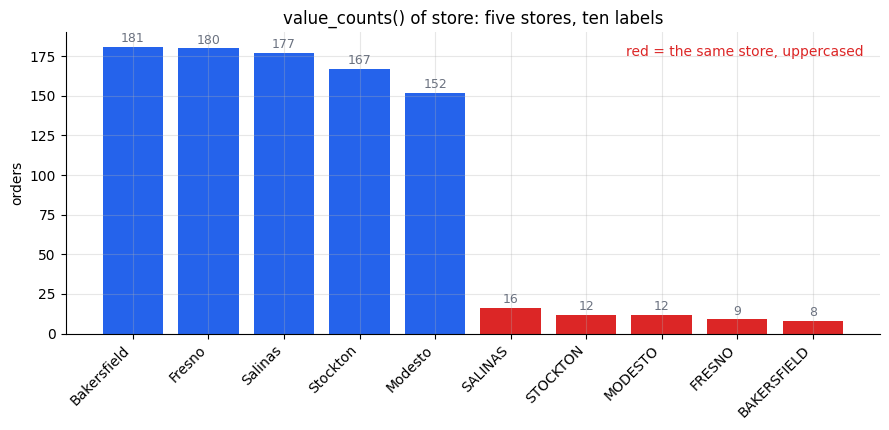

distinct labels              : 10
distinct after lower-casing  : 5
Salinas orders filed as 'SALINAS': 16 of 193  (8.3 percent)


In [ ]:
vc = sales["store"].value_counts(dropna=False)
is_shouty = [str(s).upper() == str(s) for s in vc.index]

fig, ax = plt.subplots(figsize=(9, 4.4))
ax.bar(range(len(vc)), vc.values,
       color=[C_NA if s else C_DATA for s in is_shouty])
ax.set_xticks(range(len(vc)))
ax.set_xticklabels(vc.index, rotation=45, ha="right")
ax.set_ylabel("orders")
ax.set_title("value_counts() of store: five stores, ten labels")
for i, v in enumerate(vc.values):
    ax.text(i, v + 3, str(int(v)), ha="center", fontsize=9, color=C_GREY)
ax.text(0.98, 0.92, "red = the same store, uppercased",
        transform=ax.transAxes, ha="right", fontsize=10, color=C_NA)

plt.tight_layout()
plt.show()

print("distinct labels              :", sales["store"].nunique())
print("distinct after lower-casing  :", sales["store"].str.lower().nunique())
salinas_lower = int(vc.get("Salinas", 0))
salinas_upper = int(vc.get("SALINAS", 0))
salinas_total = salinas_lower + salinas_upper
salinas_pct = 100 * salinas_upper / salinas_total
print(f"Salinas orders filed as 'SALINAS': {salinas_upper} of {salinas_total}"
      f"  ({salinas_pct:.1f} percent)")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Ten bars for five stores. The five blue bars are the correctly-cased names; the five red ones are the *same five stores* with the name uppercased, sitting down at the small end of the chart where they read like minor categories. Lower-casing the column collapses 10 labels back to 5, as the two printed counts confirm.

This is why `value_counts()` belongs in the inspection ritual rather than in the cleaning step. The defect is invisible in `head()`, invisible in `.shape`, invisible in `describe()` of the numeric columns — and obvious the moment you count the labels. `nunique` flags it as a number; the bar chart shows you *which* labels to merge.

**The common misread:** assuming a small bar is a small store. Group by `store` right now and Salinas is reported at 177 orders while the rest of its orders sit in a separate bucket spelled `SALINAS`. Nothing raises. The regional report is simply wrong, by the percentage printed under the chart, and it is wrong in a direction nobody will think to question.

</div>

---

## 2.6 What Part 2 bought you

You can now open a file without losing its dtypes, and you have a fixed
procedure for the first five minutes with any dataset.

Copy this into your own notebooks:

```python
df.shape                              # 1. how much
df.head(); df.tail(); df.sample(5)    # 2. what a row looks like
df.info(show_counts=True)             # 3. types + non-nulls (force the counts)
df.describe(include="all")            # 4. ranges AND text summaries
df.nunique()                          # 5. keys vs labels vs constants
for c in label_columns:
    df[c].value_counts(dropna=False)  # 6. what the labels really are
df.isna().sum()                       # 7. where the holes are
df.duplicated().sum()                 # 8. what is repeated
df.memory_usage(deep=True)            # 9. what it costs
```

Nine lines. On `sales` they found, in about a second: `date` and `unit_price`
stored as text, 63 + 30 + 15 missing values across three columns, 14 exact
duplicate rows, 6 orders with a negative quantity, five stores wearing ten
different labels and six products wearing twelve.

<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ✅ You should now be able to

- Read a CSV without letting pandas guess: `dtype=`, `parse_dates=`, `na_values=`, `thousands=`.
- Say why a CSV round trip destroys datetimes, categories, nullable integers and leading zeros — and reach for parquet when the format is yours to choose.
- Probe a file too large to open, with `usecols` and `nrows`.
- Run the inspection ritual in order, and say what each step adds that the one before it could not.
- Avoid the three defaults that under-report: `value_counts()` dropping `NaN`, `describe()` skipping the text columns, and `info()` hiding non-null counts once the frame is large.
- Read a missingness map, and tell scattered holes apart from a failed batch.

</div>

---

### ➡️ Next: Part 3 — selection

We have *found* the bad rows. Now we need to **point at** them: the 14
duplicates, the 6 negative quantities, the 15 rows with no region. Every fix in
Part 4 begins with selecting the rows to fix — and selection is the corner of
pandas with the most footguns per line of code. `df[...]` means three different
things depending on what you put inside the brackets, `loc` and `iloc` disagree
about whether the last element of a slice is included, and chained indexing
raises a warning that most people learn to ignore and absolutely should not.

---


---

# 3️⃣ Selection: `loc`, `iloc`, and boolean masks

<div style="background: linear-gradient(135deg, #11998e 0%, #38ef7d 100%); padding: 28px; border-radius: 18px; color: white; margin: 12px 0;">


### This is the part everyone gets wrong.

Not because selection is hard, but because `df[...]` is four different functions wearing one coat. Put a string in the brackets and you get a column. Put a list of strings in and you get a DataFrame of columns. Put a *slice* in and you suddenly get **rows**. Put a boolean Series in and you get rows again, but chosen a different way.

Nobody designed that. It accreted. `.loc` and `.iloc` exist because someone eventually admitted it was a mess and built two accessors that each mean exactly one thing — and the day you stop reaching for bare `df[...]` on anything but a column name is the day your pandas stops surprising you.

Then, at the end, the trap that has cost more debugging hours than every other pandas behaviour combined: **chained assignment**. Code that looks like it edits your DataFrame, runs without an error, and changes nothing.


</div>

## 🎯 What this part gives you

1. The four meanings of `df[...]`, each demonstrated with its `type()` printed.
2. `.loc` versus `.iloc` — **shown giving different answers to the same argument**, which is the only demonstration that makes the difference stick.
3. Boolean masks: `&`, `|`, `~`, `.isin()`, `.between()`, and why the parentheses are not optional.
4. `.query()` as the readable alternative, with `@variables` — and where it runs out.
5. `.at` / `.iat` for single cells.
6. Chained assignment, shown failing on the real frame, then explained, then fixed.

---
## 🗺️ The Ten Parts

Each part builds on the one before it, on a single dataset that is introduced in Part 0 and never leaves. By the end you will have cleaned it, reshaped it, grouped it, resampled it and plotted it.

| Part | What it covers | |
|---|---|---|
| **0** | Why pandas, and the one dataset we use |
| **1** | Series and DataFrame: the two objects |
| **2** | Loading data and looking at it |
| **3** | Selection: loc, iloc, and boolean masks |  &larr; **you are here**
| **4** | Cleaning: missing values, dtypes, duplicates |
| **5** | Transforming: vectorised ops, strings, dates |
| **6** | GroupBy: split, apply, combine |
| **7** | Reshaping: pivot, melt, merge, concat |
| **8** | Time series: resampling and rolling windows |
| **9** | Plotting, performance, and a capstone |


## 3.1 `df[...]` means four different things

The square brackets on a DataFrame dispatch on the **type of what you put inside them**. Same syntax, four different operations, two of which return rows and two of which return columns:

| What you put in | What you get back | Axis |
|---|---|---|
| `df['store']` | a **Series** — one column | columns |
| `df[['store', 'rating']]` | a **DataFrame** — several columns | columns |
| `df[0:3]` | a **DataFrame** — the first three **rows** | rows |
| `df[mask]` | a **DataFrame** — the rows where `mask` is True | rows |

Read that table twice. A string selects a *column*; a slice selects *rows*. There is no rule of thumb that makes that consistent, because it is not consistent. Let's watch it happen.


In [ ]:
# Four calls that look identical and do four different things.
examples = [
    ("sales['store']",            sales['store'],             "columns"),
    ("sales[['store','rating']]", sales[['store', 'rating']], "columns"),
    ("sales[0:3]",                sales[0:3],                 "rows"),   # a SLICE!
    ("sales[sales.rating > 4.9]", sales[sales.rating > 4.9],  "rows"),
]

print(f"{'expression':30s} {'returns':10s} {'shape':12s} selects")
print("-" * 62)
for expr, out, axis in examples:
    print(f"{expr:30s} {type(out).__name__:10s} {str(out.shape):12s} {axis}")

print()
print("sales[0:3] -- three ROWS, all nine columns:")
print(sales[0:3][['order_id', 'store', 'product', 'rating']])


expression                     returns    shape        selects
--------------------------------------------------------------
sales['store']                 Series     (914,)       columns
sales[['store','rating']]      DataFrame  (914, 2)     columns
sales[0:3]                     DataFrame  (3, 9)       rows
sales[sales.rating > 4.9]      DataFrame  (56, 9)      rows

sales[0:3] -- three ROWS, all nine columns:
   order_id     store       product  rating
0      1063  Stockton    cold brew      4.2
1      1677    Fresno      espresso     5.0
2      1140  Stockton       muffin      4.1


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Four expressions with identical syntax. `sales['store']` returns a **Series** of shape `(914,)`. `sales[['store','rating']]` returns a **DataFrame** of shape `(914, 2)` — one extra pair of brackets changes the return type. `sales[0:3]` returns shape `(3, 9)`: three rows and *all* nine columns, because a slice is read as a row selector. And the boolean mask returns `(56, 9)` — the 56 orders rated above 4.9.

**The common misread:** thinking `sales[0:3]` selects the first three *columns* by position, by analogy with `sales['store']` selecting a column by name. It does not. The bracket operator switches axis based on the type of the argument, and that switch is the reason this section exists.

</div>

<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ The trap

`sales['Fresno']` raises `KeyError: 'Fresno'`. That reads as a bug when you meant *rows where the store is Fresno* — but a bare string is always a column name, never a value, so pandas went looking for a column called `Fresno` and did not find one.

The same confusion runs the other way: `sales[0:3]` works and gives rows, so people try `sales[0]` expecting the first row. That raises `KeyError: 0` — a bare integer is a *column label* too, and there is no column named `0`.

**The fix is to stop using bare brackets for anything but a column.** Write `sales.loc[mask]` for rows, `sales.loc[:, cols]` for columns, and the ambiguity disappears entirely. Bare `df['col']` is fine and everyone uses it; bare `df[anything_else]` is a coin flip you do not need to make.

</div>

## 3.2 `.loc` is label-based, `.iloc` is position-based

Two accessors, each with exactly one meaning:

- **`.loc[label]`** — look up by the value in the **index**. If the index holds order ids, `.loc[1005]` means *the order whose id is 1005*, wherever it sits in the frame.
- **`.iloc[position]`** — look up by the **integer offset from the top**, exactly like a Python list. `.iloc[5]` means *the sixth row*, whatever its label is.

On a fresh DataFrame with a default `RangeIndex`, labels and positions are the same numbers, so the two accessors agree and the distinction looks academic. It stops looking academic the moment you sort, filter, or set an index — because sorting moves rows but **carries their labels with them**.

So let's sort `sales` by rating and ask both accessors the same question.


In [ ]:
# Sorting moves the rows but the index labels TRAVEL WITH THEM.
by_rating = sales.sort_values("rating", ascending=False)

print("the index is no longer 0,1,2,... -- it is shuffled:")
print(list(by_rating.index[:8]))
print()

cols = ["order_id", "store", "rating"]
print("by_rating.loc[5]   -- the row LABELLED 5 (it was row 5 of the raw frame):")
print(by_rating.loc[5][cols].to_string())
print()
print("by_rating.iloc[5]  -- the row at POSITION 5 (6th-highest rating):")
print(by_rating.iloc[5][cols].to_string())
print()
print("same argument, different rows:",
      by_rating.loc[5]["order_id"] != by_rating.iloc[5]["order_id"])

# --- and slices behave differently too --------------------------------
srt = sales.set_index("order_id").sort_index()   # index = order ids, sorted

lab = srt.loc[1005:1010]     # LABEL slice
pos = srt.iloc[5:10]         # POSITION slice
print()
print(f"srt.loc[1005:1010] -> {len(lab)} rows, labels {list(lab.index)}")
print(f"srt.iloc[5:10]     -> {len(pos)} rows, labels {list(pos.index)}")
print(".loc includes its endpoint; .iloc does not.")


the index is no longer 0,1,2,... -- it is shuffled:
[911, 1, 549, 49, 866, 64, 605, 515]

by_rating.loc[5]   -- the row LABELLED 5 (it was row 5 of the raw frame):
order_id        1870
store       Stockton
rating           4.3

by_rating.iloc[5]  -- the row at POSITION 5 (6th-highest rating):
order_id      1128
store       Fresno
rating         5.0

same argument, different rows: True

srt.loc[1005:1010] -> 6 rows, labels [1005, 1006, 1007, 1008, 1009, 1010]
srt.iloc[5:10]     -> 5 rows, labels [1005, 1006, 1007, 1008, 1009]
.loc includes its endpoint; .iloc does not.


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

The index of `by_rating` starts `[911, 1, 549, ...]` — sorting reordered the rows and each row kept its original label. So `.loc[5]` finds the row *labelled* 5 (order 1870, Stockton, rating 4.3) while `.iloc[5]` returns the row *at position* 5 (order 1128, Fresno, rating 5.0). Same argument, different orders, different stores, different ratings.

Below that, the slices: `srt.loc[1005:1010]` returns **6** rows and ends on label 1010; `srt.iloc[5:10]` returns **5** rows and stops at label 1009. `.loc` slices are closed on both ends, `.iloc` slices are half-open like every other Python slice.

**The common misread:** believing `.loc` and `.iloc` differ only in *style* and that you can use whichever reads better. They differ in *result*. On a frame you have sorted or filtered, swapping one for the other silently returns a different row — no error, no warning, just the wrong answer flowing into everything downstream.

</div>

<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ The trap

**`.loc` slices include the endpoint.** `df.loc[1005:1010]` returned 6 rows, not 5. That is deliberate — with labels there is no "one past the end" to point at, because labels need not be numbers at all (`df.loc['2024-01-01':'2024-01-31']` should obviously include January 31st). But if you carry Python slice instincts over, you will be off by one every time.

**A `.loc` slice on an unsorted index raises.** `by_rating.loc[7:10]` fails, because pandas cannot walk from label 7 to label 10 in an index that is not monotonic — it does not know which rows lie between them. Call `.sort_index()` first, which is exactly why `srt` above is built with `.set_index('order_id').sort_index()` rather than `.set_index()` alone.

**`.iloc` never fails this way** — positions are always ordered — but it raises `IndexError` past the end, so `srt.iloc[1005]` is an error on a 914-row frame while `srt.loc[1005]` is a perfectly good order.

</div>

## 3.3 Boolean masks — selection by a parallel array of True/False

A mask is not a query language. It is just a **Series of booleans the same length as the frame**, aligned to the same index. `sales.rating > 4.5` does not "find" anything; it computes one True/False per row and hands you the whole column of answers. Passing that column back to `sales[...]` keeps the True rows.

That is the whole mechanism, and it is why masks compose: a boolean Series is an ordinary value, so you can store it in a variable, combine it with another one, invert it, or count it before you ever use it to select.

Combining them is where people get hurt. Python's `and` / `or` do not work — and neither does writing `&` without parentheses. **Failure first.**


In [ ]:
# ---------- FAILURE 1: & without parentheses -------------------------
try:
    result = sales[sales.rating > 4.5 & sales.store == "Fresno"]
except Exception as e:
    print("FAILS:", type(e).__name__)
    print("      ", str(e)[:110])

# ---------- FAILURE 2: the `and` keyword -----------------------------
try:
    result = sales[(sales.rating > 4.5) and (sales.store == "Fresno")]
except Exception as e:
    print("FAILS:", type(e).__name__)
    print("      ", str(e)[:110])

# ---------- CORRECT: & with parentheses ------------------------------
mask = (sales.rating > 4.5) & (sales.store == "Fresno")
print()
print("type(mask):", type(mask).__name__, " dtype:", mask.dtype, " length:", len(mask))
print("mask.sum():", mask.sum(), "rows are True")
print()
print(sales[mask][["order_id", "store", "product", "rating"]].head())


FAILS: TypeError
       Cannot perform 'rand_' with a dtyped [object] array and scalar of type [bool]
FAILS: ValueError
       The truth value of a Series is ambiguous. Use a.empty, a.bool(), a.item(), a.any() or a.all().

type(mask): Series  dtype: bool  length: 914
mask.sum(): 27 rows are True

     order_id   store   product  rating
1        1677  Fresno  espresso     5.0
39       1668  Fresno     latte     4.7
64       1128  Fresno  espresso     5.0
109      1673  Fresno    cookie     4.9
123      1591  Fresno     bagel     5.0


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Two failures and then the working version. The first raises a `TypeError` mentioning `rand_` and dtype `str` — no hint that the problem is punctuation. The second raises `ValueError: The truth value of a Series is ambiguous`, which is the same message you get from `if some_series:` and is at least a recognisable landmark.

Then the mask itself: a `Series` of dtype `bool` and length 914 — the same length as the frame, one answer per row — of which 27 are True. `sales[mask]` returns exactly those 27 orders, all of them in Fresno and all rated above 4.5.

**The common misread:** treating `mask.sum()` as a coincidence of notation. It is not a count function bolted on for convenience — summing booleans works because True is 1 and False is 0, so `.sum()` counts and `.mean()` gives the *proportion* of rows that match. `mask.mean()` is the fastest way to ask what fraction of your data satisfies a condition.

</div>

<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ The trap

**The parentheses are mandatory, and the reason is operator precedence.** In Python, `&` binds *tighter* than `>`. So `sales.rating > 4.5 & sales.store == 'Fresno'` is parsed as `sales.rating > (4.5 & sales.store) == 'Fresno'` — pandas is asked to compute `4.5 & <a column of store names>` and raises a `TypeError` about `rand_` on dtype `str`. The message never mentions parentheses, which is why this one wastes so much time.

**And `and` / `or` / `not` can never work on Series.** Those keywords demand a single `True` or `False`, so Python calls `bool()` on the Series, which raises `ValueError: The truth value of a Series is ambiguous` — a 914-element Series is neither true nor false. You must use the elementwise operators `&`, `|`, `~`, each with its arguments parenthesised.

House rule: **parenthesise every comparison in a mask, every time**, even when there is only one. It costs two characters and removes the whole class of bug.

</div>

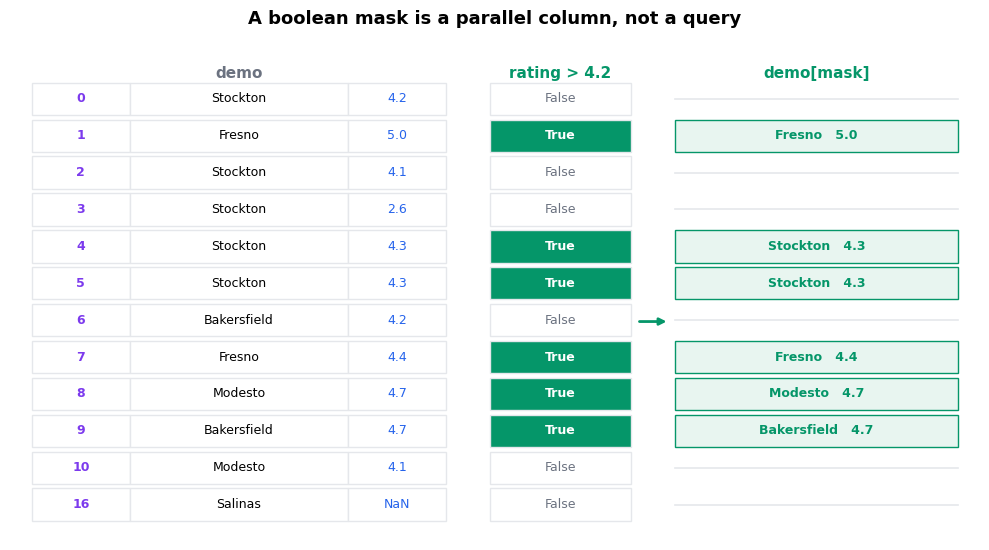

rows in demo: 12   mask True: 6   rows returned: 6


In [ ]:
# A picture of what a mask actually is: a column of booleans running
# alongside the frame, deciding row by row who survives.
demo = pd.concat([sales.head(11), sales[sales.rating.isna()].head(1)])
demo_mask = demo["rating"] > 4.2          # NaN compares False -- watch row 12

fig, ax = plt.subplots(figsize=(10, 5.6))
n = len(demo)
row_h, y0 = 0.42, 0.0

def cell(x, y, w, text, face, edge=C_SOFT, tcol="black", weight="normal"):
    ax.add_patch(plt.Rectangle((x, y), w, row_h, facecolor=face,
                               edgecolor=edge, linewidth=1.0))
    ax.text(x + w / 2, y + row_h / 2, text, ha="center", va="center",
            fontsize=9, color=tcol, fontweight=weight)

for i, (idx, row) in enumerate(demo.iterrows()):
    y = y0 + (n - 1 - i) * (row_h + 0.06)
    keep = bool(demo_mask.iloc[i])
    rating = "NaN" if pd.isna(row["rating"]) else f"{row['rating']:.1f}"

    # left block: the frame
    cell(0.0, y, 0.9, str(idx), "white", tcol=C_IDX, weight="bold")
    cell(0.9, y, 2.0, str(row["store"])[:11], "white")
    cell(2.9, y, 0.9, rating, "white", tcol=C_DATA)

    # middle block: the mask
    cell(4.2, y, 1.3, "True" if keep else "False",
         C_GROUP if keep else "white",
         tcol="white" if keep else C_GREY, weight="bold" if keep else "normal")

    # right block: what survives
    if keep:
        cell(5.9, y, 2.6, f"{str(row['store'])[:11]}   {rating}",
             "#E8F5F0", edge=C_GROUP, tcol=C_GROUP, weight="bold")
    else:
        ax.plot([5.9, 8.5], [y + row_h / 2] * 2, color=C_SOFT, lw=1.2, zorder=0)

top = y0 + n * (row_h + 0.06)
ax.text(1.9, top, "demo", ha="center", fontsize=11, fontweight="bold", color=C_GREY)
ax.text(4.85, top, "rating > 4.2", ha="center", fontsize=11,
        fontweight="bold", color=C_GROUP)
ax.text(7.2, top, "demo[mask]", ha="center", fontsize=11,
        fontweight="bold", color=C_GROUP)
ax.annotate("", xy=(5.85, top * 0.45), xytext=(5.55, top * 0.45),
            arrowprops=dict(arrowstyle="-|>", color=C_GROUP, lw=2))

ax.set_xlim(-0.2, 8.7); ax.set_ylim(-0.25, top + 0.45)
ax.axis("off"); ax.grid(False)
plt.title("A boolean mask is a parallel column, not a query",
          fontsize=13, fontweight="bold", pad=14)
plt.tight_layout(); plt.show()

print(f"rows in demo: {len(demo)}   mask True: {int(demo_mask.sum())}"
      f"   rows returned: {len(demo[demo_mask])}")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Twelve rows of the frame on the left with their index labels in purple, the mask `rating > 4.2` in the middle, and on the right the rows that survive. Every row gets exactly one True or False; the False rows are struck through rather than removed, because the mask does not shrink the frame — it *labels* it, and `demo[mask]` is a second step that keeps the labelled ones. The count printed underneath confirms that True count and returned row count are the same number.

The last row is deliberate: it has a **missing rating**, and `NaN > 4.2` is `False`, so it is dropped. Not flagged, not errored — dropped.

**The common misread:** picturing a mask as a filter that *runs over* the frame looking for matches. It is a fully-materialised boolean Series that already exists before any selection happens — which is why you can `.sum()` it to count matches, invert it with `~`, or store it and reuse it against a differently-ordered frame, where it will align by index rather than by position.

</div>

In [ ]:
# ---- ~ negation, .isin(), .between() --------------------------------
hi = sales["rating"] > 4.0

print(f"{'expression':42s} rows")
print("-" * 50)
print(f"{'(rating > 4.0)':42s} {hi.sum()}")
print(f"{'~(rating > 4.0)':42s} {(~hi).sum()}")
print(f"{'(rating <= 4.0)':42s} {(sales.rating <= 4.0).sum()}")
print(f"{'rating is NaN':42s} {sales.rating.isna().sum()}")
print()
print("~hi + hi          =", (~hi).sum() + hi.sum(), "  (every row is in one or the other)")
print("(<=4) + (>4)      =", (sales.rating <= 4.0).sum() + hi.sum(),
      "  (the NaN rows fall through BOTH)")
print()

# .isin() -- one call instead of a chain of ORs
picked = sales["store"].isin(["Fresno", "Salinas"])
print("store in {Fresno, Salinas}:", picked.sum(), "rows")

# .between() -- inclusive on both ends by default
mid = sales["rating"].between(3.5, 4.5)
print("rating between 3.5 and 4.5 (inclusive):", mid.sum(), "rows")
print("                       (exclusive):",
      sales["rating"].between(3.5, 4.5, inclusive="neither").sum(), "rows")


expression                                 rows
--------------------------------------------------
(rating > 4.0)                             423
~(rating > 4.0)                            491
(rating <= 4.0)                            428
rating is NaN                              63

~hi + hi          = 914   (every row is in one or the other)
(<=4) + (>4)      = 851   (the NaN rows fall through BOTH)

store in {Fresno, Salinas}: 357 rows
rating between 3.5 and 4.5 (inclusive): 539 rows
                       (exclusive): 470 rows


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

423 orders are rated above 4.0. Inverting that mask with `~` gives 491, and 423 + 491 = 914 — the whole frame, every row on exactly one side. But `rating <= 4.0` gives 428, and 423 + 428 = 851, which is 63 short. Those 63 are exactly the orders with a **missing** rating, counted on the line above.

Underneath: `.isin(['Fresno','Salinas'])` picks 357 rows in one call rather than `(store == 'Fresno') | (store == 'Salinas')`, and `.between(3.5, 4.5)` picks 539 rows with both endpoints included — dropping to 470 when you pass `inclusive='neither'`.

**The common misread:** reading `~hi` and `rating <= 4.0` as two spellings of the same thing. They differ by 63 rows here, and the difference is entirely about where the missing values land.

</div>

<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ The trap

**`~mask` and the opposite comparison are not the same mask when data is missing.** Any comparison against `NaN` returns `False`, so a missing rating is `False` in `rating > 4.0` *and* `False` in `rating <= 4.0`. Inverting the first mask with `~` flips those 63 Falses to True and sweeps the missing rows in; writing the opposite comparison leaves them out. Same for `!=` versus `~(... == ...)`.

Neither is wrong — but they answer different questions, and you have to decide which one you meant. "Not highly rated" and "rated 4.0 or below" are genuinely different populations once some customers declined to rate.

When it matters, be explicit: `~hi & sales.rating.notna()` for *rated, and rated low*. And note this is why the totals are worth printing — a mask that silently drops or absorbs your missing rows will not announce itself.

</div>

## 3.4 `.query()` — the same masks, in prose

`.query()` takes a **string** and evaluates it against the frame's columns, so column names become bare variables and you get `and` / `or` / `not` as English words. Long conditions become dramatically more readable, and there are no parentheses to forget.

To reach a Python variable from inside the string, prefix it with `@`.


In [ ]:
threshold = 4.5
wanted = ["Fresno", "Salinas"]

# the same selection, written twice
mask_way  = sales[(sales.rating > threshold) & (sales.store == "Fresno")]
query_way = sales.query("rating > @threshold and store == 'Fresno'")
print("mask:", len(mask_way), " query:", len(query_way),
      " identical:", mask_way.equals(query_way))

print()
print("a long condition, which is where .query() earns its keep:")
q = sales.query("rating > 4 and store in @wanted and category == 'drink'")
print(q[["order_id", "store", "product", "category", "rating"]].head())
print("rows:", len(q))

# --- where .query() runs out ------------------------------------------
print()
try:
    sales.query("`order id` > 5")          # a name that is not an identifier
except Exception as e:
    print("FAILS on non-identifier column names:", type(e).__name__)
print("but method calls DO work:",
      sales.query("unit_price.str.strip('$').astype('float') > 4").shape)

# --- and it is not free ------------------------------------------------
import timeit
n = 200
t_mask  = timeit.timeit(
    lambda: sales[(sales.rating > threshold) & (sales.store == "Fresno")], number=n) / n
t_query = timeit.timeit(
    lambda: sales.query("rating > @threshold and store == 'Fresno'"), number=n) / n
print()
print(f"mask  {t_mask*1e3:5.2f} ms      query {t_query*1e3:5.2f} ms"
      f"      query is {t_query/t_mask:.1f}x SLOWER on 914 rows")


mask: 27  query: 27  identical: True

a long condition, which is where .query() earns its keep:
    order_id   store    product category  rating
1       1677  Fresno   espresso    drink     5.0
30      1327  Fresno  cold brew    drink     4.2
37      1657  Fresno      latte    drink     4.2
39      1668  Fresno      latte    drink     4.7
43      1778  Fresno      latte    drink     4.1
rows: 78

FAILS on non-identifier column names: UndefinedVariableError
but method calls DO work: (312, 9)

mask   0.61 ms      query  3.48 ms      query is 5.7x SLOWER on 914 rows


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

The mask form and the query form return the same 27 rows and `.equals()` confirms the frames are identical — `.query()` is a different spelling, not a different engine. The three-condition example shows what it buys you: `rating > 4 and store in @wanted and category == 'drink'` against the mask version with three sets of parentheses and two `&`.

The bottom two lines are the limits. Backtick-quoted column names with spaces raise `UndefinedVariableError` here, while ordinary method chains like `unit_price.str.strip('$').astype('float') > 4` do work and select 312 rows.

**The common misread:** assuming `.query()` is faster because it "compiles" the expression. The timing on the last line says otherwise — on 914 rows it is several times *slower*, because parsing the string costs far more than the comparison saves. It pays off only on frames of roughly a hundred thousand rows and up, where the `numexpr` engine can fuse the operations. Choose `.query()` for readability, not speed.

</div>

## 3.5 Rows and columns at once, and single cells

`.loc` and `.iloc` take **two** arguments, separated by a comma: a row selector and a column selector. That is the whole reason to prefer them over bare brackets — `sales[mask][['store','quantity']]` needs two passes and builds a throwaway frame in between, while `sales.loc[mask, ['store','quantity']]` is one call that pandas can plan as a single operation. (It is also, as section 3.6 is about to show, the difference between an assignment that works and one that does not.)

And when you want exactly **one cell**, `.at` and `.iat` are the stripped-down versions: `.at[row_label, col_label]` and `.iat[row_pos, col_pos]`. They accept nothing else — no lists, no slices, no masks — and that refusal is exactly what makes them cheap: there is no indexer to classify and no new object to construct.


In [ ]:
# ---- rows AND columns in one call: .loc[rows, columns] --------------
good = (sales["rating"] >= 4.8) & (sales["category"] == "drink")

print(".loc[mask, ['store','product','quantity']]:")
print(sales.loc[good, ["store", "product", "quantity"]].head())
print("shape:", sales.loc[good, ["store", "product", "quantity"]].shape)
print()
print(".iloc uses positions on BOTH axes -- rows 0:3, columns 2 and 4:")
print(sales.iloc[0:3, [2, 4]])

# ---- .at / .iat: one cell, no machinery -----------------------------
srt = sales.set_index("order_id").sort_index()

print()
print("srt.at[1005, 'store']  =", srt.at[1005, "store"], "  (label, label)")
print("srt.iat[5, 1]          =", srt.iat[5, 1], "  (position, position)")
print("srt.loc[1005, 'store'] =", srt.loc[1005, "store"], "  (same value, more work)")

# WHY they are the cheap path: they refuse everything except one scalar,
# so there is no indexer to classify and no new object to build.
print()
for label, fn in [
    (".at[[1005], 'rating']",    lambda: srt.at[[1005], "rating"]),
    (".at[1005:1010, 'rating']", lambda: srt.at[1005:1010, "rating"]),
    (".at[mask, 'rating']",      lambda: srt.at[srt.rating > 4, "rating"]),
    (".iat[5, 'rating']",        lambda: srt.iat[5, "rating"]),
    (".loc[[1005], ['rating']]", lambda: srt.loc[[1005], ["rating"]]),
]:
    try:
        out = fn()
        print(f"{label:28s} -> OK, a {type(out).__name__} of shape {out.shape}")
    except Exception as e:
        print(f"{label:28s} -> {type(e).__name__}: {str(e)[:44]}")


.loc[mask, ['store','product','quantity']]:
          store    product  quantity
1        Fresno   espresso       9.0
12     Stockton      latte       9.0
49     Stockton      latte      10.0
52  Bakersfield  cold brew       8.0
64       Fresno   espresso       5.0
shape: (50, 3)

.iloc uses positions on BOTH axes -- rows 0:3, columns 2 and 4:
      store       product
0  Stockton    cold brew 
1    Fresno      espresso
2  Stockton       muffin 

srt.at[1005, 'store']  = Bakersfield   (label, label)
srt.iat[5, 1]          = Bakersfield   (position, position)
srt.loc[1005, 'store'] = Bakersfield   (same value, more work)

.at[[1005], 'rating']        -> ValueError: Invalid call for scalar access (getting)!
.at[1005:1010, 'rating']     -> ValueError: Invalid call for scalar access (getting)!
.at[mask, 'rating']          -> ValueError: Invalid call for scalar access (getting)!
.iat[5, 'rating']            -> ValueError: iAt based indexing can only have integer ind
.loc[[1005], ['rating']]

<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

`.loc[mask, cols]` takes a row selector and a column selector in one call — the comma is the axis separator, and either side accepts labels, lists, slices or masks. `.iloc[0:3, [2, 4]]` does the same with integer positions on both axes, returning the `store` and `product` columns because those sit at positions 2 and 4.

Underneath, `.at`, `.iat` and `.loc` all return the same value — and then the table shows **why `.at` is the cheaper path**: every non-scalar argument is rejected outright. A list, a slice or a mask all raise `ValueError: Invalid call for scalar access`, and `.iat` will not even accept a column *name*. `.loc` accepts all of those, so on every call it must first work out which kind of indexer it was handed, resolve it, and build a new object to return — the last line shows `.loc[[1005], ['rating']]` doing exactly that and handing back a whole `(1, 1)` DataFrame. `.at` knows there is one row label and one column label, so it goes straight to the cell.

**The common misread:** treating `.at` as the fast one and reaching for it generally. It cannot replace `.loc` — it only does single scalars, and the saving is a few microseconds per call, which matters only inside a loop over cells. If you are in such a loop the real fix is to stop looping and vectorise, which is what Part 5 is about. Use `.at` when you genuinely want one value out of one cell.

</div>

## 3.6 ⚠️ Chained assignment — the trap of the whole notebook

Here is a task that sounds trivial. Flag every order with a quantity above 10 as a bulk order.

The obvious code is: select the rows, then set the column on them.

```python
flagged[flagged.quantity > 10]["bulk"] = 1
```

It reads correctly. It runs. It does nothing at all. Let's prove that on the real frame before explaining why.


In [ ]:
import warnings

flagged = sales.copy()          # never mutate `sales` -- Part 0 promised that
flagged["bulk"] = 0

target = (flagged["quantity"] > 10).sum()
print("rows we intend to flag:", target)
print("bulk column BEFORE:  sum =", flagged["bulk"].sum())

# ---- the chained assignment ------------------------------------------
with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter("always")
    flagged[flagged["quantity"] > 10]["bulk"] = 1      # <-- looks right
    for w in caught:
        print(f"\n{type(w.message).__name__} was raised as a WARNING:")
        print("  " + str(w.message).splitlines()[0])

print("\nbulk column AFTER:   sum =", flagged["bulk"].sum())
print("did anything change?", flagged["bulk"].sum() != 0)
print(f"pandas {pd.__version__}: the statement completed, the frame did not move.")


rows we intend to flag: 169
bulk column BEFORE:  sum = 0

SettingWithCopyWarning was raised as a WARNING:
  

bulk column AFTER:   sum = 0
did anything change? False
pandas 2.2.3: the statement completed, the frame did not move.


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

169 rows have a quantity above 10, so a working flag would leave `bulk.sum() == 169`. Before the assignment the sum is 0. After it the sum is **still 0** — the statement ran to completion, raised no exception, and changed nothing. pandas 3.0.3 does emit a `ChainedAssignmentError`, and the first line of its message is printed above, but note what it is: a **warning**, not an exception. The class is named `...Error` and inherits from `Warning`.

**The common misread:** trusting that no traceback means the assignment worked. In a script with warnings routed to a log nobody reads, or a notebook where the warning scrolls past above a plot, this is completely silent. The only reliable check is the one done here — compare the frame before and after.

</div>

<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ The trap

**Why it does nothing: `flagged[mask]` builds a new object, and the assignment lands on that.** Python evaluates the statement in two steps. First `flagged[flagged['quantity'] > 10]` runs `__getitem__` and returns a **new DataFrame** holding the matching rows. Then `['bulk'] = 1` runs `__setitem__` on *that* new object. It succeeds — the temporary really does get its `bulk` column set to 1 — and then the temporary is unreferenced and garbage collected. `flagged` was never touched.

**Copy-on-Write made this deterministic.** Before pandas 3.0, whether the intermediate was a *view* into the original (so the write leaked through) or a *copy* (so it did not) depended on the frame's memory layout and dtypes. The same line could work on Monday and fail on Tuesday, and the old `SettingWithCopyWarning` fired on both. From pandas 3.0 Copy-on-Write is mandatory and cannot be switched off: the intermediate is **always** a copy, so chained assignment now **always** fails to propagate. Worse behaviour, better behaviour — it is at least consistent, and `SettingWithCopyWarning` no longer exists at all (`pd.errors` has no such attribute in 3.0.3).

**The rule:** if a `[` appears to the left of an `=` more than once, the statement is chained assignment. Collapse it into a single `.loc` call.

</div>

In [ ]:
# ---- THE FIX: one .loc call, both axes, one __setitem__ ---------------
flagged.loc[flagged["quantity"] > 10, "bulk"] = 1
print("after .loc[mask, 'bulk'] = 1  ->  bulk.sum() =", flagged["bulk"].sum(),
      " (target was", target, ")")

# ---- the sneakier variant: split across two lines --------------------
# This is the SAME mistake, but pandas cannot see it, so there is no warning.
f2 = sales.copy()
f2["bulk"] = 0
with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter("always")
    big = f2[f2["quantity"] > 10]     # a copy, named
    big["bulk"] = 1                   # writes to the copy -- no warning at all
    print("\nwarnings from the two-line version:", len(caught))

print("big['bulk'].sum() =", big["bulk"].sum(), " <- the copy did change")
print("f2['bulk'].sum()  =", f2["bulk"].sum(),  " <- the original did not")
print("\nIf you meant to edit f2, use .loc. If you meant a separate")
print("filtered frame, say so: big = f2[f2['quantity'] > 10].copy()")


after .loc[mask, 'bulk'] = 1  ->  bulk.sum() = 169  (target was 169 )

warnings from the two-line version: 1
big['bulk'].sum() = 169  <- the copy did change
f2['bulk'].sum()  = 0  <- the original did not

If you meant to edit f2, use .loc. If you meant a separate
filtered frame, say so: big = f2[f2['quantity'] > 10].copy()


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

The `.loc` form sets 169 rows — one `__setitem__` on `flagged` itself, with the row selector and column selector passed together so there is no intermediate object to lose.

Then the variant worth fearing. Splitting the chain across two lines and giving the intermediate a name produces **zero warnings**: `big['bulk']` sums to 169 while `f2['bulk']` stays at 0. pandas sees an ordinary assignment to an ordinary DataFrame, because that is exactly what it is — it has no way to know `big` was meant as a window onto `f2`.

**The common misread:** assuming the `ChainedAssignmentError` warning is a safety net that will catch this class of bug. It only fires on the single-expression form, where pandas can see the whole chain. The two-line form is more common in real code, reads more innocently, and warns about nothing. Adding an explicit `.copy()` when you want a separate frame is how you make the intent visible to the next reader — and to yourself.

</div>

---

## 🧭 Where that leaves us

You can now get at any part of the frame deliberately:

| Want | Write |
|---|---|
| one column | `df['col']` |
| several columns | `df[['a', 'b']]` |
| rows by label | `df.loc[label]`, `df.loc[a:b]` (inclusive) |
| rows by position | `df.iloc[i]`, `df.iloc[i:j]` (exclusive) |
| rows by condition | `df.loc[mask]` or `df.query("...")` |
| rows **and** columns | `df.loc[mask, ['a', 'b']]` |
| one cell | `df.at[label, 'col']`, `df.iat[i, j]` |
| to *assign* to any of these | **`df.loc[...] = value`, always** |

And two habits that will save you: **parenthesise every comparison in a mask**, and **never let a `[` appear twice to the left of an `=`**.

## ➡️ Next: Part 4 — Cleaning

Notice how much of this part had to work around damage in the data. `rating > 4.0` and `rating <= 4.0` disagreed by 63 rows because of missing values. The `unit_price` comparison in `.query()` needed `.str.strip('$').astype('float')` before a number could be compared at all — you cannot ask `unit_price > 4` of a column of strings. And `quantity` is a float only because NaNs forced it to be.

Part 4 fixes all of that: the three kinds of missing value and the three different things to do about them, converting dtypes without losing rows, and the fourteen duplicate rows that are still quietly inflating every count in this notebook.

---


---

# 4️⃣ Cleaning: data that arrived broken

## The part of the job nobody puts in the tutorial

Part 3 taught you to *select* rows. This part is about the rows you should not
have selected in the first place: the fourteen that were scanned twice, the six
that claim a customer bought minus one muffin, the thirty where the till never
recorded a quantity, and the entire `unit_price` column that is text with a
dollar sign glued to the front.

Cleaning is not a preface to the analysis. It **is** most of the analysis, and
almost every wrong number in a real report comes from a cleaning decision
somebody made quickly and never wrote down.

### What we build here

By the end of this part there is a second DataFrame called **`clean`**, and
every part after this one uses it. `sales` is never modified — you can always
re-run any cell without regenerating the dataset.

| § | Problem | Tool |
|---|---|---|
| 4.1 | "But it worked a minute ago" | `.copy()`, Copy-on-Write |
| 4.2 | Missing values, three columns, three *reasons* | `.isna()`, `.dropna()`, `.fillna()`, `.interpolate()` |
| 4.3 | Rows that are scanned twice, or impossible | `.duplicated()`, `.drop_duplicates()`, `.clip()` |
| 4.4 | Filling the gaps, once the poison is out | group medians, `'Unassigned'`, and leaving NaN alone |
| 4.5 | `'\$3.25'` is not a price | `pd.to_numeric`, `.astype('category')`, `Int64` |

---

## 4.1 `.copy()`, and the bug it prevents

You take a slice of a DataFrame, you change something in the slice, and then
you go looking for that change in the parent frame. Whether you find it there
is the single most confusing thing about pandas, and the answer **changed in
pandas 3.0**.

Rather than tell you what happens, let's measure it in the version this
notebook is actually running.


In [ ]:
# ============================================================
#  What does modifying a slice do to the parent, in THIS
#  version of pandas? Do not trust memory -- run the experiment.
# ============================================================
import warnings

print(f"pandas {pd.__version__}")
print()

# --- Experiment 1: bind the slice to a name, then modify it --------------
coast = sales[sales["region"] == "Coast"]     # a slice, bound to a name
row = coast.index[0]

parent_before = sales.loc[row, "rating"]
coast.loc[row, "rating"] = 99.0               # modify the SLICE
parent_after = sales.loc[row, "rating"]

print("Experiment 1 -- assign into a named slice")
print(f"  slice value after assignment : {coast.loc[row, 'rating']}")
print(f"  parent before                : {parent_before}")
print(f"  parent after                 : {parent_after}")
print(f"  -> parent changed?           : {parent_before != parent_after}")
print()

# --- Experiment 2: chained assignment (no intermediate name) -------------
print("Experiment 2 -- chained assignment  sales[mask]['rating'] = 0")
with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter("always")
    sales[sales["region"] == "Coast"]["rating"] = 0.0
    for w in caught:
        print(f"  {w.category.__name__}: {str(w.message).splitlines()[0]}")
print(f"  parent value now             : {sales.loc[row, 'rating']}")
print(f"  -> parent changed?           : {sales.loc[row, 'rating'] == 0.0}")


pandas 2.2.3

Experiment 1 -- assign into a named slice
  slice value after assignment : 99.0
  parent before                : 3.3
  parent after                 : 3.3
  -> parent changed?           : False

Experiment 2 -- chained assignment  sales[mask]['rating'] = 0
  parent value now             : 3.3
  -> parent changed?           : False


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Two ways of writing to a slice, and what each one did to `sales`.

**Experiment 1** wrote `99.0` into the slice and the parent did not move — `sales` still holds its original rating for that row. Under pandas 3.0's **Copy-on-Write**, every slice behaves like a copy the moment you write to it, so the write lands in `coast` and nowhere else.

**Experiment 2** wrote into a temporary that was never bound to a name. pandas raised a `ChainedAssignmentError` warning and the value went nowhere at all — not into `sales`, and not into anything you can still reach. The assignment was silently a no-op.

**The common misread:** reading Experiment 1 as "so slices are safe now, I don't need `.copy()`." What Copy-on-Write guarantees is that you will never *accidentally* modify the parent — the old `SettingWithCopyWarning` lottery is gone. It does **not** mean your edit went where you wanted. Experiment 2 is the same bug wearing a different hat: your change evaporated. Writing `clean = sales.copy()` and then editing `clean` states your intent out loud, and costs about 100 KB here.

</div>

<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ The trap

**The failure.** You write `clean.fillna(0, inplace=True)` because it "saves memory," and later `result = clean.fillna(0, inplace=True)` — and `result` is `None`, so the next line dies with `AttributeError: 'NoneType' object has no attribute 'shape'`.

**Except that is not even reliably true any more.** In the version running here, `df.fillna(0, inplace=True)` returns *a DataFrame*, while `df.sort_values('a', inplace=True)` returns `None`. The return value of an `inplace=True` call is not something you can reason about.

**The fix.** Stop using `inplace=True`. It is a false economy: under Copy-on-Write pandas already avoids copying data it does not have to, so `clean = clean.fillna(0)` is not meaningfully more expensive — and it breaks nothing, chains cleanly, and reads as what it is. The pandas developers have been steering people off `inplace` for years. Every assignment in this part is a reassignment.

</div>

---

## 4.2 Missing values: three columns, three *reasons*

`sales` is missing data in three columns, and Part 0 told you the reasons —
they are not the same reason:

| Column | Why it is missing | What the gap means |
|---|---|---|
| `rating` | the customer declined to rate | **unknown**, and unknowable |
| `quantity` | the till failed to record it | a real number we lost |
| `region` | the store is too new to be assigned | a real *category* we do not have a name for |

A single `.fillna(0)` across the frame would answer all three with the number
zero, which is wrong three separate ways: it invents a one-star-ish rating from
customers who said nothing, it claims a sale happened in which nothing was
bought, and it puts a number in a text column.

First, look at the damage properly.


In [ ]:
# ============================================================
#  The anatomy of a missing value
# ============================================================
na_counts = sales.isna().sum()
report = pd.DataFrame({
    "missing":   na_counts,
    "present":   sales.notna().sum(),
    "missing_%": (100 * na_counts / len(sales)).round(2),
    "dtype":     sales.dtypes.astype(str),
})
print(f"sales: {len(sales):,} rows")
print()
print(report)
print(f"\nrows with at least one missing value: {sales.isna().any(axis=1).sum()}")
print(f"rows that are completely full        : {sales.notna().all(axis=1).sum()}")

# --- np.nan vs None vs pd.NA ---------------------------------------------
print("\n--- the three flavours of 'missing' ---")
print(f"np.nan == np.nan             -> {np.nan == np.nan}")
print(f"np.nan is np.nan             -> {np.nan is np.nan}")
print(f"pd.Series([1.0, None]) dtype -> {pd.Series([1.0, None]).dtype}   (None became NaN)")
print(f"pd.Series(['a', None]) dtype -> {pd.Series(['a', None]).dtype}   (stays a string column)")
print(f"pd.isna(np.nan), pd.isna(None), pd.isna(pd.NA) -> "
      f"{pd.isna(np.nan)}, {pd.isna(None)}, {pd.isna(pd.NA)}")
try:
    bool(pd.NA == pd.NA)
except TypeError as e:
    print(f"bool(pd.NA == pd.NA)         -> TypeError: {e}")


sales: 914 rows

            missing  present  missing_%    dtype
order_id          0      914       0.00    int64
date              0      914       0.00   object
store             0      914       0.00   object
region           15      899       1.64   object
product           0      914       0.00   object
category          0      914       0.00   object
quantity         30      884       3.28  float64
unit_price        0      914       0.00   object
rating           63      851       6.89  float64

rows with at least one missing value: 104
rows that are completely full        : 810

--- the three flavours of 'missing' ---
np.nan == np.nan             -> False
np.nan is np.nan             -> True
pd.Series([1.0, None]) dtype -> float64   (None became NaN)
pd.Series(['a', None]) dtype -> object   (stays a string column)
pd.isna(np.nan), pd.isna(None), pd.isna(pd.NA) -> True, True, True
bool(pd.NA == pd.NA)         -> TypeError: boolean value of NA is ambiguous


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

The missing-value audit: how many gaps in each column, what fraction of the frame that is, and what dtype the column ended up with because of them. `rating` is the worst hit, `region` the lightest — and the counts match the three problems Part 0 planted.

Underneath, the three ways Python and pandas spell "missing": `np.nan` is a float that is not equal to itself, `None` is a Python object that pandas quietly converts to `NaN` in a numeric column, and `pd.NA` is pandas' own sentinel whose comparisons refuse to collapse to `True` or `False` at all. `pd.isna()` recognises all three, which is why you should always use it instead of `==`.

**The common misread:** reading `rows with at least one missing value` as a count of *bad rows*. It is not — most of those rows are missing only a `rating`, which is a perfectly valid state for a row to be in. Delete them and you throw away the quantity, the price and the store for the sake of a survey answer nobody gave.

</div>

<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ The trap

**The failure.** You want to count how many ratings a filter changed, so you write `(new != old).sum()`. It reports 61 changes. You did not change 61 things.

`NaN != NaN` is `True`. Every missing value counts as "changed", forever, against anything — including itself. §4.3 has this happen for real, on this dataset, and the bogus count comes out at *exactly* the number of NaNs.

**The fix.** Never compare against a missing value with `==` or `!=`. Use `.isna()` / `.notna()` to ask about missingness, and mask them out of any comparison you do care about:

`changed = (new != old) & old.notna()`

The same rule kills the other version of this bug: `df[df['rating'] == np.nan]` returns **zero rows** and no error, so it looks like there is nothing missing. `df[df['rating'].isna()]` returns the rows that actually are.

</div>

<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ The trap

**The failure.** `quantity` counts whole muffins. Print `sales['quantity'].head()` and every value comes back with a `.0` welded to the end — the dtype column above says `float64`. Then your report renders "7.0 sold" and someone asks why you are selling fractional bagels.

NumPy's `int64` has **no** representation for a missing value. The moment one NaN lands in an integer column, pandas has nowhere to put it, so it upcasts the whole column to `float64` — silently, no warning. That is exactly why `quantity` is `float64` in the table above while `order_id` is `int64`: one of them has thirty gaps in it.

**The fix.** Either fill the gaps and then cast back (`.astype('int64')` — what §4.5 does), or use pandas' **nullable** integer dtype `Int64` (capital I), which carries its own missing-value mask and can hold `<NA>` alongside real integers. One mercy: `.astype('int64')` on a column with NaN does not silently do the wrong thing — it raises `IntCastingNaNError`, which §4.5 demonstrates.

</div>

In [ ]:
# ============================================================
#  The two families of answer: DELETE the row, or FILL the gap
# ============================================================
print("--- DELETE: dropna() ---")
print(f"rows now                    : {len(sales)}")
print(f"dropna()                    -> keeps {len(sales.dropna()):>4}   "
      f"(removes {len(sales) - len(sales.dropna())})   <- how='any' is the DEFAULT")
print(f"dropna(how='all')           -> keeps {len(sales.dropna(how='all')):>4}   "
      f"(removes {len(sales) - len(sales.dropna(how='all'))})")
print(f"dropna(subset=['quantity']) -> keeps {len(sales.dropna(subset=['quantity'])):>4}   "
      f"(removes {len(sales) - len(sales.dropna(subset=['quantity']))})")
print(f"dropna(thresh=8)            -> keeps {len(sales.dropna(thresh=8)):>4}   "
      f"(removes {len(sales) - len(sales.dropna(thresh=8))})   <- needs 8 of 9 non-null")

print("\n--- FILL: fillna() and friends, on a tiny series ---")
demo = pd.Series([1.0, np.nan, np.nan, 4.0, np.nan], name="demo")
print(pd.DataFrame({
    "original":      demo,
    "fillna(0)":     demo.fillna(0),
    "ffill()":       demo.ffill(),       # carry the last known value forward
    "bfill()":       demo.bfill(),       # carry the next known value backward
    "interpolate()": demo.interpolate(),  # straight line between known values
}))

print("\n--- fillna with a DICT: a different answer per column ---")
patched = sales.fillna({"region": "Unassigned", "rating": -1})
print(f"region missing   : {sales['region'].isna().sum()} -> {patched['region'].isna().sum()}")
print(f"rating missing   : {sales['rating'].isna().sum()} -> {patched['rating'].isna().sum()}")
print(f"quantity missing : {sales['quantity'].isna().sum()} -> "
      f"{patched['quantity'].isna().sum()}   (not in the dict, left alone)")

print("\n--- and why a blanket fillna(0) is wrong ---")
zeroed = sales.fillna({"rating": 0, "quantity": 0})
print(f"mean rating,     NaNs skipped : {sales['rating'].mean():.3f}   "
      f"(over the {sales['rating'].notna().sum()} customers who answered)")
print(f"mean rating,     NaNs -> 0    : {zeroed['rating'].mean():.3f}   "
      f"<- {zeroed['rating'].mean() - sales['rating'].mean():+.3f} stars, from nothing")
print(f"mean units/order, NaNs skipped: {sales['quantity'].mean():.3f}   "
      f"(over the {sales['quantity'].count()} sales the till recorded)")
print(f"mean units/order, NaNs -> 0   : {zeroed['quantity'].mean():.3f}   "
      f"<- {zeroed['quantity'].mean() - sales['quantity'].mean():+.3f} units, "
      f"from {sales['quantity'].isna().sum()} sales recorded as buying nothing")
print(f"TOTAL units is {sales['quantity'].sum():,.0f} either way "
      f"({zeroed['quantity'].sum():,.0f} after the fill) -- .sum() already skips NaN.")
print("  The headline total looks untouched while every average quietly drops.")


--- DELETE: dropna() ---
rows now                    : 914
dropna()                    -> keeps  810   (removes 104)   <- how='any' is the DEFAULT
dropna(how='all')           -> keeps  914   (removes 0)
dropna(subset=['quantity']) -> keeps  884   (removes 30)
dropna(thresh=8)            -> keeps  910   (removes 4)   <- needs 8 of 9 non-null

--- FILL: fillna() and friends, on a tiny series ---
   original  fillna(0)  ffill()  bfill()  interpolate()
0       1.0        1.0      1.0      1.0            1.0
1       NaN        0.0      1.0      4.0            2.0
2       NaN        0.0      1.0      4.0            3.0
3       4.0        4.0      4.0      4.0            4.0
4       NaN        0.0      4.0      NaN            4.0

--- fillna with a DICT: a different answer per column ---
region missing   : 15 -> 0
rating missing   : 63 -> 0
quantity missing : 30 -> 30   (not in the dict, left alone)

--- and why a blanket fillna(0) is wrong ---
mean rating,     NaNs skipped : 4.043   (over th

<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

The whole missing-data toolkit in one place. The `dropna` block shows how much of the frame each option would delete; the `how='any'` default is by far the most destructive. The five-element table shows the four fill strategies disagreeing about the same three gaps: `fillna(0)` invents zeros, `ffill` repeats the last real value, `bfill` reaches forward — and leaves the *trailing* gap unfilled, because there is nothing after it to reach for — and `interpolate` draws a straight line through them.

The last block is the argument of this whole section, in numbers. Turning unanswered surveys into zero-star reviews drops the mean rating by about 0.28 of a star; turning lost quantities into zeros drops the mean order size by about 0.26 units. Both are wrong, and neither raises an error.

And look at the last two lines, which are the nastier half of the lesson: the **total** units figure is identical before and after, because `.sum()` skips NaN already. If your report leads with a total, the `fillna(0)` looks completely harmless — and every average underneath it is now quietly wrong.

**The common misread:** treating `interpolate()` as the sophisticated choice. It assumes the rows are *ordered along something meaningful* — time, usually. `sales` is in shuffled order, so interpolating `quantity` here would average two unrelated orders from two different stores. `interpolate()` earns its place in Part 8, on a time index, not before.

</div>

<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ The trap

**The failure.** `quantity` has 30 gaps out of 914, so you write `sales.dropna()` and get on with it. You have just deleted **104 rows** — over 11% of the dataset — because `dropna()` defaults to `how='any'`: *any* column missing and the whole row goes. Most of what you lost was rows with a perfectly good quantity and no customer rating.

The numbers are printed above: `dropna()` removes 104, `dropna(subset=['quantity'])` removes 30. Same intent, 74 rows apart, no warning either way.

**The fix.** Always name the columns you actually care about: `.dropna(subset=['quantity'])`. Use `how='all'` for rows that are entirely empty (it removes 0 here — there are none), and `thresh=n` for "keep rows with at least *n* real values" (`thresh=8` removes 4). Bare `.dropna()` is almost never what you mean.

</div>

---

## 4.3 Now build `clean` — starting with the rows that poison statistics

Here is the ordering decision, and it matters more than it looks: **remove the
duplicated and impossible rows before you impute anything.**

We are about to fill the missing quantities with the median quantity for that
store and product. If the fourteen double-scanned rows are still in the frame
they get a double vote in that median; if the six rows claiming a quantity of
−1 are still there they drag it down. Impute first and you compute your
replacement values partly from data you were about to throw away.

So: copy, then de-duplicate, then deal with the impossible values, and *then*
fill the gaps in §4.4.


In [ ]:
# ============================================================
#  clean = a copy. `sales` is never touched again in this part.
# ============================================================
clean = sales.copy()
n_start = len(clean)

# --- duplicates ----------------------------------------------------------
print("--- duplicated(): which rows are repeats? ---")
print(f"duplicated()                    -> {clean.duplicated().sum():>3}   "
      f"(keep='first': the FIRST copy is not flagged)")
print(f"duplicated(keep='last')         -> {clean.duplicated(keep='last').sum():>3}   "
      f"(the LAST copy is not flagged)")
print(f"duplicated(keep=False)          -> {clean.duplicated(keep=False).sum():>3}   "
      f"(every row involved, both copies)")
print(f"duplicated(subset=['order_id']) -> {clean.duplicated(subset=['order_id']).sum():>3}   "
      f"(order_id is supposed to be unique)")

print("\nOne duplicated pair, side by side:")
dup_id = clean.loc[clean.duplicated(subset=["order_id"], keep=False), "order_id"].iloc[0]
print(clean[clean["order_id"] == dup_id])

clean = clean.drop_duplicates()
print(f"\nrows: {n_start} -> {len(clean)}   (removed {n_start - len(clean)})")
print(f"duplicates remaining: {clean.duplicated().sum()}")

# --- impossible values ---------------------------------------------------
n_dedup = len(clean)
impossible = clean["quantity"] < 0
print("\n--- impossible values ---")
print(f"rows with quantity < 0: {impossible.sum()}")
print(clean.loc[impossible, ["order_id", "store", "product", "quantity"]].head())

clean = clean[~impossible]
print(f"\nrows: {n_dedup} -> {len(clean)}   (removed {n_dedup - len(clean)})")

# --- clip: a guard on a column whose valid range we know -----------------
r = clean["rating"]
clipped = r.clip(1, 5)
naive_changed  = int((clipped != r).sum())                  # WRONG -- see the trap below
honest_changed = int(((clipped != r) & r.notna()).sum())
print(f"\nrating range observed    : {r.min()} .. {r.max()}")
print(f"clip(1, 5) 'changed'     : {naive_changed}   <- naive count")
print(f"clip(1, 5) really changed: {honest_changed}")
print(f"ratings that are NaN     : {int(r.isna().sum())}")
clean["rating"] = clipped


--- duplicated(): which rows are repeats? ---
duplicated()                    ->  14   (keep='first': the FIRST copy is not flagged)
duplicated(keep='last')         ->  14   (the LAST copy is not flagged)
duplicated(keep=False)          ->  28   (every row involved, both copies)
duplicated(subset=['order_id']) ->  14   (order_id is supposed to be unique)

One duplicated pair, side by side:
     order_id        date     store region       product category  quantity unit_price  rating
0        1063  2024-02-08  Stockton  North    cold brew     drink       6.0      $4.25     4.2
842      1063  2024-02-08  Stockton  North    cold brew     drink       6.0      $4.25     4.2

rows: 914 -> 900   (removed 14)
duplicates remaining: 0

--- impossible values ---
rows with quantity < 0: 6
     order_id    store product  quantity
132      1048  Modesto  cookie      -1.0
304      1630  Modesto  cookie      -1.0
512      1574  Salinas  muffin      -1.0
525      1477  Salinas   bagel      -1.0
732    

<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Three separate deletions, each with its count printed.

The `duplicated()` block is really about the `keep=` argument: with the default `keep='first'` pandas flags 14 rows, with `keep=False` it flags 28 — the same 14 pairs, counted as both members. Neither is wrong; they answer different questions ("what should I delete?" versus "what is involved in a duplication?"). Below it, one double-scanned pair shown in full: identical in all nine columns, `order_id` included, which is what makes them a scanning artefact rather than two real orders.

Then the six rows claiming a negative quantity, and a `.clip(1, 5)` guard on `rating` that turns out to change nothing — the generator already kept ratings in range. A guard that fires zero times is still worth having: it is now structurally impossible for this column to carry an out-of-range value into Part 6.

**The common misread:** assuming `drop_duplicates()` is always safe because "identical rows are obviously wrong." They are only wrong when a row is supposed to be unique. In a frame of `(date, store, temperature)` readings, two identical rows are two ordinary days. Here we can justify it because `order_id` — a key that must be unique — repeats.

</div>

<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ The trap

**The failure.** Look at the printed clip counts. The naive `(clipped != r).sum()` says **61 ratings changed**. The honest count says **0**. And 61 is *exactly* the number of NaN ratings in the frame.

This is `NaN != NaN` from §4.2 arriving in real code. Every missing rating compares as "different" to itself, so the naive diff counts the gaps as changes. Trust it and you now believe `clip` mangled 61 customer ratings, and you go looking for a bug that is not there.

**The fix.** Mask the missing values out of any comparison whose answer you intend to report: `(clipped != r) & r.notna()`. The general rule — worth over-learning — is that *every* aggregate over a column with NaNs needs you to have decided what the NaNs mean first. `.sum()` and `.mean()` skip them, `.count()` excludes them, `len()` includes them, and `!=` treats them as always-different. Four defaults, four behaviours.

</div>

---

## 4.4 Filling the gaps — one decision per column

The frame is now free of double-scans and impossible quantities, so any
statistic we compute from it is one we can defend. Three columns, three
decisions:

**`region` → `'Unassigned'`.** The store exists, it just has not been assigned
to a sales region yet. That is not so much a missing value as *a category we
have not named*, and giving it a name means it survives every `groupby` in
Part 6 instead of quietly vanishing from the report.

**`quantity` → the median for that store and product.** A sale happened; the
till lost the number. Zero is provably wrong, dropping the row throws away a
real transaction, so the honest move is to impute — from the narrowest sensible
group, because a Salinas cookie order looks nothing like a Stockton cold brew.

**`rating` → stays NaN.** The customer declined to rate. Any number we invent
is a review nobody wrote. Leaving the gap means `.mean()` averages over the
people who answered — which is the question you actually wanted — and it lets
Part 6 report *how many* people answered as a statistic in its own right.


In [ ]:
# ============================================================
#  One decision per column. Every fill is a reassignment.
# ============================================================
na_before = clean.isna().sum()

# --- region: a real category, not a hole ---------------------------------
clean["region"] = clean["region"].fillna("Unassigned")

# --- quantity: impute from the narrowest sensible group ------------------
by_store_product = clean.groupby(["store", "product"], observed=True)["quantity"].transform("median")
by_product       = clean.groupby("product", observed=True)["quantity"].transform("median")

step1 = clean["quantity"].fillna(by_store_product)
step2 = step1.fillna(by_product)               # fallback -- see below for why
print("--- imputing quantity ---")
print(f"missing before                : {clean['quantity'].isna().sum()}")
print(f"after (store, product) median : {step1.isna().sum()}")
print(f"after product-median fallback : {step2.isna().sum()}")

stuck = clean.loc[step1.isna(), ["store", "product", "quantity"]]
if len(stuck):
    print("\nrows the (store, product) median could not fill:")
    print(stuck)
    s, p = stuck.iloc[0]["store"], stuck.iloc[0]["product"]
    n_in_group = int(((clean["store"] == s) & (clean["product"] == p)).sum())
    print(f"\n  group ('{s}', '{p}') holds {n_in_group} row(s) -- "
          f"and that row IS the missing one, so its median is NaN.")

clean["quantity"] = step2

# --- rating: left alone, on purpose --------------------------------------
print("\n--- rating: deliberately NOT filled ---")
print(f"missing ratings kept as NaN          : {clean['rating'].isna().sum()}")
print(f"mean over the customers who answered : {clean['rating'].mean():.3f}")
print(f"how many answered (.count())         : {clean['rating'].count()} of {len(clean)}")

print("\n--- missing values, before and after this cell ---")
print(pd.DataFrame({"before": na_before, "after": clean.isna().sum()}))


--- imputing quantity ---
missing before                : 29
after (store, product) median : 1
after product-median fallback : 0

rows the (store, product) median could not fill:
      store product  quantity
630  FRESNO  muffin       NaN

  group ('FRESNO', 'muffin') holds 1 row(s) -- and that row IS the missing one, so its median is NaN.

--- rating: deliberately NOT filled ---
missing ratings kept as NaN          : 61
mean over the customers who answered : 4.041
how many answered (.count())         : 833 of 894

--- missing values, before and after this cell ---
            before  after
order_id         0      0
date             0      0
store            0      0
region          14      0
product          0      0
category         0      0
quantity        29      0
unit_price       0      0
rating          61     61


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

The three decisions, executed and counted. Note the starting numbers are 14 and 29, not the 15 and 30 of §4.2: one row of each was among the 20 removed as a duplicate or an impossible quantity. `region`'s 14 remaining gaps become the label `'Unassigned'`. `quantity`'s 29 drop to 1 after the `(store, product)` median, and to 0 after a product-wide fallback.

That one stubborn row is the most instructive thing in the cell. Its store is `'FRESNO'` — the shouty variant of `'Fresno'` that Part 0 planted. Because we grouped on the *un-normalised* text, `'FRESNO'` and `'Fresno'` are two different stores as far as pandas is concerned, so `('FRESNO', 'muffin')` is a group of exactly one row: the missing one. The median of a group containing nothing but a NaN is NaN, and the fill had nothing to work with. Dirty labels do not merely look untidy — they silently split your groups. Part 5 fixes it at the source.

`rating` keeps its 61 gaps, and the last two lines show why that is useful: `.mean()` skips them automatically, and `.count()` hands you the response rate for free.

**The common misread:** seeing the imputed quantities as data. They are estimates wearing the same clothes as measurements, and nothing downstream can tell them apart. On a real project you add a `quantity_imputed` boolean column so the distinction survives; here we keep it in the narrative so the frame stays the shape Parts 5–9 expect.

</div>

---

## 4.5 Dtypes: `'\$3.25'` is not a price

`unit_price` arrived as text with a currency symbol glued to the front, which
means `clean['unit_price'].sum()` would *glue every price into one enormous
string* rather than add up money — and do it without raising anything. Fixing a dtype
is not cosmetic; it is the difference between arithmetic and string surgery.

Three jobs here:

1. **`unit_price` → `float`.** Strip the symbol, then parse. `pd.to_numeric`
   with `errors='coerce'` turns anything unparseable into NaN instead of
   raising. That sounds like sweeping the problem under the rug and is usually
   exactly right: you get a column you can compute with, *plus* an `.isna()`
   mask telling you precisely which rows were junk.
2. **`quantity` → a real integer.** It has been `float64` since Part 0 because
   of the NaNs. Those are gone now.
3. **Low-cardinality text → `category`.** A handful of store names repeated
   894 times is 894 separate Python strings. `category` stores each distinct
   name once plus an array of small integers pointing at them — and the saving
   is worth measuring rather than assuming.


In [ ]:
# ============================================================
#  Text -> numbers
# ============================================================
print("before:", clean["unit_price"].dtype, "->", clean["unit_price"].head(3).tolist())

stripped = clean["unit_price"].str.replace("$", "", regex=False)
clean["unit_price"] = pd.to_numeric(stripped, errors="coerce")

print("after :", clean["unit_price"].dtype, "->", clean["unit_price"].head(3).tolist())
print(f"unparseable (now NaN): {clean['unit_price'].isna().sum()}")
print(f"revenue is now computable: {(clean['quantity'] * clean['unit_price']).sum():,.2f}")

# --- what errors='coerce' actually does ----------------------------------
junk = pd.Series(["3.25", "", "n/a", "4,75", "5", "$6.00"])
print("\n--- pd.to_numeric on deliberately messy input ---")
print(pd.DataFrame({"input": junk, "coerce": pd.to_numeric(junk, errors="coerce")}))
try:
    pd.to_numeric(junk)                      # errors='raise' is the default
except ValueError as e:
    print(f"errors='raise' (the default) -> ValueError: {str(e)[:64]}...")

# --- quantity: float64 -> a real integer ---------------------------------
print("\n--- quantity back to an integer ---")
demo_nan = pd.Series([1.0, 2.0, np.nan])
try:
    demo_nan.astype("int64")
except Exception as e:
    print(f"astype('int64') with a NaN -> {type(e).__name__}: {str(e)[:56]}...")
print(f"astype('Int64') with a NaN -> {demo_nan.astype('Int64').tolist()}   "
      f"(nullable: keeps the gap)")

clean["quantity"] = clean["quantity"].round().astype("int64")
print(f"clean['quantity'] : {clean['quantity'].dtype}, "
      f"range {clean['quantity'].min()}..{clean['quantity'].max()}")

clean = clean.reset_index(drop=True)   # the dropped rows left holes in the index


before: object -> ['$4.25', '$3.25', '$3.5']
after : float64 -> [4.25, 3.25, 3.5]
unparseable (now NaN): 0
revenue is now computable: 24,871.50

--- pd.to_numeric on deliberately messy input ---
   input  coerce
0   3.25    3.25
1            NaN
2    n/a     NaN
3   4,75     NaN
4      5    5.00
5  $6.00     NaN
errors='raise' (the default) -> ValueError: Unable to parse string "n/a" at position 2...

--- quantity back to an integer ---
astype('int64') with a NaN -> IntCastingNaNError: Cannot convert non-finite values (NA or inf) to integer...
astype('Int64') with a NaN -> [1, 2, <NA>]   (nullable: keeps the gap)
clean['quantity'] : int64, range 2..22


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

`unit_price` crossing from text into arithmetic. The `.str.replace` removes the currency symbol, `pd.to_numeric` parses what is left, and the revenue line proves it worked — a number that simply could not be computed one cell ago.

The messy-input table is the real lesson about `errors='coerce'`. The empty string, `'n/a'`, the European decimal comma and the un-stripped currency symbol all become NaN; only the two genuinely numeric strings survive. The default `errors='raise'` would have stopped the whole pipeline dead on the first bad value.

Below it, the integer story: `.astype('int64')` on a column containing a NaN raises `IntCastingNaNError`, while `.astype('Int64')` — capital I, pandas' nullable integer — keeps the gap as `<NA>` and gives you whole numbers anyway. Our `quantity` has no gaps left, so plain `int64` is fine.

**The common misread:** reading `errors='coerce'` as "and now the data is clean." It is not — it is *parseable*, and every value it could not parse is now indistinguishable from one that was missing to begin with. Always print the count of new NaNs it created (zero, here) before moving on. A silent coerce that quietly ate 40% of a column is a classic way to ship a wrong number.

</div>

In [ ]:
# ============================================================
#  category: measure the saving, do not assume it
# ============================================================
CAT_COLS = ["store", "region", "product", "category"]

demo_frame = clean.copy()                   # a throwaway, to measure ALL FOUR
mem_before = demo_frame.memory_usage(deep=True)
for c in CAT_COLS:
    demo_frame[c] = demo_frame[c].astype("category")
mem_after = demo_frame.memory_usage(deep=True)

mem_table = pd.DataFrame({
    "bytes_before": mem_before,
    "bytes_after":  mem_after,
    "saved":        mem_before - mem_after,
})
mem_table["saved_%"] = (100 * mem_table["saved"] / mem_before).round(1)
print(mem_table)
print(f"\ntotal: {mem_before.sum() / 1024:,.1f} KB -> {mem_after.sum() / 1024:,.1f} KB "
      f"({100 * (1 - mem_after.sum() / mem_before.sum()):.1f}% smaller)")

print(f"\n'store' as text     : {mem_before['store']:>6,} bytes")
print(f"'store' as category : {mem_after['store']:>6,} bytes  "
      f"({mem_before['store'] / mem_after['store']:.1f}x smaller)")
print(f"  categories stored once: {list(demo_frame['store'].cat.categories)}")

# --- but `clean` takes only two of the four. Look at that list again. ----
for c in ["region", "category"]:
    clean[c] = clean[c].astype("category")
print("\nclean converts region + category only (store/product wait for Part 5).")
print(f"clean memory: {clean.memory_usage(deep=True).sum() / 1024:,.1f} KB")


            bytes_before  bytes_after  saved  saved_%
Index                132          132      0      0.0
order_id            7152         7152      0      0.0
date               52746        52746      0      0.0
store              70907         1882  69025     97.3
region             49024         1343  47681     97.3
product            70199         2022  68177     97.1
category           47842         1109  46733     97.7
quantity            7152         7152      0      0.0
unit_price          7152         7152      0      0.0
rating              7152         7152      0      0.0

total: 312.0 KB -> 85.8 KB (72.5% smaller)

'store' as text     : 70,907 bytes
'store' as category :  1,882 bytes  (37.7x smaller)
  categories stored once: ['BAKERSFIELD', np.str_('Bakersfield'), 'FRESNO', np.str_('Fresno'), 'MODESTO', np.str_('Modesto'), 'SALINAS', 'STOCKTON', np.str_('Salinas'), np.str_('Stockton')]

clean converts region + category only (store/product wait for Part 5).
clean memory

<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

The memory ledger, per column, measured rather than guessed. The four text columns shrink by roughly an order of magnitude each — `store` goes from about 14 KB to about 1 KB — while the numeric columns do not move at all, because a `float64` array was already as compact as it gets. The frame as a whole roughly halves.

Then look at the printed `store` categories: `'BAKERSFIELD'` and `'Bakersfield'` are both in the list, as are `'FRESNO'` and `'Fresno'`. Ten categories for five stores. That is why `clean` converts only `region` and `category` — the two columns whose labels are already consistent. Converting `store` and `product` now would bake the mess in: the categories become a fixed set, and `.loc[mask, 'store'] = 'Fresno'` on a categorical raises `TypeError: Cannot setitem on a Categorical with a new category` when that exact label is not already in the list. Part 5 normalises the text first and converts afterwards, which is the right order.

**The common misread:** believing `.memory_usage()` without `deep=True`. Without it a text column reports 8 bytes per row — the size of the *pointers* — and the strings themselves are invisible. You would conclude there was nothing here to save.

</div>

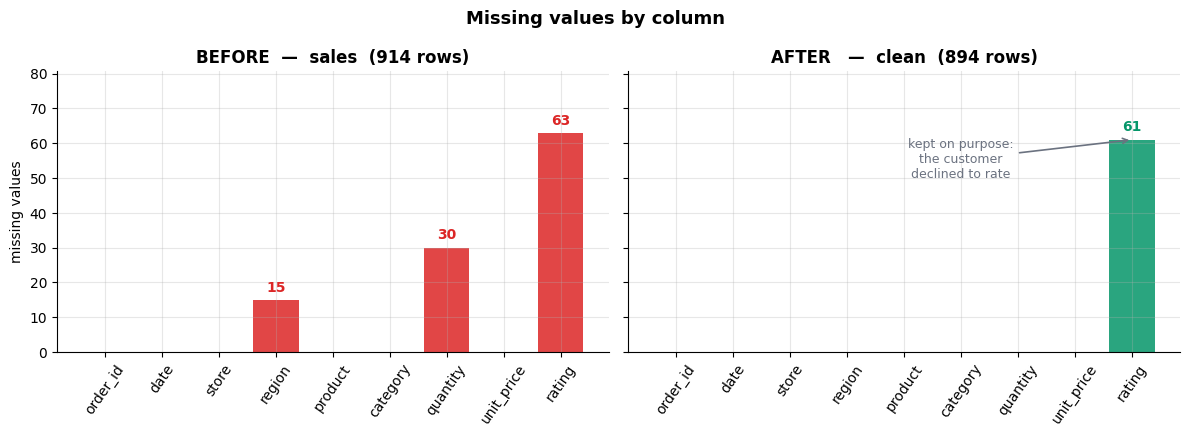

In [ ]:
# ============================================================
#  FIGURE 1 -- missing values by column, before and after
# ============================================================
cols = list(sales.columns)
before_na = sales.isna().sum().reindex(cols)
after_na  = clean.isna().sum().reindex(cols)
ymax = max(before_na.max(), after_na.max()) * 1.28

fig, axes = plt.subplots(1, 2, figsize=(12, 4.4), sharey=True)
for ax, vals, title, colour in [
    (axes[0], before_na, f"BEFORE  —  sales  ({len(sales)} rows)", C_NA),
    (axes[1], after_na,  f"AFTER   —  clean  ({len(clean)} rows)", C_GROUP),
]:
    bars = ax.bar(cols, vals.values, color=colour, alpha=0.85)
    ax.set_title(title, fontsize=12, weight="bold")
    ax.set_ylim(0, ymax)
    ax.tick_params(axis="x", rotation=55)
    for b, v in zip(bars, vals.values):
        if v:
            ax.text(b.get_x() + b.get_width() / 2, v + ymax * 0.03, str(int(v)),
                    ha="center", fontsize=10, weight="bold", color=colour)
axes[0].set_ylabel("missing values")
axes[1].annotate("kept on purpose:\nthe customer\ndeclined to rate",
                 xy=(len(cols) - 1, after_na["rating"]),
                 xytext=(len(cols) - 4.0, ymax * 0.62),
                 fontsize=9, color=C_GREY, ha="center",
                 arrowprops=dict(arrowstyle="->", color=C_GREY, lw=1.2))
fig.suptitle("Missing values by column", fontsize=13, weight="bold")
plt.tight_layout()
plt.show()


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

The same nine columns before and after, on a shared y-axis so the bars are directly comparable. On the left, three columns have gaps: 63 ratings, 30 quantities, 15 regions. On the right, two of the three are flat on the floor — `region` because every gap became `'Unassigned'`, `quantity` because every gap was imputed from a group median.

`rating` is still standing, at 61 rather than 63. It did not shrink because we filled anything; it shrank because two of the rows carrying a missing rating were among the 20 removed as duplicates or impossible quantities. Those 61 gaps are the deliberate outcome of §4.4, not unfinished work.

**The common misread:** treating a chart of all-zero bars as the goal. A cleaning pass that drives every bar to zero has almost certainly invented data. The bar you *want* left standing is the one where the honest answer is "we do not know" — and this chart's job is to make that decision visible to whoever reads your notebook next.

</div>

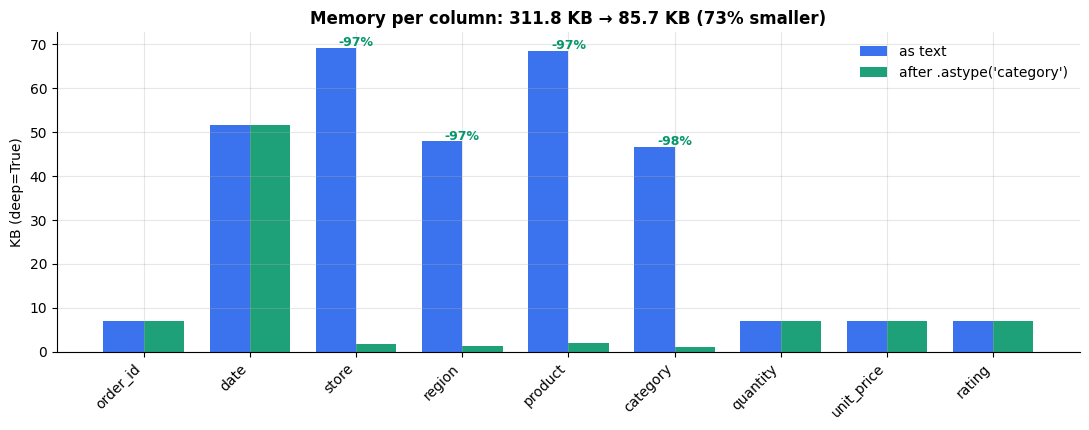

In [ ]:
# ============================================================
#  FIGURE 2 -- memory by column, before and after ->category
# ============================================================
order = [c for c in cols if c in mem_table.index]
b = (mem_table.loc[order, "bytes_before"] / 1024).values
a = (mem_table.loc[order, "bytes_after"] / 1024).values
x = np.arange(len(order)); w = 0.38

fig, ax = plt.subplots(figsize=(11, 4.4))
ax.bar(x - w / 2, b, w, label="as text", color=C_DATA, alpha=0.9)
ax.bar(x + w / 2, a, w, label="after .astype('category')", color=C_GROUP, alpha=0.9)
for xi, bv, av in zip(x, b, a):
    if bv - av > 0.5:
        ax.text(xi, bv + 0.4, f"-{100 * (1 - av / bv):.0f}%", ha="center",
                fontsize=9, weight="bold", color=C_GROUP)
ax.set_xticks(x); ax.set_xticklabels(order, rotation=45, ha="right")
ax.set_ylabel("KB (deep=True)")
ax.set_title(f"Memory per column: {b.sum():.1f} KB → {a.sum():.1f} KB "
             f"({100 * (1 - a.sum() / b.sum()):.0f}% smaller)",
             fontsize=12, weight="bold")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Per-column memory in KB, with `deep=True` so the strings are actually counted. Only four bars move, and they move a long way: the four text columns collapse by around 90% each, because 894 repetitions of `'Bakersfield'` become 894 one-byte codes plus a single copy of the word. The numeric columns — `order_id`, `quantity`, `unit_price`, `rating` — are identical in both series, since a `float64` array has no redundancy to remove, and `date` does not move because it is still text and Part 5 has not converted it yet.

**The common misread:** generalising the percentage. The saving is a function of *cardinality*, not of dtype: five distinct stores across 894 rows compress beautifully, but a column of 894 distinct order references would get **larger** as a category, because you would store every string once *plus* an integer code for each row. The rule of thumb is to convert when the number of distinct values is a small fraction of the number of rows — and to check with `.nunique()` before you commit.

</div>

In [ ]:
# ============================================================
#  The contract with the rest of the course: sales vs clean
# ============================================================
summary = pd.DataFrame({
    "sales (raw)": [
        f"{len(sales):,}",
        f"{sales.memory_usage(deep=True).sum() / 1024:,.1f} KB",
        f"{int(sales.isna().sum().sum())}",
        f"{int(sales.duplicated().sum())}",
        f"{int((sales['quantity'] < 0).sum())}",
        str(sales["unit_price"].dtype),
        str(sales["quantity"].dtype),
        f"{sales['store'].nunique()}",
    ],
    "clean": [
        f"{len(clean):,}",
        f"{clean.memory_usage(deep=True).sum() / 1024:,.1f} KB",
        f"{int(clean.isna().sum().sum())}",
        f"{int(clean.duplicated().sum())}",
        f"{int((clean['quantity'] < 0).sum())}",
        str(clean["unit_price"].dtype),
        str(clean["quantity"].dtype),
        f"{clean['store'].nunique()}",
    ],
}, index=["rows", "memory (deep)", "missing values (total)", "duplicate rows",
          "impossible quantities", "unit_price dtype", "quantity dtype",
          "distinct store labels"])
print(summary.to_string())

print("\n--- missing values, column by column ---")
print(pd.DataFrame({"sales": sales.isna().sum(),
                    "clean": clean.isna().sum().reindex(sales.columns)}).to_string())

print("\n--- dtypes ---")
print(pd.DataFrame({"sales": sales.dtypes.astype(str),
                    "clean": clean.dtypes.astype(str).reindex(sales.columns)}).to_string())

print(f"\nclean is ready: {clean.shape[0]:,} rows x {clean.shape[1]} columns")
clean.head()


                       sales (raw)     clean
rows                           914       894
memory (deep)             359.3 KB  219.8 KB
missing values (total)         108        61
duplicate rows                  14         0
impossible quantities            6         0
unit_price dtype            object   float64
quantity dtype             float64     int64
distinct store labels           10        10

--- missing values, column by column ---
            sales  clean
order_id        0      0
date            0      0
store           0      0
region         15      0
product         0      0
category        0      0
quantity       30      0
unit_price      0      0
rating         63     61

--- dtypes ---
              sales     clean
order_id      int64     int64
date         object    object
store        object    object
region       object  category
product      object    object
category     object  category
quantity    float64     int64
unit_price   object   float64
rating      float

,order_id,date,store,region,product,category,quantity,unit_price,rating
0,1063,2024-02-08,Stockton,North,cold brew,drink,6,4.25,4.2
1,1677,2024-05-17,Fresno,Central,espresso,drink,9,3.25,5.0
2,1140,2024-03-19,Stockton,North,muffin,food,9,3.50,4.1
3,1053,2024-05-27,Stockton,North,latte,drink,5,4.75,2.6
4,1825,2024-06-01,Stockton,North,bagel,food,9,2.75,4.3


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

The before/after ledger, and the handover to Part 5. 914 rows became 894 — 14 double-scans and 6 impossible quantities, every one of them accounted for above. Total missing values fell from 108 to 61, and the 61 that remain are all `rating`, all deliberate. `unit_price` is a float, `quantity` is an integer again, and the frame is smaller while carrying the same information.

The last row is the loose thread: `distinct store labels` is still 10 for five real stores, because `'FRESNO'` and `'Fresno'` are different strings. That is not an oversight — it is the next part's opening problem, and it is the same defect that left one quantity unfillable in §4.4.

**The common misread:** reading "missing values: 61" as the amount of work left. Cleanliness is not a number you minimise. `clean` is finished not because it has few NaNs but because every remaining one is there for a reason you could defend in a meeting — which is the only definition of clean that survives contact with someone asking where a figure came from.

</div>

---
<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ✅ Part 4 in eight lines

```python
clean = sales.copy()                                   # never mutate the source
clean = clean.drop_duplicates()                        # 14 double-scans out
clean = clean[~(clean["quantity"] < 0)]                # 6 impossible rows out
clean["region"]   = clean["region"].fillna("Unassigned")
clean["quantity"] = clean["quantity"].fillna(group_median)   # a sale did happen
clean["rating"]   = clean["rating"].clip(1, 5)         # NaNs stay NaN, on purpose
clean["unit_price"] = pd.to_numeric(
    clean["unit_price"].str.replace("$", "", regex=False), errors="coerce")
clean["region"] = clean["region"].astype("category")   # measured: ~90% smaller
```

Eight lines, and roughly six of them are a *decision* rather than a technique.
The techniques take an afternoon to learn. Knowing that a missing rating and a
missing quantity are not the same kind of nothing is the part that makes you
useful.

</div>

## ➡️ Next: Part 5 — transforming

`clean` is correct, but it is not yet *usable*. Two things are still wrong with
it, and both were left here deliberately because they belong to one topic:

- **`store` carries 10 labels for 5 stores.** `'FRESNO'` and `'Fresno'` are
  different strings to pandas — which is exactly what split a group into a
  singleton and left one quantity unfillable in §4.4.
- **`date` is still text.** `'2024-03-14'` happens to sort correctly as a
  string, but there is no `.dt.month`, no weekday, and no resampling.

Part 5 fixes both with the `.str` and `.dt` accessors, adds the derived columns
the rest of the course needs, and shows why looping with `.apply()` is far
slower than the vectorised expression that does the same thing.

---


---

# 5️⃣ Transforming: vectorised ops, strings, dates

## The `for` loop you are about to write is between 50 and 500 times too slow

Part 4 handed us `clean`: the prices are numbers, the duplicates are gone, the
missing values have been dealt with on their own terms. What it deliberately did
**not** touch is the two columns that need *transforming* rather than *fixing*:

- **`date` is still a string.** `'2024-03-14'` sorts correctly by luck, and that
  is the whole of what it can do. There is no `.month`, no "is this a weekend",
  no resampling — Part 8 cannot start until this column becomes a datetime.
- **`store` and `product` are still a mess.** Some store names arrived in
  uppercase, some product names arrived wrapped in spaces. Nothing is *missing*;
  every value is simply spelled two different ways, which means `groupby("store")`
  in Part 6 would report ten stores where there are five.

Fixing those is the excuse. The real subject of this part is the habit underneath
them: **you do not write a loop over rows.** Every operation here — arithmetic,
string cleaning, date parsing, conditional labelling — is expressed once, for the
whole column, and executed in C. We are going to measure exactly what that is
worth rather than assert it.

<div style="background-color: #f3e5f5; border-left: 5px solid #9c27b0; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🧭 Where this part is going

We build one new frame, **`tidy`**, from `clean`. By the end it has:

| New column | Made with |
|---|---|
| `revenue` | vectorised arithmetic |
| `store`, `product` (repaired) | the `.str` accessor |
| `date` (a real datetime) | `pd.to_datetime` |
| `day_name`, `is_weekend`, `quarter` | the `.dt` accessor |
| `size_flag` | `np.where` |
| `tier` | `np.select` |
| `rating_band` | `pd.cut` |
| `rev_quartile` | `pd.qcut` |
| `store_code` | `.map` with a dict |

**Parts 6–9 use `tidy`, not `clean` and not `sales`.**

</div>

## 5.1 Vectorised arithmetic: one expression, whole column

Revenue is quantity times unit price. In Python you would loop. In pandas you
write the expression once and it applies to every row:

```python
tidy["revenue"] = tidy["quantity"] * tidy["unit_price"]
```

No index, no loop counter, no `range(len(df))`. Two Series go in, one Series
comes out, **aligned on the index** — which matters, because if the two Series
had different indexes pandas would align them and fill the mismatches with `NaN`
rather than pairing them up by position. Here they come from the same frame, so
the indexes are identical and alignment is invisible.

Now, the claim every pandas tutorial makes is that this is "much faster" than a
loop. That is true, and it is worth knowing *how much*, because the answer is
larger than most people guess. So we will compute the identical column three
ways and time all three.


In [ ]:
import time

# `clean` is Part 4's output and we leave it alone, exactly as Part 4 left
# `sales` alone. Everything from here lands in a new frame.
tidy = clean.copy()
print(f"tidy: {tidy.shape[0]:,} rows x {tidy.shape[1]} columns   "
      f"(date dtype is still {tidy['date'].dtype})\n")


def best_of(fn, repeat=5):
    """Fastest of `repeat` runs -- the fastest run is the one least polluted
    by the OS scheduling something else on top of us."""
    best = float("inf")
    for _ in range(repeat):
        t0 = time.perf_counter()
        out = fn()
        best = min(best, time.perf_counter() - t0)
    return best, out

# --- 1. the Python loop, written the way a beginner writes it -------------
def by_loop():
    values = []
    for _, row in tidy.iterrows():
        values.append(row["quantity"] * row["unit_price"])
    return pd.Series(values, index=tidy.index)

# --- 2. .apply(axis=1): looks vectorised, is not ---------------------------
def by_apply():
    return tidy.apply(lambda r: r["quantity"] * r["unit_price"], axis=1)

# --- 3. the vectorised expression -----------------------------------------
def by_vector():
    return tidy["quantity"] * tidy["unit_price"]

t_loop,  r_loop  = best_of(by_loop)
t_apply, r_apply = best_of(by_apply)
t_vec,   r_vec   = best_of(by_vector)

# all three must produce the SAME numbers, or the comparison is meaningless
same = (np.allclose(r_loop, r_vec, equal_nan=True) and
        np.allclose(r_apply, r_vec, equal_nan=True))

timings = pd.DataFrame({
    "approach":     ["for + iterrows", "apply(axis=1)", "vectorised"],
    "milliseconds": [t_loop * 1e3, t_apply * 1e3, t_vec * 1e3],
    "x slower":     [t_loop / t_vec, t_apply / t_vec, 1.0],
})

print(f"rows: {len(tidy):,}    identical results from all three: {same}\n")
print(timings.to_string(index=False, float_format=lambda v: f"{v:10.3f}"))

tidy["revenue"] = r_vec        # keep the fast one
print(f"\ntotal revenue: ${tidy['revenue'].sum():,.2f}")


tidy: 894 rows x 9 columns   (date dtype is still object)

rows: 894    identical results from all three: True

      approach  milliseconds   x slower
for + iterrows        54.837    548.815
 apply(axis=1)        11.668    116.772
    vectorised         0.100      1.000

total revenue: $24,867.25


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Three implementations of the same column, timed on this frame. The three results are checked to be identical first — a speed comparison between programs that compute different things is worthless. `iterrows` is the slowest by a wide margin because it builds a fresh Series object for every single row, and each of those Series has to carry the column labels. `apply(axis=1)` is faster but still a Python-level loop wearing a vectorised-looking coat; it does the same per-row object construction, just in pandas' C loop instead of yours. The vectorised expression hands two contiguous float arrays to NumPy and multiplies them in one pass.

**The exact ratios are printed by the cell and will differ on your machine** — the shape is what matters, and on this run the loop landed in the hundreds and `apply` in the tens.

**The common misread:** reading `apply` as "the vectorised way to apply a function". It is not. `apply(axis=1)` is a `for` loop with better manners — the column sits in the middle of the printed table, not next to the vectorised row, and that position is the entire lesson.

</div>

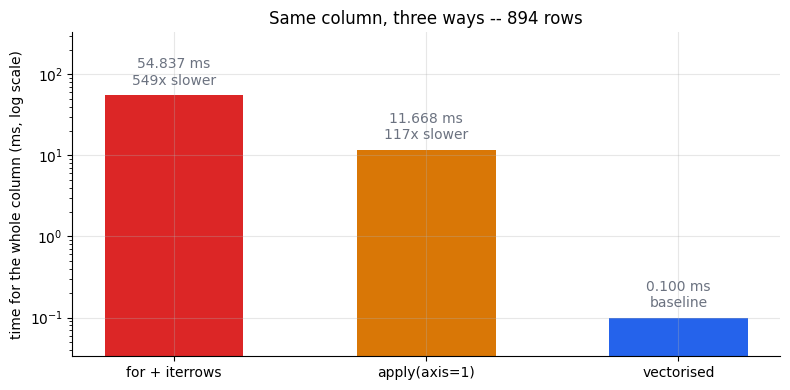

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))

labels = timings["approach"]
values = timings["milliseconds"]
colors = [C_NA, C_WARN, C_DATA]

bars = ax.bar(labels, values, color=colors, width=0.55)
ax.set_yscale("log")
ax.set_ylabel("time for the whole column (ms, log scale)")
ax.set_title(f"Same column, three ways -- {len(tidy):,} rows")

for bar, v, mult in zip(bars, values, timings["x slower"]):
    tag = f"{v:.3f} ms" + (f"\n{mult:,.0f}x slower" if mult > 1.01 else "\nbaseline")
    ax.text(bar.get_x() + bar.get_width() / 2, v * 1.25, tag,
            ha="center", va="bottom", fontsize=10, color=C_GREY)

ax.set_ylim(values.min() / 3, values.max() * 6)
plt.tight_layout()
plt.show()


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

The same three timings on a **logarithmic** y-axis, because on a linear axis the vectorised bar would be invisible — it would be a flat line at the bottom and you would learn nothing from it. Each gridline step is a factor of ten, so the vertical gap between two bars *is* the order-of-magnitude gap between the two approaches.

The frame here is under a thousand rows. The gap does not close as the data grows — it widens, because the vectorised version keeps doing one pass over contiguous memory while the loop keeps paying Python's per-row object cost.

**The common misread:** deciding the loop is fine because a few milliseconds is nothing. It is nothing *here*. The habit is what scales: the same loop on ten million rows is minutes, and the same vectorised expression is still one pass.

</div>

<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ The trap

**The failure first.** You reach for `apply` to combine two columns and forget the axis:

```python
tidy[["quantity", "unit_price"]].apply(lambda r: r["quantity"] * r["unit_price"])
# KeyError: 'quantity'
```

**Why.** `DataFrame.apply` defaults to **`axis=0`**, which means "apply this function to each *column*". So `r` is not a row — it is the entire `quantity` column as a Series, and `r["quantity"]` is asking that column for a *row label* called `quantity`, which does not exist.

**Why it is nastier than it looks.** With a default integer index the KeyError is loud and you fix it in ten seconds. But if the frame's index happened to contain the string you asked for, you would get a number back and no error at all — a wrong column, computed silently. And `axis=0` is the *right* default for the common case (`df.apply(np.mean)` should mean "mean of each column"), so it is never going away.

**The fix.** Pass `axis=1` when you mean rows — and then ask yourself whether you needed `apply` at all, since `df["a"] * df["b"]` is the same answer two orders of magnitude faster.

</div>

## 5.2 The `.str` accessor: string methods, one column at a time

Python strings have `.strip()`, `.lower()`, `.replace()`. A *column* of strings
does not — a Series is not a string, so `tidy["store"].lower()` is an
`AttributeError`. pandas puts the whole of Python's string API behind an
**accessor** instead:

```python
tidy["store"].str.lower()
```

Read `.str` as "for each element, as a string". Everything after it is the
familiar Python method, applied elementwise and returned as a new Series.

This is where the `store` and `product` mess gets fixed, and the fix is worth
watching closely: **nothing here is missing, mistyped or malformed.** Every value
is a perfectly good store name. The damage is that `"FRESNO"` and `"Fresno"` are
different strings, so every count, group and join treats them as different
stores. Let us prove the damage is real before repairing it.


In [ ]:
before_store   = tidy["store"].nunique()
before_product = tidy["product"].nunique()

print("BEFORE")
print(f"  store   : {before_store} distinct values -> {sorted(tidy['store'].unique())}")
print(f"  product : {before_product} distinct values")
print(f"            {sorted(repr(p) for p in tidy['product'].unique())}")

# --- the repair -----------------------------------------------------------
# .strip() removes leading/trailing whitespace; .title() and .lower() force
# one spelling. Each returns a NEW Series -- we assign it back explicitly.
tidy["store"]   = tidy["store"].str.strip().str.title()
tidy["product"] = tidy["product"].str.strip().str.lower()

after_store   = tidy["store"].nunique()
after_product = tidy["product"].nunique()

print("\nAFTER")
print(f"  store   : {after_store} distinct values -> {sorted(tidy['store'].unique())}")
print(f"  product : {after_product} distinct values -> {sorted(tidy['product'].unique())}")
print(f"\nphantom categories removed: "
      f"{(before_store - after_store) + (before_product - after_product)}")


BEFORE
  store   : 10 distinct values -> ['BAKERSFIELD', np.str_('Bakersfield'), 'FRESNO', np.str_('Fresno'), 'MODESTO', np.str_('Modesto'), 'SALINAS', 'STOCKTON', np.str_('Salinas'), np.str_('Stockton')]
  product : 12 distinct values
            ["'  bagel '", "'  cold brew '", "'  cookie '", "'  espresso '", "'  latte '", "'  muffin '", "np.str_('bagel')", "np.str_('cold brew')", "np.str_('cookie')", "np.str_('espresso')", "np.str_('latte')", "np.str_('muffin')"]

AFTER
  store   : 5 distinct values -> ['Bakersfield', 'Fresno', 'Modesto', 'Salinas', 'Stockton']
  product : 6 distinct values -> ['bagel', 'cold brew', 'cookie', 'espresso', 'latte', 'muffin']

phantom categories removed: 11


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

The distinct-value count for `store` and `product` before and after two chained string methods. Before, the uppercase variants and the space-wrapped variants are counted as their own categories — the `repr()` around the product values is deliberate, because `'  latte '` and `'latte'` print identically in a table and only quoting them shows the spaces that make them different keys. After `.str.strip()` and a case fold, each column collapses to its true number of categories.

Note that no rows were removed and no values were corrected. The counts moved because *identity* changed, not because data did.

**The common misread:** treating this as cosmetic tidying to do at the end. It is the opposite — it has to happen *before* any `groupby`, `merge` or `value_counts`, because every one of those operations decides what matches what by exact string equality. Run Part 6 on the unfixed column and you get a report with two rows per store and no error to tell you so.

</div>

<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ The trap

**The failure first.** `.str` is not universal — it is a *string* accessor, and it fails in two completely different ways depending on the dtype:

```python
tidy["quantity"].str.strip()
# AttributeError: Can only use .str accessor with string values, not floating

pd.Series(["7", 8, "9"], dtype=object).str.strip()
# ['7', nan, '9']   <- no error at all; the int silently became NaN
```

**Why.** On a purely numeric column pandas can see the dtype is wrong and raises immediately. On an **object** column it cannot — object means "anything", so it applies the method elementwise and writes `NaN` wherever the element was not a string. The loud version is the lucky one.

**The same trap wearing a different hat:** `.str.contains()` on a column containing `None` returns a *three-valued* result — `True`, `False`, `None` — and using it as a mask raises `ValueError: Cannot mask with non-boolean array containing NA / NaN values`. The cure is `na=False` (or `na=True`), stated deliberately, because pandas genuinely does not know whether a missing value should match your pattern.

**The fix.** Check `.dtype` before reaching for `.str`, and if a column is object because it is mixed, decide what the non-strings mean before you convert: `.astype(str)` would turn the integer `8` into the string `'8'` and a `None` into the string `'None'`, which is usually worse than the NaN.

</div>

In [ ]:
# The rest of the .str API, on the now-clean columns.
prod, store = tidy["product"], tidy["store"]

# --- membership and prefixes: both return boolean Series, usable as masks --
is_brew   = prod.str.contains("brew")          # substring, regex by default
starts_c  = prod.str.startswith("c")           # literal prefix, no regex

# --- splitting into columns -----------------------------------------------
# expand=True turns the list-of-pieces into a DataFrame; rows with fewer
# pieces than the widest row get None, which is why "espresso" has no second.
words = prod.str.split(" ", expand=True)
words.columns = ["word_1", "word_2"]

# --- extract with a regex: only the CAPTURE GROUPS come back --------------
# Named groups become column names, which is why this is worth the regex.
initials = store.str.extract(r"^(?P<initial>[A-Z])(?P<rest>.+)$")

# --- length, and gluing two columns together ------------------------------
name_len = prod.str.len()
label    = store.str.cat(prod, sep=" / ")      # NOT store + " / " + prod on NaN

summary = pd.DataFrame({
    "product":   prod,
    "word_1":    words["word_1"],
    "word_2":    words["word_2"],
    "len":       name_len,
    "initial":   initials["initial"],
    "label":     label,
    "has_brew":  is_brew,
    "starts_c":  starts_c,
})

print(summary.head(8).to_string())
print(f"\nrows containing 'brew'  : {is_brew.sum():>4}")
print(f"rows starting with 'c'  : {starts_c.sum():>4}")
print(f"products that are two words: "
      f"{words['word_2'].notna().sum()} of {len(words)}")

# --- and what a CHAIN of these costs --------------------------------------
# Each link is its own full pass over the column. If that is true, four links
# should cost about four times one link -- so let us check.
def four_links(s):
    return s.str.strip().str.lower().str.replace(" ", "_", regex=False).str.title()

chain_cost = []
for size, s in [("this frame", clean["product"]),
                ("x80 copies", pd.concat([clean["product"]] * 80, ignore_index=True))]:
    t1, _ = best_of(lambda: s.str.strip(), repeat=7)
    t4, _ = best_of(lambda: four_links(s),  repeat=7)
    chain_cost.append({"column": size, "rows": len(s), "1 link (ms)": t1 * 1e3,
                       "4 links (ms)": t4 * 1e3, "ratio": t4 / t1})

print("\ncost of chaining .str calls:")
print(pd.DataFrame(chain_cost).to_string(index=False,
      float_format=lambda v: f"{v:9.3f}"))


     product    word_1 word_2  len initial                   label  has_brew  starts_c
0  cold brew      cold   brew    9       S    Stockton / cold brew      True      True
1   espresso  espresso   None    8       F       Fresno / espresso     False     False
2     muffin    muffin   None    6       S       Stockton / muffin     False     False
3      latte     latte   None    5       S        Stockton / latte     False     False
4      bagel     bagel   None    5       S        Stockton / bagel     False     False
5      bagel     bagel   None    5       S        Stockton / bagel     False     False
6   espresso  espresso   None    8       B  Bakersfield / espresso     False     False
7     muffin    muffin   None    6       F         Fresno / muffin     False     False

rows containing 'brew'  :  130
rows starting with 'c'  :  268
products that are two words: 130 of 894

cost of chaining .str calls:
    column  rows  1 link (ms)  4 links (ms)     ratio
this frame   894        0.564 

<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Eight rows showing every `.str` method side by side on the same product name. `split(expand=True)` is the one to look at hardest: it returns a **DataFrame**, one column per piece, sized by the row with the most pieces — `cold brew` fills both columns and `espresso` leaves `word_2` as `None`. Without `expand=True` you would get a single column of Python lists, which is almost never what you want and is very slow to work with afterwards.

`extract` differs from `contains` in what it returns: `contains` answers a yes/no question and gives you a mask, `extract` pulls the matched **capture groups** out as columns. Text outside a group is matched but discarded, which is why the `^` and `.+` in the pattern cost nothing.

**The common misread:** expecting `extract` to return every match in a string. It returns the *first* match only, one row per input row. For all matches you want `.str.extractall()`, which returns a differently-shaped frame with a MultiIndex — a different tool for a different question.

---

**The second table** times one `.str` call against a chain of four, at two frame sizes. The `ratio` column is the whole point: it lands several times above one, at both sizes. Four links really do cost several times what one link costs, which is only possible if each link walks the whole column again from the start. The absolute milliseconds are tiny and machine-dependent; the ratio is the stable, portable fact, and the box below says what to do about it.

**The common misread on that one:** concluding `.str` is slow. It is not — one link over tens of thousands of strings is a couple of milliseconds. The measurement is about how the cost *composes*, not about the cost of one call.

</div>

<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ The trap

**The failure first — except this one does not raise, it just costs.** Every link in a `.str` chain is a separate full pass over the column, and each one allocates a brand-new array that the next link immediately throws away:

```python
s.str.strip().str.lower().str.replace(" ", "_").str.title()
#  ^ 4 passes, 4 full-size intermediate arrays, 3 of them instant garbage
```

The cell above measured exactly that, and the `ratio` **is** the proof: if the chain were fused into a single pass, four links would cost about what one link costs, and the printed ratio would sit near one instead of several times above it.

**What this does and does not mean.** It does *not* mean replace the chain with a Python `.map(lambda s: ...)` — each `.str` pass runs in C, and on a frame this size the chain is competitive with that. It means two narrower things: (1) on a frame large enough to matter, peak memory is several full copies of the column rather than one, and (2) chaining half a dozen cosmetic string ops out of habit is paying that cost for nothing.

**The fix.** Do the repair once, assign it back, and work with the repaired column — which is exactly what §5.2 did to `store` and `product`, and why nothing downstream calls `.str.strip()` again.

</div>

## 5.3 Datetimes: from a string that looks like a date to a date

`'2024-03-14'` is nine characters. It has no month, no weekday, no notion of the
day after it. `pd.to_datetime` converts the column to a real `datetime64` dtype,
after which pandas will do arithmetic on it, sort it meaningfully, resample it
(Part 8) and expose every calendar field through the `.dt` accessor.

Two arguments decide how it behaves and both are worth knowing before you need
them:

- **`format=`** — the exact strptime pattern, e.g. `"%Y-%m-%d"`. Without it
  pandas has to work out the layout itself.
- **`errors=`** — what to do with a value that will not parse. `'raise'`
  (the default) stops; `'coerce'` writes `NaT` and carries on.

The usual advice is "always pass `format=`, it is much faster". We will measure
that instead of repeating it, because on this data the honest answer has two
halves and only one of them matches the slogan.


In [ ]:
date_str = tidy["date"]

# our dates are ISO-8601 -- pandas has a dedicated fast path for those
t_infer, _ = best_of(lambda: pd.to_datetime(date_str), repeat=7)
t_fmt,   _ = best_of(lambda: pd.to_datetime(date_str, format="%Y-%m-%d"), repeat=7)

# the same dates written the way a European spreadsheet exports them
euro = pd.to_datetime(date_str, format="%Y-%m-%d").dt.strftime("%d %b %Y")
t_euro_infer, _ = best_of(lambda: pd.to_datetime(euro), repeat=7)
t_euro_fmt,   _ = best_of(lambda: pd.to_datetime(euro, format="%d %b %Y"), repeat=7)
# 'mixed' is what you are forced into when the column is genuinely inconsistent:
# pandas gives up on one shared pattern and parses each element on its own.
t_euro_mixed, _ = best_of(lambda: pd.to_datetime(euro, format="mixed"), repeat=7)

bench = pd.DataFrame([
    {"input": "ISO '2024-03-14'",  "call": "no format=",        "ms": t_infer * 1e3},
    {"input": "ISO '2024-03-14'",  "call": "format='%Y-%m-%d'", "ms": t_fmt * 1e3},
    {"input": "'14 Mar 2024'",     "call": "no format=",        "ms": t_euro_infer * 1e3},
    {"input": "'14 Mar 2024'",     "call": "format='%d %b %Y'", "ms": t_euro_fmt * 1e3},
    {"input": "'14 Mar 2024'",     "call": "format='mixed'",    "ms": t_euro_mixed * 1e3},
])
bench["x vs explicit format"] = [t_infer / t_fmt, 1.0,
                                 t_euro_infer / t_euro_fmt, 1.0,
                                 t_euro_mixed / t_euro_fmt]
print(bench.to_string(index=False, float_format=lambda v: f"{v:8.3f}"))

# --- errors=: the same column with three unparseable values ---------------
broken = date_str.copy()
broken.iloc[[3, 17, 40]] = "not a date"
try:
    pd.to_datetime(broken)
except ValueError as e:
    print(f"\nerrors='raise' (the default) -> ValueError: {str(e)[:70]}...")

coerced = pd.to_datetime(broken, errors="coerce")
print(f"errors='coerce'              -> dtype {coerced.dtype}, "
      f"{coerced.isna().sum()} NaT, no exception")

# --- and now, for real ----------------------------------------------------
tidy["date"] = pd.to_datetime(tidy["date"], format="%Y-%m-%d")
print(f"\ntidy['date'] is now {tidy['date'].dtype}, "
      f"spanning {tidy['date'].min().date()} to {tidy['date'].max().date()}")


           input              call       ms  x vs explicit format
ISO '2024-03-14'        no format=    0.702                 1.666
ISO '2024-03-14' format='%Y-%m-%d'    0.421                 1.000
   '14 Mar 2024'        no format=    2.990                 1.120
   '14 Mar 2024' format='%d %b %Y'    2.669                 1.000
   '14 Mar 2024'    format='mixed'   49.243                18.451

errors='raise' (the default) -> ValueError: time data "not a date" doesn't match format "%Y-%m-%d", at position 3....
errors='coerce'              -> dtype datetime64[ns], 3 NaT, no exception

tidy['date'] is now datetime64[ns], spanning 2024-01-01 to 2024-06-28


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Five ways of parsing the same dates, timed, plus what `errors=` does. Read the `x vs explicit format` column against the slogan "always pass `format=`, it is much faster":

For the **ISO** rows the speedup is modest, not dramatic. pandas 3.x special-cases ISO-8601, so leaving `format=` off costs you an inference step on the first element and then takes the same fast path anyway. The slogan is technically true here and practically irrelevant.

For the **`'14 Mar 2024'`** rows the picture changes, and the row that matters is `format='mixed'` — more than an order of magnitude slower than naming the format, because `'mixed'` abandons the one-pattern assumption and parses every element independently. That is the real cost, and it is the cost you pay when your column is inconsistent enough that pandas cannot use one pattern at all.

**The common misread:** reading the small ISO speedup as "so `format=` does not matter". Speed is the lesser reason to pass it. The larger one is in the next box: inference is a *guess*, and a guess that changes with your data is not something to build a pipeline on.

</div>

<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ The trap

**The failure first — and it is a silent one.**

```python
pd.to_datetime(broken, errors="coerce")
# no exception, no warning; three rows are now NaT
```

`errors='coerce'` is the single most dangerous convenience in pandas, because it converts a *data problem you would have been told about* into *missing values you have to go looking for*. The cell above shows it: `'raise'` names the offending value; `'coerce'` returns a clean-looking datetime column with three holes in it. If you reach for `coerce` to make an error go away, you have not fixed anything — you have moved it downstream, where it will surface as a mysteriously short groupby result.

**If you use it, count what it ate.** `pd.to_datetime(s, errors='coerce').isna().sum() - s.isna().sum()` is the number of values it destroyed. Print it.

**The other half: inference is a guess that can change.** With no `format=`, `'01/02/2024'` is the 2nd of January in one file and the 1st of February in another, and pandas decides from the data it happens to see. Add `dayfirst=True` and it flips. Nothing errors either way — the same code silently means different things on different inputs. **Pass `format=` because it is unambiguous**, and take the speed as a bonus.

</div>

In [ ]:
# The .dt accessor: same idea as .str, but for datetimes. Every field is a
# vectorised read straight out of the datetime64 values -- no parsing, no loop.
d = tidy["date"]

tidy["year"]       = d.dt.year
tidy["month"]      = d.dt.month
tidy["day"]        = d.dt.day
tidy["dayofweek"]  = d.dt.dayofweek        # Monday=0 ... Sunday=6
tidy["day_name"]   = d.dt.day_name()       # a STRING, and locale-dependent
tidy["quarter"]    = d.dt.quarter
tidy["month_end"]  = d.dt.is_month_end     # boolean, no arithmetic needed

# The derived flag the rest of the notebook leans on.
tidy["is_weekend"] = d.dt.dayofweek >= 5

cal = tidy[["date", "year", "month", "day", "dayofweek",
            "day_name", "quarter", "month_end", "is_weekend"]]
print(cal.head(6).to_string(index=False))

print(f"\nweekend rows      : {tidy['is_weekend'].sum():>4} "
      f"of {len(tidy)}  ({tidy['is_weekend'].mean():.1%})")
print(f"month-end rows    : {tidy['month_end'].sum():>4}")
print("orders per quarter:",
      tidy["quarter"].value_counts().sort_index().to_dict())


      date  year  month  day  dayofweek day_name  quarter  month_end  is_weekend
2024-02-08  2024      2    8          3 Thursday        1      False       False
2024-05-17  2024      5   17          4   Friday        2      False       False
2024-03-19  2024      3   19          1  Tuesday        1      False       False
2024-05-27  2024      5   27          0   Monday        2      False       False
2024-06-01  2024      6    1          5 Saturday        2      False        True
2024-04-06  2024      4    6          5 Saturday        2      False        True

weekend rows      :  235 of 894  (26.3%)
month-end rows    :   30
orders per quarter: {1: 460, 2: 434}


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Six rows with every `.dt` field printed next to the date it came from. Check the mapping yourself on the first row: `dayofweek` counts from **Monday = 0**, so `5` and `6` are Saturday and Sunday, which is exactly what `is_weekend` tests for.

Two of these are not like the others. `day_name()` is a **method call**, not an attribute, because it takes a `locale` argument — and it returns strings, so it sorts alphabetically (Friday, Monday, Saturday...) unless you order it deliberately, which is what the next figure has to do. `is_month_end` is a genuine calendar computation: it knows February has 29 days in 2024.

The weekend share printed underneath is close to the two-sevenths you would expect if orders fell evenly across all days — it does **not** say weekends are quiet. Volume and value are different questions, and the next figure asks the second one.

**The common misread:** assuming `.dt.month` gives you a month you can group on across years. It gives you `1`–`12` with the year thrown away, so January 2024 and January 2025 land in the same bucket. When you mean "which calendar month", you want `.dt.to_period("M")`, and Part 8 uses it.

</div>

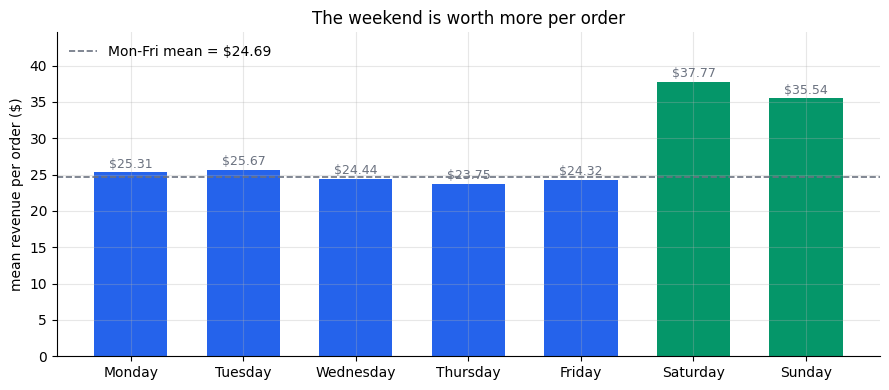

Mon-Fri mean revenue/order : $24.69
Sat-Sun mean revenue/order : $36.58
weekend lift               : +48.1%


In [ ]:
DAY_ORDER = ["Monday", "Tuesday", "Wednesday", "Thursday",
             "Friday", "Saturday", "Sunday"]

by_day = (tidy.groupby("day_name", observed=True)["revenue"]
              .mean()
              .reindex(DAY_ORDER))          # calendar order, not alphabetical

weekday_mean = tidy.loc[~tidy["is_weekend"], "revenue"].mean()
weekend_mean = tidy.loc[tidy["is_weekend"],  "revenue"].mean()
lift = weekend_mean / weekday_mean - 1

fig, ax = plt.subplots(figsize=(9, 4))
colors = [C_GROUP if day in ("Saturday", "Sunday") else C_DATA for day in DAY_ORDER]
bars = ax.bar(by_day.index, by_day.values, color=colors, width=0.65)

ax.axhline(weekday_mean, color=C_GREY, ls="--", lw=1.2,
           label=rf"Mon-Fri mean = \${weekday_mean:,.2f}")
ax.set_ylabel(r"mean revenue per order (\$)")
ax.set_title("The weekend is worth more per order")
ax.legend(loc="upper left", frameon=False)

for bar, v in zip(bars, by_day.values):
    ax.text(bar.get_x() + bar.get_width() / 2, v + 0.6, rf"\${v:,.2f}",
            ha="center", fontsize=9, color=C_GREY)

ax.set_ylim(0, by_day.max() * 1.18)
plt.tight_layout()
plt.show()

print(f"Mon-Fri mean revenue/order : ${weekday_mean:,.2f}")
print(f"Sat-Sun mean revenue/order : ${weekend_mean:,.2f}")
print(f"weekend lift               : {lift:+.1%}")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Mean revenue per order for each weekday, in calendar order, with the two weekend bars picked out in green and the Monday–Friday mean drawn as a dashed line. The two green bars clear the dashed line and the five blue ones sit on it — the exact lift is printed under the figure.

This effect is genuinely in the data rather than an artefact of the chart: Part 0 generated weekend baskets from a Poisson distribution with a higher mean, so more items go into a weekend order. Nothing about the price changes at the weekend; only the quantity does.

Note the `.reindex(DAY_ORDER)`. Without it the bars come out alphabetical — Friday, Monday, Saturday, Sunday, Thursday, Tuesday, Wednesday — because `day_name()` returns strings and pandas sorts strings as strings. The chart would still be *correct* and would be nearly unreadable.

**The common misread:** reading this as "weekends make more money". It says weekends make more money **per order**. Whether they make more money in total also depends on how many orders there are, which is a different aggregation — and precisely the kind of question Part 6 exists to answer properly.

</div>

## 5.4 Conditional columns without an `if`

"Label each row A, B, C or D depending on its revenue" is the request that
tempts everyone back into a loop, because `if`/`elif` is how you say it in
English. pandas has five tools for it and choosing between them is mostly about
how many branches you have:

| Tool | Use it for | Returns |
|---|---|---|
| `np.where(cond, a, b)` | exactly **two** outcomes | array |
| `np.select([c1, c2, ...], [v1, v2, ...], default=)` | **many** conditions, first match wins | array |
| `pd.cut(s, bins=...)` | cutting a **continuous** column at **fixed** edges | Categorical |
| `pd.qcut(s, q)` | cutting it into **equal-sized** groups | Categorical |
| `s.map(dict)` | a **lookup table** from old value to new | Series |

All five are vectorised. All five evaluate every branch for every row — which is
the one thing that makes them behave differently from an `if`, and the thing to
watch out for when a branch could raise.


In [ ]:
# --- two outcomes: np.where ----------------------------------------------
BULK = 8
tidy["size_flag"] = np.where(tidy["quantity"] >= BULK, "bulk", "normal")

# --- many outcomes: np.select. Conditions are tested IN ORDER and the
#     FIRST match wins, so these must be written most-specific first.
conds  = [tidy["revenue"] >= 40, tidy["revenue"] >= 20, tidy["revenue"] >= 10]
labels = ["A (>= 40)", "B (20-40)", "C (10-20)"]
tidy["tier"] = np.select(conds, labels, default="D (< 10)")

# --- fixed edges: pd.cut. right=True by default => (0, 3] excludes 0,
#     includes 3. Rows with a NaN rating stay NaN; they are not a band.
tidy["rating_band"] = pd.cut(tidy["rating"],
                             bins=[0, 3, 4, 4.5, 5],
                             labels=["poor", "ok", "good", "great"])

# --- equal-sized groups: pd.qcut. The EDGES come from the data.
tidy["rev_quartile"] = pd.qcut(tidy["revenue"], q=4,
                               labels=["Q1", "Q2", "Q3", "Q4"])

# --- a lookup table: .map with a dict -------------------------------------
STORE_CODE = {"Bakersfield": "BAK", "Fresno": "FRE", "Modesto": "MOD",
              "Salinas": "SAL", "Stockton": "STO"}
tidy["store_code"] = tidy["store"].map(STORE_CODE)

for col in ["size_flag", "tier", "rating_band", "rev_quartile", "store_code"]:
    counts = tidy[col].value_counts(dropna=False).sort_index()
    print(f"{col:<13} {counts.to_dict()}")

print(f"\nrating_band is NaN for {tidy['rating_band'].isna().sum()} rows "
      f"(the ratings Part 4 left missing)")
print(f"store_code unmapped     : {tidy['store_code'].isna().sum()} rows")


size_flag     {'bulk': 453, 'normal': 441}
tier          {'A (>= 40)': 151, 'B (20-40)': 473, 'C (10-20)': 234, 'D (< 10)': 36}
rating_band   {'poor': 29, 'ok': 390, 'good': 243, 'great': 171, nan: 61}
rev_quartile  {'Q1': 230, 'Q2': 226, 'Q3': 219, 'Q4': 219}
store_code    {'BAK': 186, 'FRE': 188, 'MOD': 159, 'SAL': 186, 'STO': 175}

rating_band is NaN for 61 rows (the ratings Part 4 left missing)
store_code unmapped     : 0 rows


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

The value counts for all five new columns. Compare the two binning columns, because they answer different questions from the same kind of input. `rating_band` uses **edges you chose**, so the buckets come out wildly uneven — that is not a bug, it is the shape of the ratings, and it is exactly what you want when the edges mean something ("below 3 is a complaint"). `rev_quartile` uses **edges the data chose**, so the four buckets are near-identical in size by construction and the edges themselves are whatever revenue values split the column in four.

`rating_band` is `NaN` for the rows with no rating, and the count is printed. Neither `cut` nor `qcut` invents a bucket for missing input, which is the right behaviour — an unrated order is not a badly-rated one.

`store_code` has zero unmapped rows, and that is only true because §5.2 fixed the case first. Run `.map(STORE_CODE)` on the raw column and every `'FRESNO'` row silently becomes `NaN`, because `.map` returns `NaN` for any key the dict does not contain.

**The common misread:** expecting `np.select` to behave like `elif` and skip conditions after the first match. It does not skip anything — it evaluates **all** the condition arrays for **all** the rows, then picks per row. So a condition that would divide by zero on rows another branch was meant to catch will still divide by zero. Guard the expression, not the branch order.

</div>

## 5.5 `apply` vs `map` vs `DataFrame.map`, and the chained style

Three methods with confusingly similar names. What separates them is **what one
call of your function receives**:

| Call | Your function gets | Returns |
|---|---|---|
| `Series.map(f)` | one **scalar** | Series |
| `Series.apply(f)` | one **scalar** | Series (`map` also accepts a dict/Series) |
| `DataFrame.apply(f)` | one **Series** — a column by default, a row with `axis=1` | Series or DataFrame |
| `DataFrame.map(f)` | one **scalar**, every cell | DataFrame |

`DataFrame.map` is the elementwise one and it was called `applymap` until
pandas 2.1; `applymap` still works and is deprecated, so you will meet both names
in older code and should write the new one.

**When is `apply` genuinely necessary?** When the operation truly needs a whole
row or a whole column at once and no vectorised equivalent exists — a per-row
call to an external API, a function from another library that only takes scalars,
a stateful transformation. That is a real and small set. Everything else —
arithmetic, comparisons, string ops, date ops, conditional labelling — has a
vectorised form, and §5.1 measured what choosing `apply` for those costs.

### `assign` and the chain

`assign` adds columns and returns a **new** frame, so it composes. That lets a
whole transformation read top to bottom as one expression with no intermediate
names and no chance of forgetting to assign a step back. Inside `assign`, use a
`lambda d: ...` rather than naming the outer frame — `d` is the frame *as it
exists at that point in the chain*, which is what makes each line able to use the
columns the lines above it just added.


In [ ]:
# --- the three, on the same data, so the difference is visible ------------
per_cell   = tidy[["quantity", "revenue"]].map(lambda v: round(v, 1))     # scalar in
per_column = tidy[["quantity", "revenue"]].apply(lambda s: s.max() - s.min())  # Series in
per_scalar = tidy["product"].map(str.title)                               # scalar in

print("DataFrame.map -> one call per CELL, same shape back:")
print(per_cell.head(3).to_string(), "\n")
print("DataFrame.apply (axis=0) -> one call per COLUMN, one number each:")
print(per_column.to_string(), "\n")
print("Series.map -> one call per VALUE:", per_scalar.unique()[:3].tolist(), "\n")

# --- the whole of Part 5 as one chain -------------------------------------
tidy_chained = (
    clean
    .assign(
        store      = lambda d: d["store"].str.strip().str.title(),
        product    = lambda d: d["product"].str.strip().str.lower(),
        date       = lambda d: pd.to_datetime(d["date"], format="%Y-%m-%d"),
        revenue    = lambda d: d["quantity"] * d["unit_price"],
        # these three depend on columns assigned ABOVE them in this same call
        day_name   = lambda d: d["date"].dt.day_name(),
        is_weekend = lambda d: d["date"].dt.dayofweek >= 5,
        tier       = lambda d: np.select(
            [d["revenue"] >= 40, d["revenue"] >= 20, d["revenue"] >= 10],
            ["A (>= 40)", "B (20-40)", "C (10-20)"], default="D (< 10)"),
    )
)

shared = ["store", "product", "date", "revenue", "day_name", "is_weekend", "tier"]
print("chain reproduces the step-by-step version exactly:",
      tidy_chained[shared].equals(tidy[shared]))
print(f"tidy: {tidy.shape[0]:,} rows x {tidy.shape[1]} columns "
      f"(clean had {clean.shape[1]})")
print("columns added by Part 5:",
      [c for c in tidy.columns if c not in clean.columns])


DataFrame.map -> one call per CELL, same shape back:
   quantity  revenue
0         6     25.5
1         9     29.2
2         9     31.5 

DataFrame.apply (axis=0) -> one call per COLUMN, one number each:
quantity    20.00
revenue     85.75 

Series.map -> one call per VALUE: ['Cold Brew', 'Espresso', 'Muffin'] 

chain reproduces the step-by-step version exactly: True
tidy: 894 rows x 23 columns (clean had 9)
columns added by Part 5: ['revenue', 'year', 'month', 'day', 'dayofweek', 'day_name', 'quarter', 'month_end', 'is_weekend', 'size_flag', 'tier', 'rating_band', 'rev_quartile', 'store_code']


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

The three `map`/`apply` variants printed one after another so the shapes are directly comparable: `DataFrame.map` gives back a frame the same shape as the input, `DataFrame.apply` with the default `axis=0` collapses each column to a single number, and `Series.map` gives back a Series. The function you pass is identical in kind; only what it *receives* differs, and that is the whole distinction.

Underneath, the entire part is rebuilt as one `assign` chain and checked against the step-by-step `tidy` with `.equals()`. The check passes, which is what makes the chain trustworthy rather than merely pretty. Note that `day_name`, `is_weekend` and `tier` reference `date` and `revenue` — columns assigned earlier **in the same call** — because `assign` applies its keyword arguments in order and each `lambda d` sees the frame as of that moment.

**The common misread:** thinking `assign` mutates the frame. It does not; it returns a new one, which is precisely why it chains and why forgetting to bind the result (`df.assign(x=...)` on its own line) silently does nothing at all. That is the same class of mistake as calling `df.drop_duplicates()` without assigning it, and it is the most common no-op in pandas.

</div>

---

## ✅ What Part 5 leaves behind

`tidy` is `clean` plus everything derived above: a real `datetime64` `date`, a
repaired `store` and `product`, `revenue`, the `.dt` calendar fields,
`is_weekend`, and the four labelled columns (`size_flag`, `tier`,
`rating_band`, `rev_quartile`) — none of them written with a loop.

**The one sentence to take:** the operations that feel like they need a loop —
per-row arithmetic, per-string cleaning, per-date parsing, per-row `if` — all
have a whole-column form, and §5.1 measured what happens when you use it.

<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ➡️ Next: Part 6 — GroupBy

Every column we just created exists to be **grouped by**.

`is_weekend` and `day_name` were built so Part 6 can ask which products carry the
weekend. `store` was repaired so `groupby("store")` reports five stores rather
than ten. `tier` and `rev_quartile` are labels precisely so rows can be split on
them.

The figure above already snuck a `groupby` in to compute the daily means. Part 6
takes that apart properly: split, apply, combine — and the difference between
`agg`, `transform` and `apply` that decides what shape you get back.

</div>

---

## 6️⃣ GroupBy: split, apply, combine

### The question from Part 0, at last

Part 0 opened with a store manager asking **which product sells best on weekends, by region**, ignoring the days the till was double-scanned. Everything since has been getting the data into a state where that question can even be asked: Part 4 removed the double-scanned rows, Part 5 turned `date` into a real datetime so "weekend" means something. This part answers it, and the answer is one method chain.

But not yet. First the mental model, because the syntax is easy and the model is what people are missing when `groupby` surprises them.

### Split, apply, combine

Every grouped question — *average rating per store*, *revenue per region per month*, *how far is each order above its store's average* — is the same three steps:

1. **Split.** Cut the frame into one sub-frame per distinct value of some key. Five stores, five sub-frames. The rows do not move; pandas just records which row belongs to which group.
2. **Apply.** Run a function on each sub-frame independently. `sum`, `mean`, `count`, or something you wrote.
3. **Combine.** Stack the per-group results back into one object, labelled by the group keys.

You only ever write steps 1 and 2. `groupby` is the split, the method you call after it is the apply, and the combine happens for free — which is why the result comes back **indexed by the group keys** rather than by the original row numbers. That surprises people constantly, and it stops surprising you the moment you have seen the picture.


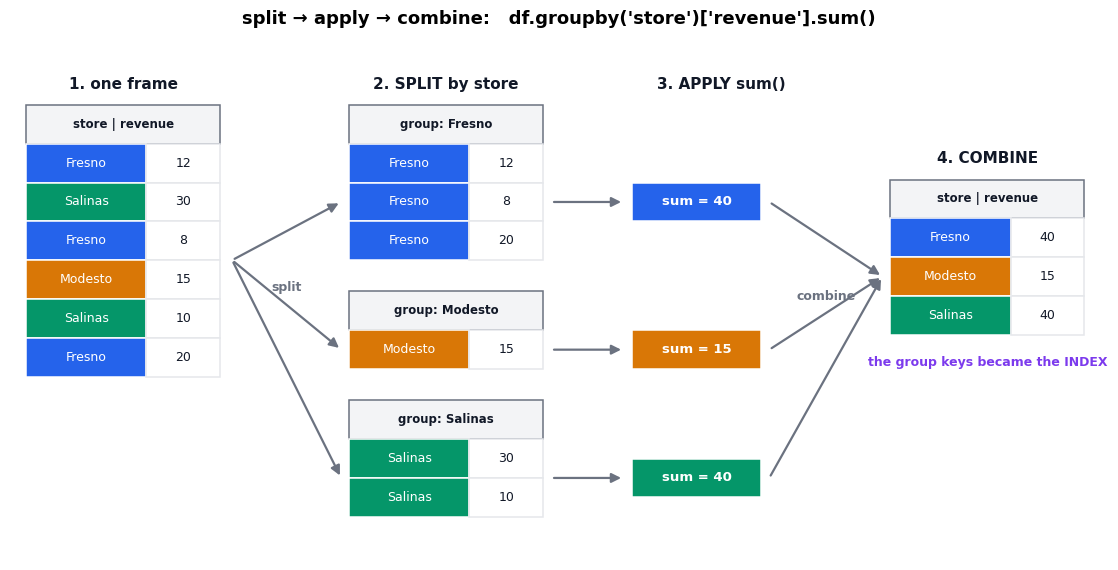

In [ ]:
# ============================================================
#  Split -> apply -> combine, on a frame small enough to hold
#  in your head: 6 rows, 3 groups, one aggregation.
# ============================================================
from matplotlib.patches import FancyArrowPatch, Rectangle

toy = [("Fresno", 12), ("Salinas", 30), ("Fresno", 8),
       ("Modesto", 15), ("Salinas", 10), ("Fresno", 20)]
GC = {"Fresno": C_DATA, "Salinas": C_GROUP, "Modesto": C_WARN}
ORDER = ["Fresno", "Modesto", "Salinas"]        # groupby sorts the keys

RH, RW = 0.52, 2.4                              # row height, table width


def cell(ax, x, y, w, h, text, fc="white", ec=C_SOFT, tc="#111827",
         weight="normal", size=9):
    ax.add_patch(Rectangle((x, y), w, h, facecolor=fc, edgecolor=ec, lw=1.1))
    ax.text(x + w / 2, y + h / 2, text, ha="center", va="center",
            fontsize=size, color=tc, fontweight=weight)


def table(ax, x, ytop, rows, header):
    """Draw a little store|revenue table; return its bottom edge."""
    cell(ax, x, ytop - RH, RW, RH, header, fc="#F3F4F6", ec=C_GREY,
         weight="bold", size=8.5)
    y = ytop - RH
    for s, v in rows:
        y -= RH
        cell(ax, x, y, RW * 0.62, RH, s, fc=GC[s], ec="white", tc="white")
        cell(ax, x + RW * 0.62, y, RW * 0.38, RH, f"{v}")
    return y


def arrow(ax, x0, y0, x1, y1, label="", color=C_GREY):
    ax.add_patch(FancyArrowPatch((x0, y0), (x1, y1), arrowstyle="-|>",
                                 mutation_scale=14, color=color, lw=1.6))
    if label:
        ax.text((x0 + x1) / 2, (y0 + y1) / 2 + 0.14, label, ha="center",
                va="bottom", fontsize=9, color=color, fontweight="bold")


fig, ax = plt.subplots(figsize=(11.5, 5.8))
ax.set_xlim(0, 13.6); ax.set_ylim(0, 7.0); ax.axis("off"); ax.grid(False)
TOP = 6.1


def head(x, t):
    ax.text(x + RW / 2, TOP + 0.22, t, ha="center", fontsize=11,
            fontweight="bold", color="#111827")


# 1 -- the whole frame
bottom = table(ax, 0.2, TOP, toy, "store | revenue")
head(0.2, "1. one frame")
mid1 = (TOP - RH + bottom) / 2

# 2 -- SPLIT: one sub-frame per distinct store
head(4.2, "2. SPLIT by store")
y, mids = TOP, {}
for name in ORDER:
    rows = [r for r in toy if r[0] == name]
    bot = table(ax, 4.2, y, rows, f"group: {name}")
    mids[name] = (y - RH + bot) / 2
    y = bot - 0.42
for i, name in enumerate(ORDER):
    arrow(ax, 2.75, mid1, 4.1, mids[name], "split" if i == 1 else "")

# 3 -- APPLY: sum() runs on each sub-frame independently
head(7.6, "3. APPLY sum()")
sums = {}
for name in ORDER:
    sums[name] = sum(v for s, v in toy if s == name)
    cell(ax, 7.7, mids[name] - RH / 2, 1.6, RH, f"sum = {sums[name]}",
         fc=GC[name], ec="white", tc="white", weight="bold", size=9.5)
    arrow(ax, 6.7, mids[name], 7.6, mids[name])

# 4 -- COMBINE: the three answers stack into one object
res = [(n, sums[n]) for n in ORDER]
b4 = table(ax, 10.9, TOP - 1.0, res, "store | revenue")
ax.text(10.9 + RW / 2, TOP - 0.78, "4. COMBINE", ha="center", fontsize=11,
        fontweight="bold", color="#111827")
mid4 = (TOP - 1.0 - RH + b4) / 2
for name in ORDER:
    arrow(ax, 9.4, mids[name], 10.8, mid4, "combine" if name == "Modesto" else "")
ax.text(10.9 + RW / 2, b4 - 0.42, "the group keys became the INDEX",
        ha="center", fontsize=9, color=C_IDX, fontweight="bold")

ax.set_title("split → apply → combine:   "
             "df.groupby('store')['revenue'].sum()",
             fontsize=13, fontweight="bold", pad=10)
plt.tight_layout(); plt.show()


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

The whole of `groupby` in one picture. On the left, six rows. pandas cuts them into three sub-frames — one per distinct `store` — without moving any data; it just records which row belongs where. `sum()` then runs three separate times, once per sub-frame, on the `revenue` column only. The three answers stack into a single object whose **index is the group keys**, sorted, not the original row numbers 0–5. Fresno's 12, 8 and 20 became one 40.

Note what the picture does *not* show: a loop. You never write step 2 as a `for` over groups, and you never write step 3 at all.

**The common misread:** thinking the split makes copies and therefore costs memory proportional to the data. It does not — the split is bookkeeping, a map from group key to row positions, and it is why `groupby` on a million rows is cheap. The middle column of this picture is a teaching fiction; pandas never materialises those three tables unless you ask it to.

</div>

### A GroupBy is a plan, not a result

`tidy.groupby("store")` does not compute anything. It hands you a **GroupBy object** — a lazy description of the split, holding a mapping from each key to the row labels that belong to it. Nothing is aggregated until you call a method on it.

That is worth seeing directly, because it explains a class of confusing errors: if you print a GroupBy expecting a table you get an object repr, and if you mistype a column name the error arrives at the aggregation rather than at the `groupby`.

Three things you can do with the object itself, all useful when debugging a grouped result that looks wrong:

- `.ngroups` and `.groups` — how many groups, and which row labels are in each.
- `.get_group(key)` — pull one group out as an ordinary DataFrame.
- iterate it — `for name, sub in g:` gives you `(key, sub-frame)` pairs. Useful for inspection; almost never the right way to compute an answer.


In [ ]:
g = tidy.groupby("store")

print(type(g).__name__)
print(g)                                   # a plan, not a table
print(f"\nngroups: {g.ngroups}   keys: {list(g.groups)}")

# .groups maps each key -> the row LABELS in that group (not positions)
fresno_labels = g.groups["Fresno"]
print(f"\nFresno has {len(fresno_labels)} rows; first five labels: "
      f"{list(fresno_labels[:5])}")

# .get_group pulls one group out as a normal DataFrame
print(f"\nget_group('Fresno') -> {type(g.get_group('Fresno')).__name__} "
      f"of shape {g.get_group('Fresno').shape}")

# iterating gives (key, sub-frame) pairs -- good for looking, bad for computing
print("\niterating the GroupBy:")
for name, sub in g:
    print(f"   {name:<12} {sub.shape[0]:>4} rows   "
          f"revenue sum {sub['revenue'].sum():>10,.2f}")


DataFrameGroupBy

ngroups: 5   keys: ['Bakersfield', 'Fresno', 'Modesto', 'Salinas', 'Stockton']

Fresno has 188 rows; first five labels: [1, 7, 29, 32, 36]

get_group('Fresno') -> DataFrame of shape (188, 23)

iterating the GroupBy:
   Bakersfield   186 rows   revenue sum   5,069.00
   Fresno        188 rows   revenue sum   5,192.25
   Modesto       159 rows   revenue sum   4,551.00
   Salinas       186 rows   revenue sum   5,398.25
   Stockton      175 rows   revenue sum   4,656.75


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

`print(g)` gives you an object repr and a memory address, not a table — that is the point: no arithmetic has happened yet. `ngroups` and `groups` show the bookkeeping the split produced: five keys, each mapped to the row *labels* (index values) that belong to it, which is why the first five Fresno labels are scattered integers rather than 0, 1, 2, 3, 4. `get_group` materialises one group on demand, and iterating walks every group in key order with its own sub-frame.

**The common misread:** treating the loop at the bottom as the normal way to use `groupby`. It produces the same numbers as `g['revenue'].sum()` but runs Python once per group instead of one vectorised pass, and it will not hand you a DataFrame at the end. Iterate to *look* at groups; aggregate to *compute* with them.

</div>

### The aggregations you will use every day

Once you have the object, an aggregation is a method call. Four shapes cover most work:

| You write | You get back |
|---|---|
| `df.groupby(key)[col].sum()` | a **Series**, indexed by the key |
| `df.groupby(key)[[c1, c2]].mean()` | a **DataFrame**, indexed by the key |
| `df.groupby([k1, k2])[col].sum()` | a Series with a **MultiIndex** of both keys |
| `df.groupby(key).size()` | a Series of **row counts** per group |

The one pair that trips everybody is `.size()` and `.count()`. They are not the same function with different names: **`.size()` counts rows; `.count()` counts non-missing values, per column.** On a frame with no missing data they agree, which is exactly why the difference stays hidden until it matters.


In [ ]:
# --- one key -------------------------------------------------------------
by_store = tidy.groupby("store")["revenue"].sum()
print("one key, one column -> Series")
print(by_store, "\n")

# --- two keys ------------------------------------------------------------
by_two = tidy.groupby(["region", "category"])["revenue"].sum()
print("two keys -> Series with a MultiIndex")
print(by_two, "\n")

# --- size vs count vs mean, on the SAME column, side by side -------------
print("size vs count vs mean on 'rating':")
print(tidy.groupby("store").agg(size=("rating", "size"),
                                count=("rating", "count"),
                                mean=("rating", "mean")))

print(f"\nrating is missing in {tidy['rating'].isna().sum()} rows "
      f"of {len(tidy)} -- Part 4 kept those NaN on purpose, because a "
      f"customer who declined to rate is not a customer who rated 0.")
print(f"that gap is the whole difference between the first two columns: "
      f"{tidy.groupby('store')['rating'].size().sum()} - "
      f"{tidy.groupby('store')['rating'].count().sum()} = "
      f"{tidy['rating'].isna().sum()}")


one key, one column -> Series
store
Bakersfield    5069.00
Fresno         5192.25
Modesto        4551.00
Salinas        5398.25
Stockton       4656.75
Name: revenue, dtype: float64 

two keys -> Series with a MultiIndex
region      category
Central     drink       5959.50
            food        3603.75
Coast       drink       3679.00
            food        1699.00
North       drink       2759.00
            food        1882.00
South       drink       2606.25
            food        2339.75
Unassigned  drink        133.75
            food         205.25
Name: revenue, dtype: float64 

size vs count vs mean on 'rating':
             size  count      mean
store                             
Bakersfield   186    179  4.014525
Fresno        188    172  4.022674
Modesto       159    153  4.054902
Salinas       186    171  4.030409
Stockton      175    158  4.089241

rating is missing in 61 rows of 894 -- Part 4 kept those NaN on purpose, because a customer who declined to rate is not a cust

/tmp/ipykernel_11031/438475291.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  by_two = tidy.groupby(["region", "category"])["revenue"].sum()


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Three results from one frame. The single-key sum is a Series indexed by store; the two-key sum is a Series whose index is a *pair* of labels, which is a MultiIndex and is the thing Part 7 will teach you to flatten. The third table is the important one: `size` and `count` disagree for every store, and they disagree by exactly the number of rows where `rating` is missing. `mean` is computed over the `count` rows, not the `size` rows.

**The common misread:** reading the `mean` column as "the average rating this store gets". It is the average over the customers who *answered*. Everyone who declined to rate is absent from both the numerator and the denominator, so the number answers "how do people who bother to rate feel about this store" — a question with a well-known selection bias in it, and not the one you asked.

</div>

<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ The trap

**`.count()` is not a row count.** Reach for it to ask "how many orders per store?" and you get "how many orders per store had a non-null value in this column" — a different number, per column, and smaller than you expect wherever the data is incomplete. Use `.size()` for rows. Use `.count()` only when you actually mean *how much data do I have here*, which is a genuinely useful question to ask **before** you trust a mean.

The same silence is in `mean()`, `sum()`, `median()` and friends: they all default to `skipna=True`. Nothing warns you. A store where only a third of customers left a rating will report a perfectly reasonable-looking average, computed from a third of the data, sitting in the same column as a store where everybody answered. Pair every aggregate with a `count` — the named-aggregation form below makes that a one-line habit — and you will catch it.

</div>

### Where did those rows go?

Now a subtler one, and the reason this section comes before anything clever.

Part 4 decided — correctly — that a customer who declined to rate is not a customer who rated zero, so those ratings stayed `NaN`. Part 5 binned `rating` into `rating_band` with `pd.cut`, and a `NaN` rating cannot land in a band, so it stayed `NaN` there too.

Now ask a completely reasonable question: **how much revenue comes from each rating band?** Group by `rating_band` and the unrated orders do not go into a "missing" bucket. **They are dropped.** No warning, no error, no row in the output. The result looks completely normal.

Watch the money disappear.


In [ ]:
# --- the failure, first --------------------------------------------------
per_band = tidy.groupby("rating_band")["revenue"].sum()
print(per_band, "\n")

n_rows  = len(tidy)
n_group = tidy.groupby("rating_band").size().sum()
print(f"rows in the frame  : {n_rows:>8,}")
print(f"rows in the groups : {n_group:>8,}")
print(f"silently dropped   : {n_rows - n_group:>8,}   "
      f"(rows with a missing rating_band: {tidy['rating_band'].isna().sum()})")

total_all     = tidy["revenue"].sum()
total_grouped = per_band.sum()
print(f"\nrevenue over the whole frame : {total_all:>12,.2f}")
print(f"revenue summed over groups   : {total_grouped:>12,.2f}")
print(f"unaccounted for              : {total_all - total_grouped:>12,.2f}"
      f"   ({(total_all - total_grouped) / total_all:.1%} of the business)")

# --- the fix -------------------------------------------------------------
print("\ndropna=False keeps them, in a group whose key is NaN:")
print(tidy.groupby("rating_band", dropna=False)["revenue"].sum())
print(f"\nand now the totals reconcile: "
      f"{tidy.groupby('rating_band', dropna=False)['revenue'].sum().sum():,.2f}"
      f" == {total_all:,.2f}")


rating_band
poor       796.25
ok       10987.50
good      6397.75
great     4920.00
Name: revenue, dtype: float64 

rows in the frame  :      894
rows in the groups :      833
silently dropped   :       61   (rows with a missing rating_band: 61)

revenue over the whole frame :    24,867.25
revenue summed over groups   :    23,101.50
unaccounted for              :     1,765.75   (7.1% of the business)

dropna=False keeps them, in a group whose key is NaN:
rating_band
poor       796.25
ok       10987.50
good      6397.75
great     4920.00
NaN       1765.75
Name: revenue, dtype: float64

and now the totals reconcile: 24,867.25 == 24,867.25


/tmp/ipykernel_11031/1277281781.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  per_band = tidy.groupby("rating_band")["revenue"].sum()
/tmp/ipykernel_11031/1277281781.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  n_group = tidy.groupby("rating_band").size().sum()
/tmp/ipykernel_11031/1277281781.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(tidy.groupby("rating_band", dropna=False)["revenue"].sum()

<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

The first table is a perfectly plausible revenue-by-rating-band report — the kind of thing that goes in a slide about whether happy customers spend more. It is also missing a chunk of the business, and nothing in it says so. The row counts underneath show the leak: the groups hold fewer rows than the frame does, by exactly the number of rows whose `rating_band` is missing, and the revenue those orders carried is absent from the total. The last table adds them back under a `NaN` key and the totals reconcile.

**The common misread:** assuming the grouped totals add up to the frame's total, and therefore never checking. They add up only when the group key has no missing values. This is the easiest way there is to publish a report that is quietly short of some real revenue — and the check is one line: compare `df[col].sum()` with the sum of the grouped result.

</div>

<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ The trap

**`groupby` drops rows whose key is missing, by default.** `dropna=True` is the default, it applies to the *group key* (not to the values being aggregated), and with multiple keys a row is dropped if *any* of its keys is missing.

This is the most expensive default in pandas, because the failure is invisible: you do not get a `NaN` row you might notice, you get a shorter table that looks fine. Two habits fix it for good:

1. **Group with `dropna=False`** whenever the key might be incomplete. You get a `NaN` group you can see and decide about.
2. **Assert the totals.** `df.groupby(k).size().sum() == len(df)` is a one-line smoke test for every grouped result you are about to send to somebody.

</div>

### `.agg()`, four ways

`.sum()` is fine when you want one thing. `.agg()` is how you ask for several at once, and it accepts four different shapes of argument — worth knowing all four, because you will read all four in other people's code.

1. **A list of functions** — the same functions applied to the selected column.
2. **A dict, column → function** — a different aggregation per column.
3. **Named aggregation**, `name=(column, function)` — the modern form, and the one to reach for. It says what each output column *is*, names it in the same breath, and gives you flat column names instead of a MultiIndex to unpick.
4. **A callable**, including a lambda, for anything pandas has no name for.

Named aggregation is worth the extra characters. Compare the column names that come out of form 1 with the ones that come out of form 3.


In [ ]:
# --- 1. a list of functions ---------------------------------------------
print("1. list of functions:")
print(tidy.groupby("region")["revenue"].agg(["sum", "mean", "count"]), "\n")

# --- 2. a dict: column -> function --------------------------------------
print("2. dict, column -> function:")
print(tidy.groupby("region").agg({"revenue": "sum",
                                  "quantity": "mean",
                                  "rating": "median"}), "\n")

# --- 3. named aggregation -- the readable form ---------------------------
report = tidy.groupby("region").agg(
    orders     = ("order_id", "size"),      # every row, missing values included
    rated      = ("rating",   "count"),     # only the rows a customer rated
    revenue    = ("revenue",  "sum"),
    avg_order  = ("revenue",  "mean"),
    avg_rating = ("rating",   "mean"),      # computed over `rated`, not `orders`
)
print("3. named aggregation:")
print(report, "\n")
print("   columns come out flat:", list(report.columns), "\n")

# --- 4. a custom callable ------------------------------------------------
print("4. a lambda, for something pandas has no name for:")
print(tidy.groupby("region")["revenue"].agg(
    spread  = lambda s: s.max() - s.min(),
    biggest = lambda s: s.idxmax(),          # the row LABEL, not the value
))


1. list of functions:
                sum       mean  count
region                               
Central     9563.25  28.210177    339
Coast       5378.00  29.070270    185
North       4641.00  26.672414    174
South       4946.00  27.175824    182
Unassigned   339.00  24.214286     14 

2. dict, column -> function:
            revenue  quantity  rating
region                               
Central     9563.25  8.103245    4.00
Coast       5378.00  7.978378    4.00
North       4641.00  7.511494    4.10
South       4946.00  7.928571    4.00
Unassigned   339.00  7.428571    4.15 

3. named aggregation:
            orders  rated  revenue  avg_order  avg_rating
region                                                   
Central        339    317  9563.25  28.210177    4.040379
Coast          185    170  5378.00  29.070270    4.032353
North          174    157  4641.00  26.672414    4.083439
South          182    175  4946.00  27.175824    4.017143
Unassigned      14     14   339.00  24.2142

/tmp/ipykernel_11031/1994470378.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(tidy.groupby("region")["revenue"].agg(["sum", "mean", "count"]), "\n")
/tmp/ipykernel_11031/1994470378.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(tidy.groupby("region").agg({"revenue": "sum",
/tmp/ipykernel_11031/1994470378.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  report = tidy.groupby("region").agg(
/tmp/

<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Four routes to the same kind of answer. Form 1 gives you columns literally named `sum`, `mean`, `count` — fine here, but select two columns instead of one and you get a MultiIndex on the *columns* that you then have to flatten. Form 2 lets each column have its own function but gives you no say in the names. Form 3 names every output explicitly, and its `orders` and `rated` columns sit side by side so the gap between them — the customers who did not answer — is visible in the report rather than hidden behind the `avg_rating` two columns along, which was computed over `rated` and not over `orders`. Form 4 shows that an aggregation is just any function that turns a Series into one value: `idxmax` returns the *row label* of the largest order, not its size.

**The common misread:** reading `('revenue', 'sum')` inside named aggregation as a tuple of data. It is a tuple of *instructions* — which column, which function — and the name on the left of the `=` is what the output column will be called. Read it as "`revenue` is the sum of the revenue column".

</div>

### `agg` vs `transform` vs `apply` — the distinction people get wrong

These three all "apply a function to each group", and they are not "the same thing at different speeds". They differ in **the shape of what comes back**, and that is the only thing you need to remember:

| | what the function returns | what you get back | length |
|---|---|---|---|
| **`.agg()`** | one value per group | one row per group | `ngroups` |
| **`.transform()`** | one value per group, *broadcast back* | aligned to the input | `len(df)` |
| **`.apply()`** | anything at all | whichever shape it inferred | it depends |

`agg` **reduces**. `transform` **broadcasts** — it computes the per-group answer and then hands each original row its own group's answer, so the result lines up with the frame and can be assigned straight into a new column. `apply` will do either, guesses which from what your function returned, and is the slowest because it runs Python once per group.

Ask all three the same question — *what is the total revenue of this row's store?* — and print the shapes next to each other.


In [ ]:
import time

# --- the SAME question, three ways --------------------------------------
a_agg       = tidy.groupby("store")["revenue"].sum()                     # reduce
a_transform = tidy.groupby("store")["revenue"].transform("sum")          # broadcast
a_apply     = tidy.groupby("store")["revenue"].apply(lambda s: s.sum())  # reduce
a_apply2    = tidy.groupby("store")["revenue"].apply(lambda s: s / s.sum())

print(f"input frame                       {tidy.shape}")
print(f"agg        .sum()                 {a_agg.shape}   <- one row per group")
print(f"apply      lambda s: s.sum()      {a_apply.shape}   <- same: it reduced")
print(f"transform  'sum'                  {a_transform.shape} <- one row per INPUT row")
print(f"apply      lambda s: s / s.sum()  {a_apply2.shape} <- apply broadcast instead")
print(f"\nnumber of groups: {tidy.groupby('store').ngroups}   "
      f"rows in the frame: {len(tidy)}")

# --- and the same numbers, seen from a row's point of view ---------------
print("\ntransform gives every row its own group's total:")
print(pd.DataFrame({"store": tidy["store"],
                    "revenue": tidy["revenue"],
                    "store_total": a_transform}).head(6))

# --- speed ---------------------------------------------------------------
def ms(f, n=25):
    t0 = time.perf_counter()
    for _ in range(n):
        f()
    return (time.perf_counter() - t0) / n * 1000

# the cost of apply is per GROUP, so it grows with the number of groups:
# time both on two keys (30 groups) rather than one (5).
keys  = ["store", "product"]
t_sum = ms(lambda: tidy.groupby(keys)["revenue"].sum())
t_app = ms(lambda: tidy.groupby(keys)["revenue"].apply(lambda s: s.sum()))
print(f"\nover {tidy.groupby(keys).ngroups} groups:")
print(f"   .sum()                     {t_sum:6.2f} ms")
print(f"   .apply(lambda s: s.sum())  {t_app:6.2f} ms   "
      f"({t_app / t_sum:.1f}x slower, for identical arithmetic)")


input frame                       (894, 23)
agg        .sum()                 (5,)   <- one row per group
apply      lambda s: s.sum()      (5,)   <- same: it reduced
transform  'sum'                  (894,) <- one row per INPUT row
apply      lambda s: s / s.sum()  (894,) <- apply broadcast instead

number of groups: 5   rows in the frame: 894

transform gives every row its own group's total:
      store  revenue  store_total
0  Stockton    25.50      4656.75
1    Fresno    29.25      5192.25
2  Stockton    31.50      4656.75
3  Stockton    23.75      4656.75
4  Stockton    24.75      4656.75
5  Stockton    22.00      4656.75

over 30 groups:
   .sum()                       0.99 ms
   .apply(lambda s: s.sum())    2.47 ms   (2.5x slower, for identical arithmetic)


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

The shapes are the whole lesson. `agg` and the reducing `apply` both collapse to one row per group. `transform` comes back the same length as the input frame — and so does `apply` when the function happened to return a Series, which is the point: **`apply` inferred its output shape from your lambda**, while `agg` and `transform` each guarantee one. The little table underneath shows what "broadcast" means concretely: rows from the same store all carry the same `store_total`, so the column lines up with the frame and can be assigned into it. The timings show `apply` doing identical arithmetic slower, because it runs your Python function once per group instead of one compiled pass — which is also why the gap is measured over thirty groups rather than five: the overhead is per group, so it grows with the number of them.

**The common misread:** picking between them by what you want to *compute*. The computation is the same in all four lines above. Pick by the shape you want back: one row per group, or one row per row.

</div>

<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ The trap

**`apply` will quietly change shape on you.** Because it infers the result from whatever your function returned, an edit that looks cosmetic — returning `s.sum()` rather than `s / s.sum()`, or a one-row frame rather than a scalar — changes the length of the output and the structure of its index. Code downstream that assumed one row per group now gets one row per order, and the failure surfaces far from the cause.

Use the specific verb and the shape becomes a promise instead of an inference: `agg` when you want one row per group, `transform` when you want the input's shape back. Keep `apply` for the genuine cases where the per-group operation is not an aggregation at all — ranking within a group, taking the top three rows of each — and accept that it is slower.

One more edge, in `transform`'s favour: it *cannot* change the number of rows. Hand it a function that returns the wrong length and you get an error rather than a surprise, which is exactly why it is the safer tool.

</div>

### `transform` earning its keep, and the index that comes back

Two things at once here, because they show up together.

**`transform` is how you compare a row to its group.** Any question of the form *how does this order compare to its store's typical order* needs the group's answer attached to every row, which is exactly what `transform` returns. Two of them below: each order's share of its store's total revenue, and each rating centred on its store's mean — a centred rating of `+0.4` means "four tenths above what this store usually gets", which is a more honest number than the raw rating when stores differ.

**Grouped results come back indexed by the keys.** That is the "combine" step doing its job, and it is why `by_store["Fresno"]` works. Three ways to get an ordinary column back instead:

- `as_index=False` — ask for it up front, get a flat DataFrame.
- `.reset_index()` — push the index into columns afterwards.
- `.unstack()` — for a two-key result, move the *inner* key up into the columns, turning a long Series into a wide table. That is the pivot Part 7 will formalise.

And one question about that index that Part 5 left hanging: **what order do the keys come back in?** Sorted, by default — which for the weekday names Part 5 built is alphabetical, and alphabetical weekdays are unreadable. Part 5 patched the chart with `.reindex(DAY_ORDER)`; the cell below shows the fix that does not need patching every time.
<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🧭 Which one

`as_index=False` when the grouped result is going straight into more DataFrame work. `.reset_index()` when you already have the result and want it flat. `.unstack()` when you have two keys and want a matrix — one key down the side, the other across the top — which is almost always the right shape for a chart.

</div>

In [ ]:
# ---- transform: compare each row to its own group -----------------------
cmp = tidy[["store", "product", "revenue", "rating"]].copy()
cmp["store_total"] = tidy.groupby("store")["revenue"].transform("sum")
cmp["share_of_store"] = cmp["revenue"] / cmp["store_total"]
cmp["rating_vs_store"] = (tidy["rating"]
                          - tidy.groupby("store")["rating"].transform("mean"))

print("each row against its own store:")
print(cmp[["store", "revenue", "store_total",
           "share_of_store", "rating_vs_store"]].head(6), "\n")
one = cmp["store"] == "Fresno"
print(f"shares within one store sum to 1     : "
      f"{cmp.loc[one, 'share_of_store'].sum():.6f}")
print(f"centred ratings within one store to 0: "
      f"{cmp.loc[one, 'rating_vs_store'].sum():.6f}\n")

# ---- the index that comes back ------------------------------------------
print("default -- group keys become the index:")
print(tidy.groupby("region")["revenue"].sum(), "\n")

print("as_index=False -- a flat DataFrame instead:")
print(tidy.groupby("region", as_index=False)["revenue"].sum(), "\n")

print("reset_index() -- same thing, after the fact:")
print(tidy.groupby("region")["revenue"].sum().reset_index(), "\n")

# ---- what ORDER do the keys come back in? -------------------------------
DAY_ORDER = ["Monday", "Tuesday", "Wednesday", "Thursday",
             "Friday", "Saturday", "Sunday"]

# groupby SORTS its keys by default, and day_name is a string, so:
print("default (sort=True) -- alphabetical, which is useless for weekdays:")
print(list(tidy.groupby("day_name")["revenue"].sum().index), "\n")

print("sort=False -- order of first appearance in the frame, also not calendar:")
print(list(tidy.groupby("day_name", sort=False)["revenue"].sum().index), "\n")

# the real fix: make the key an ORDERED categorical and the order is a
# property of the column, so every groupby on it comes out right for free
day = pd.Categorical(tidy["day_name"], categories=DAY_ORDER, ordered=True)
print("ordered categorical key -- calendar order, no reindex needed:")
print(tidy.groupby(day, observed=True)["revenue"].sum(), "\n")

# ---- two keys -> unstack -> sort ----------------------------------------
long = tidy.groupby(["region", "category"])["revenue"].sum()
wide = long.unstack()
print("two keys, unstacked into a matrix, sorted by drink revenue:")
print(wide.sort_values("drink", ascending=False))
print(f"\nlong result: {long.shape}   ->   wide result: {wide.shape}")


each row against its own store:
      store  revenue  store_total  share_of_store  rating_vs_store
0  Stockton    25.50      4656.75        0.005476         0.110759
1    Fresno    29.25      5192.25        0.005633         0.977326
2  Stockton    31.50      4656.75        0.006764         0.010759
3  Stockton    23.75      4656.75        0.005100        -1.489241
4  Stockton    24.75      4656.75        0.005315         0.210759
5  Stockton    22.00      4656.75        0.004724         0.210759 

shares within one store sum to 1     : 1.000000
centred ratings within one store to 0: 0.000000

default -- group keys become the index:
region
Central       9563.25
Coast         5378.00
North         4641.00
South         4946.00
Unassigned     339.00
Name: revenue, dtype: float64 

as_index=False -- a flat DataFrame instead:
       region  revenue
0     Central  9563.25
1       Coast  5378.00
2       North  4641.00
3       South  4946.00
4  Unassigned   339.00 

reset_index() -- same thing

/tmp/ipykernel_11031/3856402021.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(tidy.groupby("region")["revenue"].sum(), "\n")
/tmp/ipykernel_11031/3856402021.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(tidy.groupby("region", as_index=False)["revenue"].sum(), "\n")
/tmp/ipykernel_11031/3856402021.py:25: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(tidy.groupby("region")["revenue"].sum().r

two keys, unstacked into a matrix, sorted by drink revenue:
category      drink     food
region                      
Central     5959.50  3603.75
Coast       3679.00  1699.00
North       2759.00  1882.00
South       2606.25  2339.75
Unassigned   133.75   205.25

long result: (10,)   ->   wide result: (5, 2)


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

The first table is the `transform` payoff: `store_total` repeats down the rows of each store, `share_of_store` divides each order by it, and the two checks confirm the arithmetic — one store's shares sum to 1, its centred ratings sum to about 0. Neither column could have been built with `agg`, because both need the group's answer *attached to every row*.

Underneath, the same revenue-by-region numbers in three layouts: with the key as the index, with `as_index=False`, and after `reset_index()`.

Then the ordering block, which is where Part 5's weekday chart came from. `groupby` **sorts its keys** by default, and `day_name` holds strings, so the days come back alphabetically — Friday, Monday, Saturday — which is correct and unreadable. `sort=False` gives you order of first appearance instead, which is no better. The fix that actually works is to make the key an **ordered categorical**: the order stops being something you patch up after each aggregation and becomes a property of the column, so every groupby on it comes out in calendar order for free. Part 5 reached for `.reindex(DAY_ORDER)` to fix one chart; this fixes all of them.

The last block takes the two-key result — a long Series with a MultiIndex — and `unstack()` moves `category` from the index up into the columns, turning a stack of numbers into a matrix. Same data, same total, different shape.

**The common misread:** thinking `unstack()` aggregates something. It does not compute at all — it only moves an index level into the columns. The aggregation already happened, in the `.sum()` before it.

</div>

### `observed=` — the one that only bites on categorical keys

Part 4 converted `region` and `category` to the `category` dtype — a real memory win, and it makes grouping faster. Part 5 added two more without announcing it: `pd.cut` and `pd.qcut` both return categoricals, so `rating_band` and `rev_quartile` are categorical too. (`store` and `product` are still plain strings; Part 4 deliberately left them that way so Part 5 could repair their spelling, and a categorical will not let you assign a value that is not already one of its categories.)

Categorical keys introduce a trap that does not exist for plain strings. A categorical column carries its **full list of categories** independently of the values actually present, and filtering rows never removes a category. Cut the frame down to one region and the other four are still declared — the filtered frame simply has zero rows for them. So: should `groupby` report the empty groups, or only the ones that occur?

`observed=` decides. Rather than trust anybody's memory of which way the default goes — it **changed** between pandas 2 and pandas 3 — the cell below reads the default off the function signature at runtime.


In [ ]:
import inspect

default = inspect.signature(pd.DataFrame.groupby).parameters["observed"].default
print(f"pandas {pd.__version__}: groupby(observed=...) defaults to {default}\n")

coast = tidy[tidy["region"] == "Coast"]
print(f"after filtering to one region: {len(coast)} rows, but "
      f"{len(coast['region'].cat.categories)} regions are still DECLARED:")
print(f"   {list(coast['region'].cat.categories)}\n")

print("observed=True  -- only the groups that actually occur:")
print(coast.groupby("region", observed=True).size(), "\n")

print("observed=False -- every declared category, present or not:")
print(coast.groupby("region", observed=False).size(), "\n")

# and with two categorical keys, observed=False is a full CROSS PRODUCT
n_true  = coast.groupby(["region", "category"], observed=True).size().shape[0]
n_false = coast.groupby(["region", "category"], observed=False).size().shape[0]
n_reg   = len(coast["region"].cat.categories)
n_cat   = len(coast["category"].cat.categories)
print("two categorical keys on that same filtered frame:")
print(f"   observed=True  -> {n_true} rows   (the combinations that occur)")
print(f"   observed=False -> {n_false} rows   "
      f"(= {n_reg} regions x {n_cat} categories = {n_reg * n_cat})")


pandas 2.2.3: groupby(observed=...) defaults to _NoDefault.no_default

after filtering to one region: 185 rows, but 5 regions are still DECLARED:
   ['Central', 'Coast', 'North', 'South', 'Unassigned']

observed=True  -- only the groups that actually occur:
region
Coast    185
dtype: int64 

observed=False -- every declared category, present or not:
region
Central         0
Coast         185
North           0
South           0
Unassigned      0
dtype: int64 

two categorical keys on that same filtered frame:
   observed=True  -> 2 rows   (the combinations that occur)
   observed=False -> 10 rows   (= 5 regions x 2 categories = 10)


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

The filter left rows from one region only, but the `region` column still declares all five as categories — filtering rows never removes categories. `observed=True` reports only the region that actually appears; `observed=False` reports all five, with zeros for the four the filter removed. The line at the top is the authority on which of those you get by default, read from the installed pandas rather than from anyone's memory.

The two-key counts at the bottom are the same effect multiplied: `observed=False` returns every region crossed with every category whether or not the pair occurs, so the row count is a property of the *dtype* rather than of the data. Before the filter, every combination existed and the two numbers would have agreed — which is exactly why this trap stays hidden until the day you filter first and the shape of your result changes without your code changing.

**The common misread:** reading a `0` in an `observed=False` result as "this region sold nothing". It means "no rows here", which is a different claim: the rows may have been filtered away, or the category may be a leftover from a frame this one was sliced out of. A zero from `observed=False` is a statement about your *categories*, not about your business.

</div>

<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ The trap

**`observed=False` builds the full cross product of every declared category.** With plain string keys, `groupby` can only ever produce groups that exist in the data. With categorical keys and `observed=False`, three keys of 50, 200 and 30 categories produce 300,000 rows of mostly zeros, whether or not the frame has that many rows. That is how a `groupby` on a small frame runs out of memory.

The default is `True` in pandas 3 — the cell above read it off the signature — and it was `False` in pandas 2, with a `FutureWarning`. So **older code and older tutorials silently mean the other thing.** If you are porting a pandas-2 notebook and a grouped result suddenly has fewer rows, this is why; the fix is to pass `observed=` explicitly rather than rely on either default.

</div>

---

### The manager's question

> *Which product sells best on weekends, by region — ignoring the days the till was double-scanned?*

Everything it needs now exists. The double-scanned rows went in Part 4 with `drop_duplicates`. `is_weekend` came from the real datetime in Part 5. `revenue` is `quantity × unit_price`. So the question becomes one method chain, and it reads more or less like the sentence:

- filter to weekends,
- group by region **and** product,
- sum revenue,
- keep the best product in each region.

`dropna=False` is in there deliberately, even though neither key has a missing value today: Part 4 turned the unassigned regions into an explicit `"Unassigned"` category precisely so they would survive a `groupby` as a visible row rather than vanish. That decision is doing its work here — `Unassigned` appears in the answer as a real region, which is what the manager asked for. The `dropna=False` is insurance for the day somebody upstream stops being that careful.


In [ ]:
weekend_by_product = (
    tidy[tidy["is_weekend"]]                                 # weekends only
        .groupby(["region", "product"], dropna=False)        # split on both keys
        ["revenue"].sum()                                    # apply
        .sort_values(ascending=False)                        # best first
)

best_per_region = (weekend_by_product
                   .groupby("region", dropna=False)          # within each region...
                   .head(1)                                  # ...keep the top row
                   .sort_index())

print("weekend revenue -- the best product in each region:\n")
print(best_per_region.to_frame("weekend_revenue"), "\n")

for (region, product), rev in best_per_region.items():
    total = weekend_by_product.loc[region].sum()
    print(f"   {str(region):<11} -> {product:<10} {rev:>9,.2f}   "
          f"({rev / total:.1%} of that region's weekend revenue)")


weekend revenue -- the best product in each region:

                      weekend_revenue
region     product                   
Central    cold brew           837.25
Coast      latte               470.25
North      latte               726.75
South      muffin              374.50
Unassigned latte                61.75 

   Central     -> cold brew     837.25   (23.2% of that region's weekend revenue)
   Coast       -> latte         470.25   (31.0% of that region's weekend revenue)
   North       -> latte         726.75   (40.7% of that region's weekend revenue)
   South       -> muffin        374.50   (23.9% of that region's weekend revenue)
   Unassigned  -> latte          61.75   (55.3% of that region's weekend revenue)


/tmp/ipykernel_11031/1901473864.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["region", "product"], dropna=False)        # split on both keys
/tmp/ipykernel_11031/1901473864.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("region", dropna=False)          # within each region...


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

The answer, one row per region: the product with the highest weekend revenue there, and what fraction of that region's weekend takings it accounts for. The winner is not the same product everywhere, which is the finding — a single national answer would have been an average over genuinely different regions. `Unassigned` is in there as a region of its own — those are the new-store rows from Part 0, kept visible by Part 4's decision to name the gap rather than leave it `NaN`, and they are a real slice of weekend revenue.

**The common misread:** reading the winner as "the most *popular* product". This ranks by revenue, and lattes cost roughly twice what cookies do, so a product can win on money while losing on units. Swap `revenue` for `quantity` in the chain and you may get a different champion — which is a question about what the manager meant, not about pandas.

</div>

/tmp/ipykernel_11031/250198065.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["region", "product"])["revenue"].sum()


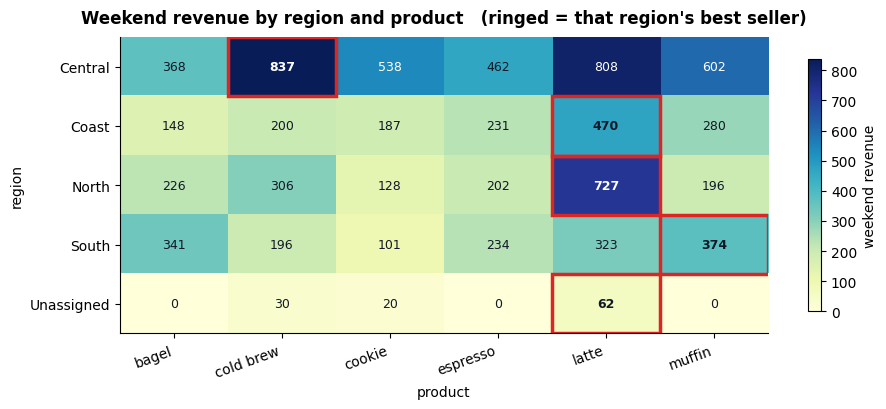

In [ ]:
# ============================================================
#  The two-key result as a matrix: weekend revenue by
#  region x product, with each region's winner ringed.
# ============================================================
mat = (tidy[tidy["is_weekend"]]
       .groupby(["region", "product"])["revenue"].sum()
       .unstack()                                  # regions down, products across
       .fillna(0))

fig, ax = plt.subplots(figsize=(9.5, 4.2))
im = ax.imshow(mat.values, cmap="YlGnBu", aspect="auto")

ax.set_xticks(range(mat.shape[1]), mat.columns.astype(str), rotation=20, ha="right")
ax.set_yticks(range(mat.shape[0]), mat.index.astype(str))
ax.set_xlabel("product"); ax.set_ylabel("region")
ax.set_title("Weekend revenue by region and product   "
             "(ringed = that region's best seller)",
             fontsize=12, fontweight="bold", pad=10)
ax.grid(False)

hi = mat.values.max()
for i in range(mat.shape[0]):
    winner = int(mat.values[i].argmax())
    for j in range(mat.shape[1]):
        v = mat.values[i, j]
        ax.text(j, i, f"{v:,.0f}", ha="center", va="center", fontsize=9,
                color="white" if v > 0.6 * hi else "#111827",
                fontweight="bold" if j == winner else "normal")
    ax.add_patch(plt.Rectangle((winner - 0.5, i - 0.5), 1, 1, fill=False,
                               edgecolor=C_NA, lw=2.5))

fig.colorbar(im, ax=ax, label="weekend revenue", shrink=0.85)
plt.tight_layout(); plt.show()


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

The same two-key groupby as the answer above, `unstack()`ed into a matrix and drawn. Regions down the side, products across the top; colour and the printed number both show weekend revenue, and the red ring marks each row's largest cell — so the ringed squares are the answer table in picture form. Reading across a row tells you a region's product mix; reading down a column tells you where a product does well.

**The common misread:** comparing colours *between rows* as if they measured the same thing. The colour scale is shared across the whole matrix, so a big region looks uniformly hot and a small one uniformly cool, and the ringed winner in a cool row can be a smaller number than a losing cell in a hot one. To compare product *mix* across regions rather than raw size, divide each row by its own total first — which, now that you have met it, is a `transform`.

</div>

---

### What you can do now

- **Say what `groupby` does** — split into sub-frames by key, apply a function to each, combine the answers back, with the keys becoming the index.
- **See that a GroupBy is lazy** — a plan you can inspect with `.groups` and `.get_group()`, not a computed table.
- **Aggregate properly** — `.agg()` with a list, a dict, a lambda, or named aggregation, which is the one to default to.
- **Choose between `agg`, `transform` and `apply` by the shape you want back** — one row per group, one row per input row, or whatever `apply` infers.
- **Control the shape and order of the result** — `as_index=False`, `.reset_index()`, `.unstack()`, and an ordered categorical key when sorted-alphabetically is the wrong order.
- **Distrust the defaults that hide rows** — `dropna=True` deleting missing keys, `.count()` not counting rows, `mean()` skipping nulls, `observed=` behaving differently on pandas 2 and 3.
- **Answer a real two-key question** and check that the totals still add up.

### Where this goes next

Look back at `unstack()` in this part. A two-key grouped Series went in, a rectangle came out — regions down the side, products across the top — and it turned out to be exactly the shape the chart wanted. That was a **reshape**, and we did it with one method almost by accident.

Part 7 does it deliberately. `pivot` and `pivot_table` to go long → wide, `melt` to go back the other way, and then `merge` and `concat` for the other half of the problem: what to do when the answer needs **two tables**. Our frame has no store metadata in it — opening dates, floor area, manager — and the moment somebody asks whether the newer stores sell differently, you need a join.

---


---

# 7️⃣ Reshaping: long vs wide, and joining

<div style="background: linear-gradient(135deg, #11998e 0%, #38ef7d 100%); padding: 28px; border-radius: 18px; color: white; margin: 12px 0;">


### Every reshaping question is one of two questions.

**"Can I see this as a grid?"** — you have one row per sale and you want stores down the side, months across the top, revenue in the middle. Nothing is computed that you did not already have; the numbers are just *rearranged*. That is `pivot_table` one way and `melt` the other.

**"Can I attach what I know about the key?"** — you have hundreds of transactions keyed by store, and a separate five-row table saying who manages each store. You want the manager's name on every sale. That is `merge`, and it is where pandas will quietly ruin your analysis if you are careless: rows can vanish, or multiply, without a word.

Both are *shape* operations. Neither invents information. Getting them wrong is the most common way a perfectly working analysis produces a wrong number.


</div>

## 🎯 By the end of this part

| You will be able to | Using |
|---|---|
| Turn long data into a grid | `pivot_table(index=, columns=, values=, aggfunc=)` |
| Add row and column totals | `margins=True` |
| Say why `pivot` blew up where `pivot_table` did not | duplicate index/column pairs |
| Turn a grid back into long data | `melt(id_vars=, value_vars=)` |
| Move a level between index and columns | `stack` / `unstack(level=)` |
| Slice a two-level index safely | `.loc[(a, b)]`, `.xs()`, `sort_index()` |
| Attach a lookup table and *know* what you kept | `merge(how=, indicator=True)` |
| Glue frames without silently aligning them | `pd.concat(axis=, ignore_index=, keys=)` |

## 📐 Tidy data, in one paragraph

**Long (tidy) form:** one row per observation, one column per variable. Part 5's
`tidy` frame is long — each row is one order, and `store`, `product`, `revenue`
are variables. Long form is what every pandas verb expects: `groupby` needs the
grouping variable to be a *column*, not a set of column *names*.

**Wide form:** one variable's values have been spread out to *become* the column
headers. `Jan`, `Feb`, `Mar` as columns is wide — the variable "month" is now
part of the schema rather than part of the data. Wide form is what humans read
and what spreadsheets emit.

Neither is right. You go long to compute and wide to present, and the two
functions that move between them are `pivot_table` and `melt`.


In [ ]:
# ============================================================
#  Part 7 reshapes Part 5's `tidy` frame. We take a COPY and
#  add one label column to it, so that nothing we do here
#  leaks into Parts 8 and 9 -- they still get `tidy` untouched.
#  `tidy["month"]` is an integer (1..6); for grids we want a
#  readable header, so we derive `month_name` alongside it.
# ============================================================
txn = tidy.copy()
txn["month_name"] = txn["date"].dt.strftime("%b")

MONTHS = ["Jan", "Feb", "Mar", "Apr", "May", "Jun"]

print(f"txn: {len(txn):,} rows x {txn.shape[1]} columns  "
      f"(tidy + one derived label column)")
print(f"stores  : {sorted(txn['store'].unique())}")
print(f"months  : {sorted(txn['month_name'].unique(), key=MONTHS.index)}")
print(f"revenue : {txn['revenue'].sum():,.2f} total  -- every grid below must "
      f"add back up to this")
txn[["date", "month_name", "store", "product", "category",
     "quantity", "unit_price", "revenue"]].head()


txn: 894 rows x 24 columns  (tidy + one derived label column)
stores  : ['Bakersfield', 'Fresno', 'Modesto', 'Salinas', 'Stockton']
months  : ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun']
revenue : 24,867.25 total  -- every grid below must add back up to this


,date,month_name,store,product,category,quantity,unit_price,revenue
0,2024-02-08,Feb,Stockton,cold brew,drink,6,4.25,25.50
1,2024-05-17,May,Fresno,espresso,drink,9,3.25,29.25
2,2024-03-19,Mar,Stockton,muffin,food,9,3.50,31.50
3,2024-05-27,May,Stockton,latte,drink,5,4.75,23.75
4,2024-06-01,Jun,Stockton,bagel,food,9,2.75,24.75


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

The long frame we will reshape, with its size, its five stores, its six months and its grand revenue total all printed rather than asserted. One row per order; the columns that matter for this part are a date, three keys (`store`, `product`, `category`) and the money. The `month_name` column is the only thing Part 7 adds, and it adds nothing new — it is `date` rendered as a three-letter label so the grids below have readable headers.

**The common misread:** assuming the revenue total is just decoration. It is the control number for the whole part. Every pivot, every margin and every join below is checked against it, and reshaping is only trustworthy when the total survives the reshape — which is precisely what the `margins=True` corner and the round-trip check a few cells from now are testing.

</div>

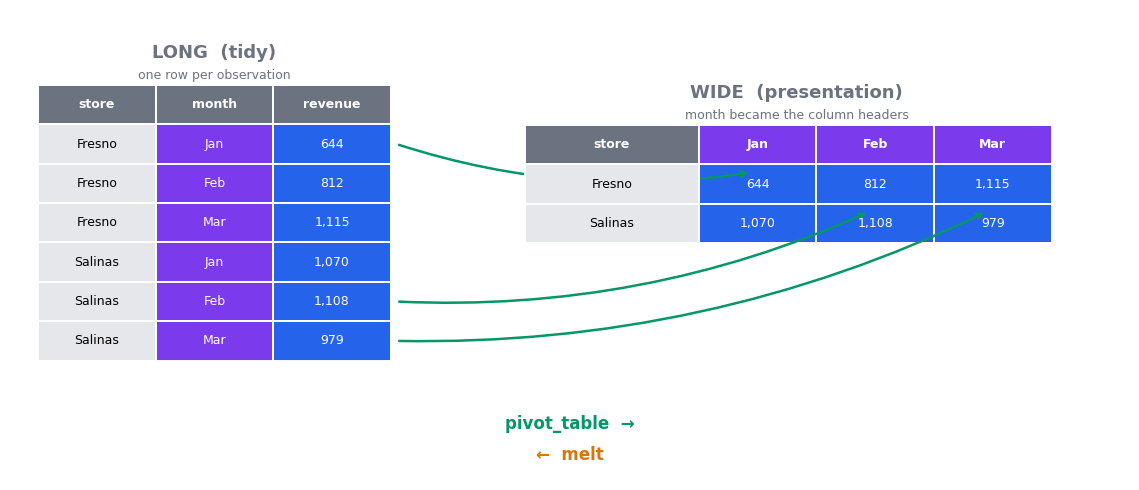

In [ ]:
# ============================================================
#  ONE picture: the same six numbers, twice.
#  Left = long (one row per observation). Right = wide (month
#  became the column headers). The arrows show that nothing is
#  computed -- each long row simply lands in one wide cell.
# ============================================================
shape_demo = (txn[txn["store"].isin(["Fresno", "Salinas"])]
              .groupby(["store", "month_name"])["revenue"].sum()
              .round(0).astype(int).reset_index())
shape_demo = shape_demo[shape_demo["month_name"].isin(["Jan", "Feb", "Mar"])].copy()
shape_demo["month_name"] = pd.Categorical(shape_demo["month_name"], MONTHS, ordered=True)
shape_demo = shape_demo.sort_values(["store", "month_name"]).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(11.5, 5.0))
ax.set_xlim(0, 10); ax.set_ylim(0, 7.4); ax.axis("off"); ax.grid(False)

# z: data cells sit at 1, arrows at 2, labels/headers at 3, all text at 4 --
# so an arrow passes BEHIND a row label and lands ON TOP of the cell it feeds
def box(x, y, w, h, text, fc, tc="black", weight="normal", size=10, z=3):
    ax.add_patch(plt.Rectangle((x, y), w, h, facecolor=fc, edgecolor="white",
                               lw=1.4, zorder=z))
    ax.text(x + w / 2, y + h / 2, text, ha="center", va="center", zorder=4,
            color=tc, fontweight=weight, fontsize=size)

# ---- LONG (left): 6 rows x 3 columns
LX, LY, CW, RH = 0.25, 5.6, 1.05, 0.62
for j, name in enumerate(["store", "month", "revenue"]):
    box(LX + j * CW, LY, CW, RH, name, C_GREY, "white", "bold", 9)
row_mid = {}
for i, r in shape_demo.iterrows():
    y = LY - (i + 1) * RH
    row_mid[(r["store"], str(r["month_name"]))] = y + RH / 2
    box(LX + 0 * CW, y, CW, RH, r["store"][:8], C_SOFT, size=9)
    box(LX + 1 * CW, y, CW, RH, str(r["month_name"]), C_IDX, "white", size=9)
    box(LX + 2 * CW, y, CW, RH, f"{r['revenue']:,}", C_DATA, "white", size=9, z=1)
ax.text(LX + 1.5 * CW, LY + RH + 0.42, "LONG  (tidy)", ha="center",
        fontsize=13, fontweight="bold", color=C_GREY)
ax.text(LX + 1.5 * CW, LY + RH + 0.10, "one row per observation",
        ha="center", fontsize=9, color=C_GREY)

# ---- WIDE (right): 2 rows x 3 columns
WX, WY = 6.15, 4.35
box(WX - 1.55, WY + RH, 1.55, RH, "store", C_GREY, "white", "bold", 9)
for j, m in enumerate(["Jan", "Feb", "Mar"]):
    box(WX + j * CW, WY + RH, CW, RH, m, C_IDX, "white", "bold", 9)
wide_mid = {}
for i, s in enumerate(["Fresno", "Salinas"]):
    y = WY - i * RH
    box(WX - 1.55, y, 1.55, RH, s, C_SOFT, size=9)
    for j, m in enumerate(["Jan", "Feb", "Mar"]):
        hit = (shape_demo["store"] == s) & (shape_demo["month_name"] == m)
        box(WX + j * CW, y, CW, RH,
            f"{int(shape_demo.loc[hit, 'revenue'].iloc[0]):,}",
            C_DATA, "white", size=9, z=1)
        wide_mid[(s, m)] = (WX + j * CW, y + RH / 2)
ax.text(WX + 1.5 * CW - 0.7, WY + 2 * RH + 0.42, "WIDE  (presentation)",
        ha="center", fontsize=13, fontweight="bold", color=C_GREY)
ax.text(WX + 1.5 * CW - 0.7, WY + 2 * RH + 0.10, "month became the column headers",
        ha="center", fontsize=9, color=C_GREY)

# ---- arrows: three long rows to the wide cell each one lands in
for key in [("Fresno", "Jan"), ("Salinas", "Feb"), ("Salinas", "Mar")]:
    x2, y2 = wide_mid[key]
    ax.annotate("", xy=(x2 + CW * 0.45, y2 + RH * 0.30),
                xytext=(LX + 3 * CW + 0.05, row_mid[key]),
                zorder=2,
                arrowprops=dict(arrowstyle="->", color=C_GROUP, lw=1.8,
                                connectionstyle="arc3,rad=0.12"))
ax.text(5.0, 0.80, "pivot_table  →", ha="center", fontsize=12,
        fontweight="bold", color=C_GROUP)
ax.text(5.0, 0.32, "←  melt", ha="center", fontsize=12,
        fontweight="bold", color=C_WARN)
plt.tight_layout(); plt.show()


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Six numbers drawn twice. On the left, long form: six rows, three columns, and the word `Jan` appears as a *value* inside a `month` column. On the right, the same six numbers as a 2x3 grid, where `Jan` is now a column *header*. The three green arrows follow individual observations across — Fresno/Jan on the left is the top-left number on the right. No arithmetic happened between the two pictures: both hold the identical six revenue totals.

**The common misread:** believing wide form is a summary and long form is the raw data. Both are the same data at the same granularity here. What changed is *where the month lives* — in the data, or in the schema. That is the whole of reshaping, and it is why the round trip a few cells from now comes back exactly equal.

</div>

## 🧮 `pivot_table` — the workhorse

```python
df.pivot_table(index=..., columns=..., values=..., aggfunc=...)
```

Read it as a sentence: *put these down the side, those across the top, fill the
cells with this column, combined using that function.* It is Part 6's
split-apply-combine with the result laid out as a rectangle — internally, it is
literally a `groupby`.

Two arguments earn their keep and almost nobody uses them:

- **`margins=True`** adds a row and a column of totals. That is a free sanity
  check: the bottom-right corner must equal the ungrouped total, and if it does
  not, a filter dropped something you did not mean to drop.
- **`fill_value=0`** replaces the `NaN` that appears where a combination never
  occurred. Use it *only* where "never happened" genuinely means zero — for a
  count it does, for an average it does not.

### `pivot` is a different function

`pivot` is *not* a shorter `pivot_table`. It does no aggregation at all: it
assumes each index/column pair appears exactly once and merely rearranges. Hand
it data where a pair repeats and it raises rather than guessing what you meant.
That refusal is a feature, and running head-first into it is how most people
finally learn the difference — so we will run into it deliberately.


In [ ]:
# ---- 1. the basic grid: stores down the side, months across the top --------
grid = txn.pivot_table(index="store", columns="month_name",
                       values="revenue", aggfunc="sum")[MONTHS]
print("revenue by store x month")
print(grid.round(2))

# ---- 2. totals on both edges, and a zero-fill ------------------------------
grid_tot = txn.pivot_table(index="store", columns="category", values="revenue",
                           aggfunc="sum", margins=True, margins_name="TOTAL",
                           fill_value=0)
print("\nrevenue by store x category, with margins")
print(grid_tot.round(2))
print(f"\ncorner    = {grid_tot.loc['TOTAL', 'TOTAL']:,.2f}")
print(f"ungrouped = {txn['revenue'].sum():,.2f}   match: "
      f"{np.isclose(grid_tot.loc['TOTAL', 'TOTAL'], txn['revenue'].sum())}")

# ---- 3. two aggregations at once -> a two-level column index ---------------
multi = txn.pivot_table(index="region", columns="category",
                        values="revenue", aggfunc=["sum", "mean"]).round(2)
print("\ntwo aggfuncs -> the columns become two levels deep")
print(multi)

# ---- 4. the same request through pivot(), which refuses --------------------
n_pairs = txn.groupby(["store", "category"]).ngroups
try:
    txn.pivot(index="store", columns="category", values="revenue")
except ValueError as e:
    print(f"\npivot() raised {type(e).__name__}: {e}")
print(f"{len(txn)} rows collapse into only {n_pairs} distinct store x category "
      f"pairs (~{len(txn) / n_pairs:.0f} rows competing for every cell)")


revenue by store x month
month_name       Jan      Feb      Mar      Apr     May     Jun
store                                                          
Bakersfield  1002.50   707.25   881.75  1089.50  737.25  650.75
Fresno        644.50   812.25  1115.25  1155.75  677.00  787.50
Modesto       648.00   683.50   779.75  1060.00  699.75  680.00
Salinas      1070.25  1107.50   979.00   568.25  998.25  675.00
Stockton      742.75   756.25   830.75   818.25  840.00  668.75

revenue by store x category, with margins
category       drink     food     TOTAL
store                                  
Bakersfield   2668.0  2401.00   5069.00
Fresno        3009.5  2182.75   5192.25
Modesto       3022.0  1529.00   4551.00
Salinas       3679.0  1719.25   5398.25
Stockton      2759.0  1897.75   4656.75
TOTAL        15137.5  9729.75  24867.25

corner    = 24,867.25
ungrouped = 24,867.25   match: True

two aggfuncs -> the columns become two levels deep
                sum            mean       
category  

/tmp/ipykernel_11031/3203797608.py:8: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  grid_tot = txn.pivot_table(index="store", columns="category", values="revenue",
/tmp/ipykernel_11031/3203797608.py:18: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  multi = txn.pivot_table(index="region", columns="category",
/tmp/ipykernel_11031/3203797608.py:18: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  multi = txn.pivot_table(index="region", columns="category",
/tmp/ipykernel_11031/3203797608.py:24: FutureWarning: 

<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Four results. The first grid is 5 stores x 6 months of summed revenue — the same numbers `groupby(['store', 'month_name']).sum()` gives, laid out as a rectangle instead of a stacked list. The second adds `margins=True`, and the printed comparison confirms the corner cell equals the ungrouped `txn['revenue'].sum()` exactly, so nothing fell out on the way. The third passes `aggfunc=['sum', 'mean']` and the columns become two levels deep — `sum` and `mean` on top, `drink`/`food` underneath, with `Unassigned` showing up as a region because Part 4 labelled the missing ones rather than dropping them. The fourth is a deliberate failure: `pivot` raised `ValueError` because those hundreds of rows collapse into only ten store x category pairs.

**The common misread:** reading the two-level column result as a wider table with odd headers. It is not wider — it is *deeper*. Selecting from it needs `multi['sum']['drink']` or `multi[('sum', 'drink')]`, and `multi['drink']` raises a `KeyError`, because `drink` is not a top-level key any more.

</div>

<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ The trap

**`pivot` raised `ValueError: Index contains duplicate entries, cannot reshape`, and beginners read that as a bug.** It is the opposite. `pivot` guarantees it will never change your numbers — it only moves them. If two rows want the same cell, there is no honest answer, so it refuses.

`pivot_table` never raises here, because it has an `aggfunc` to fall back on — and its default is `aggfunc='mean'`. **That default is the real trap.** `df.pivot_table(index=..., columns=..., values=...)` with no `aggfunc` silently hands you averages when you almost certainly wanted sums, and an average of revenue looks entirely plausible sitting in a grid. Always pass `aggfunc` explicitly, even when the default happens to be what you meant.

Rule of thumb: use `pivot` when you believe the pairs are unique and want to be *told* if they are not; use `pivot_table` when you know you are aggregating, and say so out loud.

</div>

## 🔁 `melt` — the way back

`melt` is the inverse of `pivot_table`: it takes columns and turns their *names*
back into values.

```python
df.melt(id_vars=..., value_vars=..., var_name=..., value_name=...)
```

- **`id_vars`** — columns to keep as they are. These identify the observation.
- **`value_vars`** — columns to collapse. Their headers become a new column.
- **`var_name` / `value_name`** — what to call the two new columns. Skip these
  and you get `variable` and `value`, which you will rename immediately anyway.

The honest test of any reshape is a round trip. Wide → long → wide should give
back exactly what you started with, and if it does not, something was lost on
the way.


In [ ]:
# ---- wide -> long ----------------------------------------------------------
flat = grid.reset_index()          # move `store` out of the index, into a column
long = flat.melt(id_vars="store", value_vars=MONTHS,
                 var_name="month_name", value_name="revenue")

print(f"wide grid : {grid.shape[0]} rows x {grid.shape[1]} cols = "
      f"{grid.shape[0] * grid.shape[1]} numbers")
print(f"melted    : {long.shape[0]} rows x {long.shape[1]} cols")
print(long.head(4))

# ---- long -> wide again, and check we got back what we started with --------
back = long.pivot(index="store", columns="month_name", values="revenue")[MONTHS]
print(f"\nround trip identical : {back.equals(grid)}")
print(f"same grand total     : "
      f"{np.isclose(back.to_numpy().sum(), grid.to_numpy().sum())}")

# ---- and why you would bother: `month_name` is a column again --------------
print("\nafter melting, month is a COLUMN, so groupby works on it:")
print(long.groupby("month_name")["revenue"].sum().reindex(MONTHS).round(2))


wide grid : 5 rows x 6 cols = 30 numbers
melted    : 30 rows x 3 cols
         store month_name  revenue
0  Bakersfield        Jan  1002.50
1       Fresno        Jan   644.50
2      Modesto        Jan   648.00
3      Salinas        Jan  1070.25

round trip identical : True
same grand total     : True

after melting, month is a COLUMN, so groupby works on it:
month_name
Jan    4108.00
Feb    4066.75
Mar    4586.50
Apr    4691.75
May    3952.25
Jun    3462.00
Name: revenue, dtype: float64


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

The 5 x 6 grid holds 30 numbers; melting it produces exactly 30 rows and 3 columns — the same 30 numbers, with their row and column labels written out beside each one. `back.equals(grid)` prints `True`, so the round trip is lossless: nothing was averaged, filled or reordered going out and coming back. The last block shows the payoff — once month is a column rather than six headers, `groupby` is available again; on the wide grid it is not.

**The common misread:** expecting `melt` to shrink the data. It does the opposite to the row count — 5 rows become 30 — while holding the number of *values* fixed at 30. Long form is taller and far more repetitive on purpose, and that repetition is exactly what lets every row stand on its own.

</div>

## 🥞 `stack` / `unstack`, and the MultiIndex underneath

`pivot_table` and `melt` work on columns. `stack` and `unstack` do the same job
one level down, on the **index**:

| | Moves | Result |
|---|---|---|
| `unstack()` | innermost **index** level → **columns** | wider, shorter |
| `stack()` | innermost **column** level → **index** | narrower, taller |
| `unstack(level=0)` | the *outermost* index level instead | you choose which one moves |

This is why some of Part 6's results felt awkward to read: grouping on two keys
returns a Series with a **two-level index**, and `unstack()` is the single call
that turns it into the grid you were already picturing in your head.

Living with a MultiIndex takes three habits:

- **`.loc[("Fresno", "latte")]`** — index with a *tuple*, not two arguments.
- **`.xs("latte", level="product")`** — cross-section: take one value of an
  inner level and drop that level. Far clearer than a tuple with a slice in it.
- **`.sort_index()`** — before you slice ranges. pandas can only slice a
  MultiIndex properly when it is lexsorted; on an unsorted one it raises
  `UnsortedIndexError` rather than quietly returning something wrong.


In [ ]:
# ---- a two-level index is what grouping on two keys gives you -------------
by_sc = txn.groupby(["store", "category"], observed=True)["revenue"].sum().round(2)
print("a Series with a 2-level index:")
print(by_sc.head(4))
print(f"index levels: {by_sc.index.names}   entries: {len(by_sc)}")

# ---- unstack: an index level becomes columns ------------------------------
print("\nunstack()        -> category across the top")
print(by_sc.unstack().round(2))
print("\nunstack(level=0) -> store across the top instead")
print(by_sc.unstack(level=0).round(2))
print(f"\nstack() undoes it exactly: {by_sc.unstack().stack().equals(by_sc)}")

# ---- selecting from a MultiIndex ------------------------------------------
by_sp = txn.groupby(["store", "product"], observed=True)["revenue"].sum().round(2)
print(f"\n.loc[('Fresno', 'latte')] = {by_sp.loc[('Fresno', 'latte')]:,.2f}")
print(".xs('latte', level='product') ->")
print(by_sp.xs("latte", level="product").round(2))

# ---- and the reason sort_index() exists -----------------------------------
shuffled = by_sp.sample(frac=1, random_state=0)    # same data, scrambled order
print(f"\nis the index sorted? {shuffled.index.is_monotonic_increasing}")
try:
    shuffled.loc[("Fresno", "latte"):("Modesto", "muffin")]
except Exception as e:
    print(f"slicing it raised {type(e).__name__}: {e}")
ok = shuffled.sort_index().loc[("Fresno", "latte"):("Modesto", "muffin")]
print(f"after sort_index() the same slice returns {len(ok)} rows")


a Series with a 2-level index:
store        category
Bakersfield  drink       2668.00
             food        2401.00
Fresno       drink       3009.50
             food        2182.75
Name: revenue, dtype: float64
index levels: ['store', 'category']   entries: 10

unstack()        -> category across the top
category      drink     food
store                       
Bakersfield  2668.0  2401.00
Fresno       3009.5  2182.75
Modesto      3022.0  1529.00
Salinas      3679.0  1719.25
Stockton     2759.0  1897.75

unstack(level=0) -> store across the top instead
store     Bakersfield   Fresno  Modesto  Salinas  Stockton
category                                                  
drink          2668.0  3009.50   3022.0  3679.00   2759.00
food           2401.0  2182.75   1529.0  1719.25   1897.75

stack() undoes it exactly: True

.loc[('Fresno', 'latte')] = 1,178.00
.xs('latte', level='product') ->
store
Bakersfield    1306.25
Fresno         1178.00
Modesto        1220.75
Salinas        1795.50

<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

The same ten store x category totals, shown three ways: as a ten-entry Series with a two-level index, as a 5 x 2 grid after `unstack()`, and as a 2 x 5 grid after `unstack(level=0)`. `stack()` reverses it exactly — the printed check is `True`. Below that, two ways to pull one thing out: a tuple gives a single scalar, while `.xs('latte', level='product')` gives one value per store with the `product` level dropped entirely. The final block scrambles the index order, fails to slice it, then succeeds after `sort_index()`.

**The common misread:** thinking `unstack()` computed something. It did not — the ten numbers in the Series are the ten numbers in the grid. What the grid adds is a *shape*, in which a combination that never occurred shows up as a visible `NaN`. That is often the entire point: the long Series silently omits the pairs that never happened, so you cannot see the holes at all.

</div>

<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ The trap

**`shuffled.loc[('Fresno', 'latte'):('Modesto', 'muffin')]` raised `UnsortedIndexError: Key length (2) was greater than MultiIndex lexsort depth (0)`** — and the data was perfectly valid, merely in a different order.

A MultiIndex slice is a *range* lookup, and a range only means anything on sorted keys. pandas will not sort behind your back — that would reorder your output without asking — so it raises instead. On larger frames you may instead get a `PerformanceWarning` about lexsort depth in the cases where it can still answer; that warning is telling you the lookup degraded into a full scan.

**Fix:** call `df.sort_index()` once, immediately after you build a MultiIndex, and never think about it again. It is cheap, and it makes every later slice both legal and fast. Single-key lookups like `.loc[('Fresno', 'latte')]` work either way — which is exactly why this bites late, in the one line where you finally reach for a range.

</div>

## 🔗 Joining: `merge`, and knowing what you kept

Reshaping rearranges one table. **Joining** brings a second one alongside.

We have transactions keyed by `store`. Head office keeps a separate five-row
table: who manages each store, when it opened, how big it is. To ask "revenue
per square foot" you need those two tables side by side.

Our lookup table is deliberately imperfect, because real lookup tables are:

- **Fresno is missing from it** — a real store, with real sales, and no metadata row.
- **Merced is in it but has no sales** — a store that opens next month.

That single mismatch is enough to make all four join types give four different
answers, which is the only way to really learn them:

| `how=` | Keeps | Answers the question |
|---|---|---|
| `'inner'` | keys in **both** | "rows I can fully describe" |
| `'left'` | **all** left rows | "my data, enriched where possible" |
| `'right'` | **all** right rows | "the lookup table, with sales attached" |
| `'outer'` | keys in **either** | "everything, and show me the gaps" |

And one argument to reach for every single time you merge: **`indicator=True`**
adds a `_merge` column saying `left_only`, `right_only` or `both` for every
output row. It turns "did I lose anything?" from a guess into a `value_counts()`.
<div style="background-color: #f3e5f5; border-left: 5px solid #9c27b0; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🧭 `merge` vs `join` vs `concat`

- **`merge`** — match on **column values**. The default, and the one to reach for.
- **`.join()`** — match on the **index**. Shorthand for `merge(left_index=True, right_index=True)`; convenient once your key already *is* the index.
- **`pd.concat`** — match on nothing; glue frames together along an axis. It aligns on the *other* axis, which is exactly where it surprises people.

</div>

In [ ]:
# ============================================================
#  The lookup table. Fresno is MISSING from it; Merced is in
#  it but has no sales. Both gaps are deliberate.
# ============================================================
store_meta = pd.DataFrame({
    "store":   ["Bakersfield", "Modesto", "Salinas", "Stockton", "Merced"],
    "manager": ["Ana Ruiz", "Dev Patel", "Kim Ortega", "Sam Iyer", "Lena Cho"],
    "opened":  pd.to_datetime(["2019-04-01", "2021-09-15", "2018-02-20",
                               "2022-06-01", "2024-07-10"]),
    "sq_ft":   [1450, 1100, 1780, 980, 1250],
})
print(store_meta)

sold, known = set(txn["store"].unique()), set(store_meta["store"])
print(f"\nsales but no metadata: {sorted(sold - known)}  "
      f"({(txn['store'] == 'Fresno').sum()} rows)")
print(f"metadata but no sales: {sorted(known - sold)}")

# ---- the four joins, with the row count printed for each ------------------
JOIN_ROWS = {}
print(f"\nleft frame `txn` has {len(txn)} rows; "
      f"right frame `store_meta` has {len(store_meta)}\n")
for how in ["inner", "left", "right", "outer"]:
    m = txn.merge(store_meta, on="store", how=how)
    JOIN_ROWS[how] = len(m)
    print(f"  how={how:<6s} -> {len(m):4d} rows   "
          f"null manager: {m['manager'].isna().sum():3d}   "
          f"null revenue: {m['revenue'].isna().sum():3d}")

# ---- indicator=True: exactly where every output row came from -------------
audit = txn.merge(store_meta, on="store", how="outer", indicator=True)
print("\nouter join with indicator=True:")
print(audit["_merge"].value_counts())
print("\nthe right_only row -- metadata for a store with no sales:")
print(audit.loc[audit["_merge"] == "right_only",
                ["store", "manager", "sq_ft", "revenue", "_merge"]])


         store     manager     opened  sq_ft
0  Bakersfield    Ana Ruiz 2019-04-01   1450
1      Modesto   Dev Patel 2021-09-15   1100
2      Salinas  Kim Ortega 2018-02-20   1780
3     Stockton    Sam Iyer 2022-06-01    980
4       Merced    Lena Cho 2024-07-10   1250

sales but no metadata: ['Fresno']  (188 rows)
metadata but no sales: ['Merced']

left frame `txn` has 894 rows; right frame `store_meta` has 5

  how=inner  ->  706 rows   null manager:   0   null revenue:   0
  how=left   ->  894 rows   null manager: 188   null revenue:   0
  how=right  ->  707 rows   null manager:   0   null revenue:   1
  how=outer  ->  895 rows   null manager: 188   null revenue:   1

outer join with indicator=True:
_merge
both          706
left_only     188
right_only      1
Name: count, dtype: int64

the right_only row -- metadata for a store with no sales:
      store   manager   sq_ft  revenue      _merge
374  Merced  Lena Cho  1250.0      NaN  right_only


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

The five-row lookup table, the mismatch stated explicitly, then the four joins with their measured row counts. `inner` keeps 706 rows — it dropped all 188 Fresno transactions and said nothing about it. `left` keeps all 894 and leaves `manager` null on those same 188. `right` returns 707: the 706 matched rows plus one all-null row for Merced. `outer` returns 895, the union of both sides. The `indicator=True` breakdown then decomposes that 895 into 706 `both`, 188 `left_only` and 1 `right_only` — the same three numbers, reached from the other direction.

**The common misread:** reading `left` as the safe choice because the row count did not change. The count is identical, but 188 of those rows now carry `NaN` in `manager`, `opened` and `sq_ft` — so any later `groupby('manager')` or `revenue / sq_ft` silently excludes a fifth of the business. An unchanged row count means you did not lose rows. It says nothing at all about whether you gained nulls.

</div>

<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ The trap

**`how='inner'` dropped 188 rows — a fifth of the data — and printed nothing.** No warning, no message, no exception. You get a smaller frame and a plausible answer, and every total computed afterwards is quietly too low.

This is the most common way a pandas analysis becomes *wrong* without ever becoming *broken*. Nothing errors. The numbers simply fail to match the source system, and by the time anyone notices, the offending merge is forty cells back.

**Fix — two lines, on every merge:**

```python
m = left.merge(right, on='store', how='left', indicator=True)
print(m['_merge'].value_counts())
```

If you expected everything to match, `left_only` should be `0`. If it is not, you have found a data problem now rather than in a meeting. Drop the column once you are satisfied. Cheaper still, assert the expectation outright: `assert len(m) == len(left)`.

</div>

In [ ]:
# ---- when the key columns have DIFFERENT names ----------------------------
targets = store_meta.rename(columns={"store": "location"})[["location", "sq_ft"]].copy()
targets["revenue"] = [5000.0, 4500.0, 5000.0, 4200.0, 3000.0]   # six-month target
by_key = txn.merge(targets, left_on="store", right_on="location", how="left",
                   suffixes=("_actual", "_target"))
print("both frames had a `revenue` column, so `suffixes` kept them apart:")
print([c for c in by_key.columns if "revenue" in c or c in ("store", "location")])
print(by_key[["store", "location", "revenue_actual", "revenue_target"]].head(3))

# ---- .join(): the same idea, matched on the INDEX -------------------------
joined = txn.set_index("store").join(store_meta.set_index("store"), how="left")
print(f"\n.join() on the index -> {len(joined)} rows "
      f"(same as merge how='left': {len(joined) == JOIN_ROWS['left']})")

# ---- what the join was FOR: a number neither table contains ---------------
per_sqft = (txn.merge(store_meta, on="store", how="inner")
              .groupby(["store", "sq_ft"], observed=True)["revenue"].sum().reset_index())
per_sqft["rev_per_sqft"] = (per_sqft["revenue"] / per_sqft["sq_ft"]).round(3)
print("\nrevenue per square foot (only computable AFTER the join):")
print(per_sqft.sort_values("rev_per_sqft", ascending=False))


both frames had a `revenue` column, so `suffixes` kept them apart:
['store', 'revenue_actual', 'location', 'revenue_target']
      store  location  revenue_actual  revenue_target
0  Stockton  Stockton           25.50          4200.0
1    Fresno       NaN           29.25             NaN
2  Stockton  Stockton           31.50          4200.0

.join() on the index -> 894 rows (same as merge how='left': True)

revenue per square foot (only computable AFTER the join):
         store  sq_ft  revenue  rev_per_sqft
3     Stockton    980  4656.75         4.752
1      Modesto   1100  4551.00         4.137
0  Bakersfield   1450  5069.00         3.496
2      Salinas   1780  5398.25         3.033


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Three uses of the same lookup. First, `left_on='store'` / `right_on='location'` matches columns whose names differ, and because both frames carried a `revenue` column, `suffixes=('_actual', '_target')` kept them apart — note pandas also kept *both* key columns, `store` and `location`, which are now redundant copies of one another, and that `revenue_target` is a store-level number stamped onto every one of that store's transaction rows, sitting next to a row-level `revenue_actual`. Second, `.join()` reaches the identical 894 rows by putting the key in the index first, and the printed equality confirms it matches the `how='left'` merge exactly. Third, the payoff: revenue per square foot, a number that exists in neither table on its own.

**The common misread:** assuming the store with the highest revenue also leads on revenue per square foot. The ranking above is computed, and normalising by floor area reverses it — the biggest earner is also the biggest shop, and it finishes last per square foot. That reversal is the entire reason anyone joins a metadata table. Note too that Fresno is absent from this ranking altogether, because the inner join dropped it.

</div>

In [ ]:
# ============================================================
#  THE EXPENSIVE BUG. Head office sends an updated metadata
#  file. Salinas changed manager mid-year, so it now appears
#  TWICE -- one row for the old manager, one for the new.
#  Nobody mentions this. We merge exactly as before.
# ============================================================
handover = pd.DataFrame({
    "store": ["Salinas"], "manager": ["Jo Park"],
    "opened": pd.to_datetime(["2018-02-20"]), "sq_ft": [1780]})
meta_v2 = pd.concat([store_meta, handover], ignore_index=True)

exploded = txn.merge(meta_v2, on="store", how="left")
n_salinas = int((txn["store"] == "Salinas").sum())

print(f"rows BEFORE the merge : {len(txn)}")
print(f"rows AFTER  the merge : {len(exploded)}     <-- and this is how='left'!")
print(f"gained                : {len(exploded) - len(txn)}   "
      f"(the {n_salinas} Salinas rows, each emitted twice)")
print(f"revenue BEFORE : {txn['revenue'].sum():,.2f}")
print(f"revenue AFTER  : {exploded['revenue'].sum():,.2f}   "
      f"(+{exploded['revenue'].sum() - txn['revenue'].sum():,.2f} "
      f"= {100 * (exploded['revenue'].sum() / txn['revenue'].sum() - 1):.1f}% "
      f"of revenue invented)")

# ---- the two one-line defences -------------------------------------------
print(f"\nis the key unique on the right? {meta_v2['store'].is_unique}")
try:
    txn.merge(meta_v2, on="store", how="left", validate="many_to_one")
except Exception as e:
    print(f"validate='many_to_one' raised {type(e).__name__}: "
          f"{str(e).splitlines()[0]}")
fixed = txn.merge(meta_v2.drop_duplicates("store"), on="store", how="left")
print(f"after drop_duplicates on the key: {len(fixed)} rows "
      f"(unchanged: {len(fixed) == len(txn)})")


rows BEFORE the merge : 894
rows AFTER  the merge : 1080     <-- and this is how='left'!
gained                : 186   (the 186 Salinas rows, each emitted twice)
revenue BEFORE : 24,867.25
revenue AFTER  : 30,265.50   (+5,398.25 = 21.7% of revenue invented)

is the key unique on the right? False
validate='many_to_one' raised MergeError: Merge keys are not unique in right dataset; not a many-to-one merge
after drop_duplicates on the key: 894 rows (unchanged: True)


<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ The trap

**A `how='left'` merge grew the frame from 894 rows to 1,080 and inflated total revenue by over 20%, and this is the most expensive bug in practical pandas.**

`how='left'` does not promise to preserve the row *count*. It promises to keep every left *key*. If a key matches two rows on the right, the left row is emitted twice. Our 186 Salinas transactions each matched 2 metadata rows, so 186 extra rows appeared and every Salinas sale was counted twice.

It is expensive because the result looks completely normal. The columns are right, the dtypes are right, `head()` is right. Only the totals are wrong, by a fraction that depends on which store happened to duplicate — so it survives review and reaches a dashboard.

**Two defences, both one line:**

```python
right['key'].is_unique                                # check before merging
left.merge(right, on='key', validate='many_to_one')   # let pandas check
```

`validate=` accepts `'one_to_one'`, `'one_to_many'`, `'many_to_one'` and `'many_to_many'`, and raises `MergeError` the instant reality disagrees with what you claimed. It costs nothing and converts a silent wrong number into a loud stack trace. Put it on every lookup-table merge you write.

</div>

In [ ]:
# ============================================================
#  pd.concat -- gluing, not matching.
#  axis=0 stacks rows; axis=1 puts frames side by side. BOTH
#  align on the other axis, and that is the whole trap.
# ============================================================
# two batches that each arrived with their own 0..n-1 index, as two
# freshly-read CSVs would
jan = txn[txn["month_name"] == "Jan"][["store", "product", "revenue"]].head(3).reset_index(drop=True)
feb = txn[txn["month_name"] == "Feb"][["store", "product", "revenue"]].head(3).reset_index(drop=True)

stacked = pd.concat([jan, feb])
print(f"axis=0 -> {len(stacked)} rows, index {stacked.index.tolist()}, "
      f"unique: {stacked.index.is_unique}")
print(f"so .loc[0] now returns {len(stacked.loc[[0]])} rows, not 1")
print(f"ignore_index=True -> index "
      f"{pd.concat([jan, feb], ignore_index=True).index.tolist()}")

keyed = pd.concat([jan, feb], keys=["Jan", "Feb"], names=["batch", "row"])
print("\nkeys= adds an outer index level, so you can still tell them apart:")
print(keyed)

# ---- axis=1, done the way people expect it to work ------------------------
top4   = txn.nlargest(4, "revenue")[["store", "revenue"]]
names4 = txn.nlargest(4, "revenue")[["product"]].reset_index(drop=True)
print(f"\ntop4   index: {top4.index.tolist()}")
print(f"names4 index: {names4.index.tolist()}")

side = pd.concat([top4, names4], axis=1)
print(f"\npd.concat([top4, names4], axis=1) -> {side.shape[0]} rows "
      f"(we wanted 4) and {int(side.isna().sum().sum())} NaNs:")
print(side)

good = pd.concat([top4.reset_index(drop=True), names4], axis=1)
print(f"\nafter making the indexes agree -> {good.shape[0]} rows, "
      f"{int(good.isna().sum().sum())} NaNs:")
print(good)


axis=0 -> 6 rows, index [0, 1, 2, 0, 1, 2], unique: False
so .loc[0] now returns 2 rows, not 1
ignore_index=True -> index [0, 1, 2, 3, 4, 5]

keys= adds an outer index level, so you can still tell them apart:
                 store    product  revenue
batch row                                 
Jan   0    Bakersfield     muffin    21.00
      1        Salinas     cookie    13.50
      2        Salinas   espresso    29.25
Feb   0       Stockton  cold brew    25.50
      1    Bakersfield      latte    47.50
      2       Stockton      latte    42.75

top4   index: [816, 362, 372, 546]
names4 index: [0, 1, 2, 3]

pd.concat([top4, names4], axis=1) -> 8 rows (we wanted 4) and 12 NaNs:
        store  revenue    product
816   Modesto    90.25        NaN
362    Fresno    76.00        NaN
372    Fresno    76.00        NaN
546  Stockton    72.25        NaN
0         NaN      NaN      latte
1         NaN      NaN      latte
2         NaN      NaN      latte
3         NaN      NaN  cold brew

after

<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ The trap

**`pd.concat([top4, names4], axis=1)` on two 4-row frames returned 8 rows and 12 `NaN`s.** Nothing was corrupted and nothing errored — pandas did what it always does, which is *align on the index*.

`top4` kept its original row labels from `txn`; `names4` had been through `reset_index(drop=True)`, so its labels were `0, 1, 2, 3`. The two label sets do not overlap at all, so their union has 8 entries, and every cell outside its own frame is missing. `concat` never lines frames up by *position* — it lines them up by *label*, always.

**Fix:** make the indexes agree before gluing — `pd.concat([a.reset_index(drop=True), b.reset_index(drop=True)], axis=1)` — or stop pretending the operation is positional and do a real `merge` on a real key. The very same alignment rule is why `df['a'] = some_series` can fill a column with `NaN` when the series came from a filtered frame: it is this bug wearing different clothes.

On `axis=0` the mirror image applies. `concat` keeps the original row labels, so stacking two batches that both start at `0` gives you a duplicated index, and a later `.loc[0]` returns two rows instead of one. Pass `ignore_index=True` for a fresh `0..n-1`, or `keys=[...]` to record which frame each row came from.

</div>

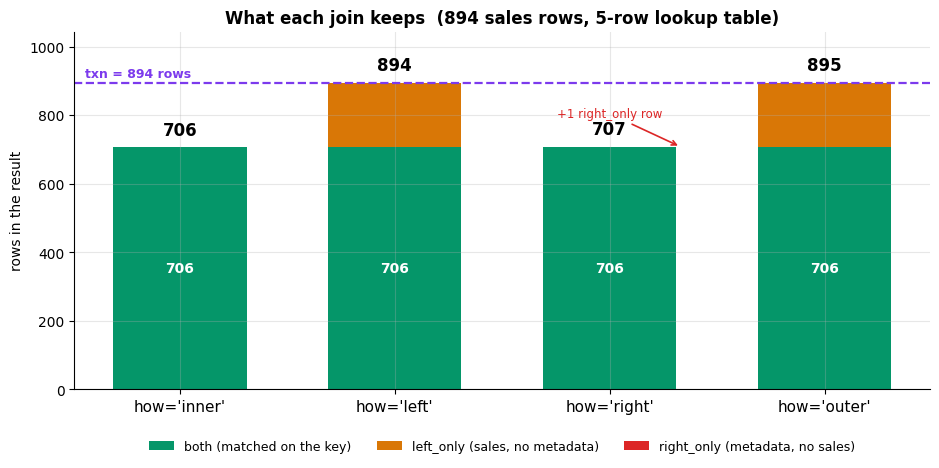

{'inner': 706, 'left': 894, 'right': 707, 'outer': 895}


In [ ]:
# ============================================================
#  The four join types, drawn from the counts we measured
#  above -- there is not one hand-typed number in this cell.
# ============================================================
order, parts = ["inner", "left", "right", "outer"], {}
for how in order:
    vc = txn.merge(store_meta, on="store", how=how,
                   indicator=True)["_merge"].value_counts()
    parts[how] = (int(vc.get("both", 0)), int(vc.get("left_only", 0)),
                  int(vc.get("right_only", 0)))

fig, ax = plt.subplots(figsize=(9.5, 4.8))
x     = np.arange(len(order))
both  = np.array([parts[h][0] for h in order])
lonly = np.array([parts[h][1] for h in order])
ronly = np.array([parts[h][2] for h in order])

ax.bar(x, both,  0.62, color=C_GROUP, label="both (matched on the key)")
ax.bar(x, lonly, 0.62, bottom=both, color=C_WARN,
       label="left_only (sales, no metadata)")
ax.bar(x, ronly, 0.62, bottom=both + lonly, color=C_NA,
       label="right_only (metadata, no sales)")
ax.axhline(len(txn), color=C_IDX, ls="--", lw=1.6)
ax.text(-0.44, len(txn) + 18, f"txn = {len(txn)} rows", color=C_IDX,
        ha="left", fontsize=9, fontweight="bold")

for i, h in enumerate(order):
    ax.text(i, sum(parts[h]) + 36, f"{sum(parts[h])}", ha="center",
            fontweight="bold", fontsize=12)
    ax.text(i, both[i] / 2, f"{both[i]}", ha="center", va="center",
            color="white", fontweight="bold", fontsize=10)

# the right_only sliver is 1 row out of ~700 -- real, and far too thin to see
ax.annotate(f"+{ronly[2]} right_only row",
            xy=(2.33, sum(parts["right"]) + 1), xytext=(2.0, len(txn) - 100),
            ha="center", fontsize=8.5, color=C_NA,
            arrowprops=dict(arrowstyle="->", color=C_NA, lw=1.2))

ax.set_xticks(x); ax.set_xticklabels([f"how='{h}'" for h in order], fontsize=11)
ax.set_ylabel("rows in the result")
ax.set_title(f"What each join keeps  ({len(txn)} sales rows, "
             f"{len(store_meta)}-row lookup table)", fontweight="bold")
ax.set_ylim(0, len(txn) + 150)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.11), ncol=3,
          fontsize=9, frameon=False)
plt.tight_layout(); plt.show()

print({h: sum(parts[h]) for h in order})


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

The four joins as stacked bars, with every segment measured from the `indicator` column rather than typed in. Green is the 706 rows that matched on both sides — identical in all four bars, because a matched row is a matched row whatever `how` you pass. What differs is only what gets added around it: `inner` adds nothing, `left` adds the 188 amber Fresno rows, `right` adds the single red Merced row, `outer` adds both for 895. That red segment is one row out of seven hundred, so it is annotated rather than visible — a reminder that a join can leak something important at a scale no chart will ever show you. The dashed purple line is the original 894-row size of `txn`, which only the `left` and `outer` bars reach.

**The common misread:** treating bar height as a measure of quality, with taller meaning more complete. Height is not goodness — it is a statement about which question you asked. `inner` is right when a row is useless without its metadata; `left` is right when the sales are the subject and the metadata is a bonus. Reaching for `left` reflexively just moves the missingness out of the row count and into the columns, where it is much harder to see.

</div>

## ✅ Part 7 in one screen

| Task | Call | Watch out for |
|---|---|---|
| Long → grid | `pivot_table(index=, columns=, values=, aggfunc=)` | the default `aggfunc` is `'mean'` — always pass it |
| Long → grid, no aggregation | `pivot(...)` | raises on duplicate index/column pairs, on purpose |
| Totals on the edges | `margins=True, margins_name=...` | the corner must equal the ungrouped total |
| Grid → long | `melt(id_vars=, value_vars=, var_name=, value_name=)` | rows multiply; values do not |
| Index level ↔ columns | `unstack(level=)` / `stack()` | `NaN` appears where a pair never occurred |
| Slice a MultiIndex | `.loc[(a, b)]`, `.xs(v, level=)` | `sort_index()` first, or ranges raise |
| Attach a lookup table | `merge(on=, how=, indicator=True)` | read `_merge.value_counts()` every time |
| Guard the row count | `merge(..., validate='many_to_one')` | a duplicated key multiplies rows silently |
| Match on the index | `.join(other, how=)` | it is `merge` with the key already in the index |
| Glue frames | `pd.concat(objs, axis=, ignore_index=, keys=)` | it aligns on labels, never on position |

**The one habit worth keeping:** print the row count before and after every
merge. Two lines, and it catches both of the disasters in this part — the rows
that vanish on an inner join, and the rows that multiply on a duplicated key.
Everything else here is syntax you can look up; that habit is what makes the
syntax safe to use.

---

### ⏭️ Next: Part 8 — time series

We have been treating `date` as just another key: something to group by, or to
pivot across. It is not. A date knows that March follows February, that months
have different lengths, and that "the last seven days" is a meaningful window —
and pandas keeps a whole second vocabulary that only unlocks once the date
becomes the *index*.

Part 8 does exactly that, and picks up `resample` (group by time, with the empty
periods filled in rather than skipped), `rolling` (windows that move along with
you) and `shift` (compare today against last week). The `Jan`–`Jun` headers we
pivoted across here are about to become something the frame genuinely
understands, rather than six strings that happen to sort correctly.

---


---

# 8️⃣ Time series: resampling and rolling windows

## When the index is time, pandas grows a second set of powers

Part 5 turned the `date` column from text into real timestamps, and Part 6 grouped by it. Both were useful. Neither was *time series* work, because in both of them a date was just another label — pandas had no idea that `2024-03-14` comes one day after `2024-03-13`, or that there are seven of them in a week.

Move that column into the **index** and everything changes. A `DatetimeIndex` knows the calendar. It knows that `'2024-03'` names thirty-one days. It knows how to draw bin edges at month ends. It knows what the day before yesterday was. None of that is available to a `RangeIndex`, and none of it is available to a datetime column that is sitting in the frame rather than in the index.

This part is that second set of powers:

| Tool | The question it answers |
|---|---|
| Partial-string indexing | "Just show me March." |
| `.resample()` | "Roll this up to weeks. To months." |
| `.rolling()` / `.expanding()` | "What is the trend under the noise?" |
| `.shift()` / `.diff()` / `.pct_change()` | "How does today compare to yesterday? To last Tuesday?" |
| `.asfreq()` | "Is a day *missing*, and would I ever have noticed?" |
| `tz_localize` / `tz_convert` | "Whose midnight?" |

That last one is not a footnote. **A missing day in a time series does not announce itself.** There is no `NaN` row, no gap in the printout, no warning. The frame just has one fewer row than you think, and every sum you compute over it is quietly too small. We will build that failure on purpose and then find it.


In [ ]:
# ============================================================
#  Part 8 needs exactly two things: a real datetime column and
#  a revenue column. Parts 4-5 built both. This cell picks up
#  whichever cleaned frame they left in memory; if you jumped
#  straight to Part 8, it redoes that cleaning in five lines so
#  this part still runs.
# ============================================================
src = None
for _name in ("tidy", "clean5", "sales5", "orders", "trans", "clean"):
    _f = globals().get(_name)
    if (isinstance(_f, pd.DataFrame) and "revenue" in _f.columns
            and "date" in _f.columns
            and pd.api.types.is_datetime64_any_dtype(_f["date"])):
        src, src_name = _f.copy(), _name
        break

if src is None:
    src_name = "sales (re-cleaned here)"
    src = sales.drop_duplicates().copy()
    src["date"] = pd.to_datetime(src["date"])
    src["unit_price"] = src["unit_price"].str.removeprefix("$").astype(float)
    src = src[src["quantity"].gt(0)]          # drops the NaNs and the -1s
    src["revenue"] = src["quantity"] * src["unit_price"]

# One row per day. THIS is the object the rest of Part 8 works on.
daily = src.groupby("date")["revenue"].sum().sort_index()
daily.name = "revenue"

print(f"source: {src_name}  ({len(src):,} orders)")
print(f"index type : {type(daily.index).__name__}")
print(f"index dtype: {daily.index.dtype}")
print(f"index freq : {daily.index.freq!r}      <- note: None, not 'D'")
print(f"span       : {daily.index.min():%Y-%m-%d} to {daily.index.max():%Y-%m-%d}")
print(f"rows       : {len(daily)}   calendar days in that span: "
      f"{(daily.index.max() - daily.index.min()).days + 1}")
daily.head()


source: tidy  (894 orders)
index type : DatetimeIndex
index dtype: datetime64[ns]
index freq : None      <- note: None, not 'D'
span       : 2024-01-01 to 2024-06-28
rows       : 179   calendar days in that span: 180


,revenue
date,
2024-01-01,72.50
2024-01-02,137.75
2024-01-03,103.75
2024-01-04,17.50
2024-01-05,125.25


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

A `Series` named `revenue` whose index is a `DatetimeIndex` — one row per day, the day's total takings. Three lines of this printout matter more than the numbers.

`index dtype` is a real datetime type, not `object`: that is what makes everything below this cell possible. `index freq` is **`None`** — pandas built this index by collecting whatever dates actually appeared in the data, so it has no opinion about the spacing between them. And the last line compares the number of rows against the number of calendar days in the span. Read those two numbers. If they differ, at least one day is missing from this series and nothing about the printout says so.

**The common misread:** treating a `DatetimeIndex` as proof that the series is regular. It is not. A `DatetimeIndex` is a sorted bag of timestamps; "one row per day, every day" is a property of *your data*, not of the index type, and pandas will never check it for you unless you ask with `.asfreq()`.

</div>

## 8.1 Partial-string indexing: the nicest feature in pandas

Here is a thing you can do with a `DatetimeIndex` and with **no other index type in pandas**:

```python
daily.loc["2024-03"]            # all of March
daily.loc["2024-02":"2024-04"]  # February through April
```

You are indexing with a string that is not a label in the index. `"2024-03"` is not a timestamp — no row has that key. pandas parses it as a *period*, works out that it means the range from `2024-03-01 00:00:00` to `2024-03-31 23:59:59.999999999`, and returns every row inside it.

This is called **partial-string indexing**, and once it is in your fingers you stop writing date filters as boolean masks. Compare:

```python
daily[(daily.index >= "2024-03-01") & (daily.index <= "2024-03-31")]   # what you used to write
daily.loc["2024-03"]                                                    # what you write now
```

Same answer. One of them has a bug waiting in it the first time you point it at a month with thirty days.


In [ ]:
march = daily.loc["2024-03"]                 # a whole month from a 7-character string
q1    = daily.loc["2024-02":"2024-04"]       # a range of months
oneday = daily.loc["2024-03-14"]             # exact key -> a scalar, not a Series

print(f"daily.loc['2024-03']           -> {len(march)} rows, "
      f"{march.index.min():%b %d} to {march.index.max():%b %d}")
print(f"daily.loc['2024-02':'2024-04'] -> {len(q1)} rows, "
      f"{q1.index.min():%b %d} to {q1.index.max():%b %d}")
print(f"daily.loc['2024-03-14']        -> {oneday!r}  ({type(oneday).__name__})")

# The endpoint is INCLUSIVE, and it is inclusive of the whole PERIOD.
# '2024-04' as a right endpoint means "through the end of April", not "April 1st".
print(f"\nlast row of the '2024-02':'2024-04' slice: {q1.index.max():%Y-%m-%d}")
print("...so the right endpoint pulled in all of April, not just April 1.")

# It works on DataFrames too -- the index is what matters, not the object.
frame = daily.to_frame()
frame["weekday"] = frame.index.day_name()
print("\nDataFrame, first week of March:")
frame.loc["2024-03-01":"2024-03-07"]


daily.loc['2024-03']           -> 30 rows, Mar 01 to Mar 31
daily.loc['2024-02':'2024-04'] -> 89 rows, Feb 01 to Apr 30
daily.loc['2024-03-14']        -> np.float64(84.5)  (float64)

last row of the '2024-02':'2024-04' slice: 2024-04-30
...so the right endpoint pulled in all of April, not just April 1.

DataFrame, first week of March:


,revenue,weekday
date,,
2024-03-01,131.50,Friday
2024-03-02,125.75,Saturday
2024-03-03,61.00,Sunday
2024-03-05,160.50,Tuesday
2024-03-06,193.00,Wednesday
2024-03-07,82.25,Thursday


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Four ways of asking for time, all driven by a string. `'2024-03'` returned a month; `'2024-02':'2024-04'` returned three months; `'2024-03-14'` matched one exact key and so returned a **scalar float**, not a one-element Series — an exact key behaves like an exact key. The last block shows the same trick on a DataFrame, because partial-string indexing is a property of the *index*, not of the object hanging off it.

The printed last row of the `'2024-02':'2024-04'` slice is the line to look at. A right endpoint of `'2024-04'` did not stop at April 1st; it swallowed the entire month.

**The common misread:** reading `daily.loc['2024-02':'2024-04']` with Python's usual half-open slice in mind and expecting April to be excluded. `.loc` slices are inclusive on both ends — that is true of every `.loc` slice, not just datetime ones — and with a partial string the inclusive end is the *end of the named period*. If you want February and March only, ask for `'2024-02':'2024-03'`.

</div>

<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ The trap

Try this on the raw frame and watch it fail:

```python
src.loc['2024-03']                # KeyError -- date is a COLUMN, not the index
```

Partial-string indexing needs the timestamps **in the index**. A perfectly good `datetime64` column buys you `.dt` accessors and nothing else; it is `set_index('date')` (or the `groupby` above, which sets the index as a side effect) that unlocks this.

The second half of the trap is nastier because it is inconsistent. On a **non-monotonic** `DatetimeIndex` — one whose dates are not in ascending order — `daily.loc['2024-03']` still works, but `daily.loc['2024-02':'2024-04']` raises `KeyError: 'Value based partial slicing on non-monotonic DatetimeIndexes with non-existing keys is not allowed'`. Single-period lookup: fine. Range slice: refused. So an unsorted index does not break loudly and consistently — it breaks on one line and not the one beside it. `daily.sort_index()` before you start, every time, and `daily.index.is_monotonic_increasing` when you want to check.

</div>

## 8.2 `resample`: groupby, but it knows the calendar

`.resample('W')` is `.groupby()` with the bins chosen for you by the calendar. That is the entire idea. `groupby` needs you to hand it the keys; `resample` derives them from the index, which means it can produce a bin for a week that has **no data in it** — something `groupby` structurally cannot do, because a group with no rows has no key to group by.

It splits into two jobs with opposite problems:

- **Downsampling** — daily → weekly → monthly. Many rows become one, so you need an aggregation: `.sum()`, `.mean()`, `.agg([...])`.
- **Upsampling** — daily → hourly. One row becomes many, so you need a *fill* rule: `ffill`, `bfill`, `interpolate`, or leave the holes as `NaN`.

### Frequency aliases changed, so we check rather than remember

pandas 2.2 deprecated a pile of single-letter aliases and pandas 3.0 removed them. `'M'` for month-end is **gone** — it now raises `ValueError`, not a warning. So do `'Q'`, `'Y'`, `'A'`, `'H'`, `'T'`, `'S'`, `'SM'` and `'BM'`. Their replacements spell out end-versus-start (`ME`/`MS`, `QE`/`QS`, `YE`/`YS`) and lower-case the sub-daily units (`h`, `min`, `s`).

Rather than ask you to trust that paragraph, the next cell asks *your* pandas. It runs every alias through `to_offset`, the same parser `resample` uses internally, and prints the verdicts.


In [ ]:
import warnings
from pandas.tseries.frequencies import to_offset

CANDIDATES = ["D", "B", "W", "W-MON", "SM", "SME", "M", "ME", "MS",
              "Q", "QE", "QS", "Y", "YE", "YS", "A", "BM", "BME",
              "H", "h", "T", "min", "S", "s", "2W", "7D"]

verdicts = []
for a in CANDIDATES:
    try:
        with warnings.catch_warnings():
            warnings.simplefilter("error")     # a deprecation counts as a failure
            verdicts.append((a, "accepted", repr(to_offset(a))))
    except Exception as e:
        verdicts.append((a, "REJECTED", type(e).__name__))

alias_table = pd.DataFrame(verdicts, columns=["alias", "verdict", "meaning"])
print(f"pandas {pd.__version__} -- verified here, not remembered:\n")
print(alias_table.to_string(index=False))
print(f"\nrejected: {', '.join(alias_table.loc[alias_table.verdict.eq('REJECTED'), 'alias'])}")


pandas 2.2.3 -- verified here, not remembered:

alias  verdict                         meaning
    D accepted                           <Day>
    B accepted                   <BusinessDay>
    W accepted               <Week: weekday=6>
W-MON accepted               <Week: weekday=0>
   SM REJECTED                   FutureWarning
  SME accepted <SemiMonthEnd: day_of_month=15>
    M REJECTED                   FutureWarning
   ME accepted                      <MonthEnd>
   MS accepted                    <MonthBegin>
    Q REJECTED                   FutureWarning
   QE accepted  <QuarterEnd: startingMonth=12>
   QS accepted <QuarterBegin: startingMonth=1>
    Y REJECTED                   FutureWarning
   YE accepted             <YearEnd: month=12>
   YS accepted            <YearBegin: month=1>
    A REJECTED                   FutureWarning
   BM REJECTED                   FutureWarning
  BME accepted              <BusinessMonthEnd>
    H REJECTED                   FutureWarning
    h accept

<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Every candidate alias run through the real parser, with the verdict this runtime gives. The rejected list at the bottom is the migration list: each of those was legal pandas a couple of versions ago and is a hard `ValueError` now. Note the shape of the change — the removed month, quarter and year aliases were *ambiguous* (did `'M'` mean the start of the month or the end?), and the replacements resolve that ambiguity in the name itself. The sub-daily ones simply moved to lower case to stop `'M'` for minute colliding with `'M'` for month.

**The common misread:** assuming this is a deprecation you can ignore for another release. It is not a `FutureWarning` any more — code with `resample('M')` in it does not run at all on this version. If you inherit a notebook that worked in 2023 and it dies on a one-letter string, this table is why.

</div>

In [ ]:
# --- downsampling: the same series at three resolutions --------------------
weekly  = daily.resample("W").sum()      # W == W-SUN: weeks LABELLED by their Sunday
monthly = daily.resample("ME").sum()     # ME: month END   -> 2024-01-31
month_s = daily.resample("MS").sum()     # MS: month START -> 2024-01-01

print("resample('W').sum()  -- first 3 weeks")
print(weekly.head(3), "\n")
print("ME vs MS: identical numbers, different labels")
print(pd.DataFrame({"ME_label": monthly.index.date, "MS_label": month_s.index.date,
                    "revenue": monthly.values}).to_string(index=False), "\n")

# --- .agg(): several answers per bin --------------------------------------
print("resample('W').agg([...]) -- first 3 weeks")
print(daily.resample("W").agg(["sum", "mean", "count"]).head(3), "\n")

# --- closed / label: where the bin edge goes and how it gets named ---------
default   = daily.resample("W").sum()
left_edge = daily.resample("W", label="left", closed="left").sum()
print("default  (closed='right', label='right'):")
print(default.head(3))
print("\nlabel='left', closed='left':")
print(left_edge.head(3))
print("\nSame data, different bin boundaries -> different totals, and a first")
print("bin labelled with a date from BEFORE the data starts.")


resample('W').sum()  -- first 3 weeks
date
2024-01-07     775.25
2024-01-14    1009.50
2024-01-21     904.25
Freq: W-SUN, Name: revenue, dtype: float64 

ME vs MS: identical numbers, different labels
  ME_label   MS_label  revenue
2024-01-31 2024-01-01  4108.00
2024-02-29 2024-02-01  4066.75
2024-03-31 2024-03-01  4586.50
2024-04-30 2024-04-01  4691.75
2024-05-31 2024-05-01  3952.25
2024-06-30 2024-06-01  3462.00 

resample('W').agg([...]) -- first 3 weeks
                sum        mean  count
date                                  
2024-01-07   775.25  110.750000      7
2024-01-14  1009.50  144.214286      7
2024-01-21   904.25  129.178571      7 

default  (closed='right', label='right'):
date
2024-01-07     775.25
2024-01-14    1009.50
2024-01-21     904.25
Freq: W-SUN, Name: revenue, dtype: float64

label='left', closed='left':
date
2023-12-31     521.50
2024-01-07    1041.50
2024-01-14     909.25
Freq: W-SUN, Name: revenue, dtype: float64

Same data, different bin boundaries -> di

<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

The same daily series rolled up three ways, then the same weekly rollup under two bin conventions.

The `ME` vs `MS` block is the important one: the revenue column is identical in both, only the label moves. `ME` stamps each month with its last day, `MS` with its first. Neither is more correct; they are the same bins wearing different names, and picking one and staying with it is how you avoid joining a January-31 row onto a January-1 row and getting nothing.

The `closed`/`label` block shows the two knobs that decide a bin. `closed` says which end of the interval is inclusive — where the boundary *observation* goes. `label` says which end supplies the printed name. The defaults for `'W'` are `closed='right', label='right'`, which is why the first row is stamped with a Sunday. Flip both to `'left'` and the totals genuinely change, because the days have been shuffled into different buckets — and the first bin gets labelled with a date that precedes the dataset, since that bin *starts* before the data does.

**The common misread:** seeing a weekly total dated `2024-01-07` and reading it as "revenue on January 7th". It is revenue for the seven days *ending* January 7th. Every downsampled label names an interval, not a moment, and the label sits at whichever end `label=` chose.

</div>

In [ ]:
# ============================================================
#  Gaps are invisible. Proof, in two stages.
# ============================================================

# --- stage 1: is anything missing from the REAL data? ---------------------
full = daily.asfreq("D")          # reindex onto every calendar day, D by D
holes = full[full.isna()]

print(f"daily : {len(daily)} rows")
print(f"asfreq('D') : {len(full)} rows   -> {len(holes)} day(s) had no orders at all")
if len(holes):
    print("missing:", ", ".join(f"{d:%Y-%m-%d} ({d:%a})" for d in holes.index))
print("\nAround the gap, BEFORE asfreq -- the days just run into each other:")
print(daily.loc["2024-03-02":"2024-03-06"])
print("\nSame window AFTER asfreq -- now the hole has a row and a NaN:")
print(full.loc["2024-03-02":"2024-03-06"])

# --- stage 2: what a gap does to a SUM ------------------------------------
gap = pd.date_range("2024-04-08", "2024-04-11", freq="D")   # knock out 4 days
holed = daily.drop(gap)

audit = pd.DataFrame({
    "sum_true":  daily.resample("W").sum(),
    "sum_holed": holed.resample("W").sum(),
    "days":      holed.resample("W").count(),      # <- the tell
    "mean_true": daily.resample("W").mean(),
    "mean_holed": holed.resample("W").mean(),
}).loc["2024-04-01":"2024-04-21"].round(2)
print("\nWeekly rollup with four April days deleted:")
print(audit.to_string())

hit = audit["sum_holed"].idxmin()
print(f"\nweek ending {hit:%Y-%m-%d}: reported {audit.loc[hit, 'sum_holed']:,.2f} "
      f"against a true {audit.loc[hit, 'sum_true']:,.2f}")
print(f"  under-reported by {100 * (1 - audit.loc[hit,'sum_holed'] / audit.loc[hit,'sum_true']):.1f}%"
      f"  -- with no NaN, no warning, and a perfectly normal-looking number.")
print(f"  the mean for that week moved the OTHER way: "
      f"{audit.loc[hit,'mean_true']:.2f} -> {audit.loc[hit,'mean_holed']:.2f}")


daily : 179 rows
asfreq('D') : 180 rows   -> 1 day(s) had no orders at all
missing: 2024-03-04 (Mon)

Around the gap, BEFORE asfreq -- the days just run into each other:
date
2024-03-02    125.75
2024-03-03     61.00
2024-03-05    160.50
2024-03-06    193.00
Name: revenue, dtype: float64

Same window AFTER asfreq -- now the hole has a row and a NaN:
date
2024-03-02    125.75
2024-03-03     61.00
2024-03-04       NaN
2024-03-05    160.50
2024-03-06    193.00
Freq: D, Name: revenue, dtype: float64

Weekly rollup with four April days deleted:
            sum_true  sum_holed  days  mean_true  mean_holed
date                                                        
2024-04-07   1049.25    1049.25     7     149.89      149.89
2024-04-14   1062.25     606.25     3     151.75      202.08
2024-04-21   1154.25    1154.25     7     164.89      164.89

week ending 2024-04-14: reported 606.25 against a true 1,062.25
  under-reported by 42.9%  -- with no NaN, no warning, and a perfectly normal-lookin

<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Stage 1 finds a hole that was already in the data before we touched it. The `2024-03-02` to `2024-03-06` window printed straight from `daily` looks like five consecutive days; it is not, and nothing in that printout hints otherwise — the rows simply sit next to each other the way rows do. `asfreq('D')` reindexes onto every calendar day, so the absent day finally gets a row, and that row holds `NaN`. The gap became visible only because we asked a question that could return `NaN`.

Stage 2 deletes four more days and rolls up to weeks. Read the `days` column against the `sum_holed` column: the damaged week reports a materially smaller total, and the printed percentage says how much smaller. There is no `NaN` in the sum. `sum()` of four numbers is a perfectly valid number; it is just not the number you asked for. Meanwhile the *mean* for that week moved in the opposite direction, because the days that vanished happened to be below average — so "the mean looks fine" is not reassurance either.

**The common misread:** trusting `sum()` because it did not complain. `sum()` never complains. The column that tells you the truth is `count()` — it is the only one that knows how many rows went into each bin, and it costs nothing to carry it alongside every resampled total you report.

</div>

<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ The trap

**The failure, in full:**

```python
weekly = orders.resample('W').sum()      # looks fine
weekly.plot()                            # looks fine
# -> one week is 40% low because the till was offline on Tuesday
```

A resampled `sum` over a period with missing rows is **silently wrong, downward**, and it is wrong in exactly the way that is hardest to catch: the output has the right shape, the right dtype, no nulls, and a plausible magnitude. Nobody reviews a number for being 40% too small when they have no idea what it should have been.

Three habits that cost nothing:

1. **Resample with `.agg(['sum', 'count'])`, not `.sum()`**, whenever the total is going to be reported to somebody. The count is your denominator and your alarm.
2. **`asfreq()` first** if the series is supposed to be regular. A `NaN` you can see is a problem you can decide about; a missing row is not.
3. **Prefer `mean` to `sum` when coverage is uneven** — but know that `mean` is only unbiased if the missing days are missing *at random*, and a till that fails on busy Saturdays is the opposite of random. As the cell above shows, the mean moved too; it just moved somewhere less obviously alarming.

</div>

In [ ]:
# ============================================================
#  Upsampling: one row becomes many, so something must fill them
# ============================================================
window = daily.loc["2024-03-01":"2024-03-05"]     # contains the real gap
up = window.resample("12h").asfreq()              # .asfreq() == "do not fill"

fills = pd.DataFrame({
    "raw":         up,
    "ffill":       up.ffill(),          # carry the last real value forward
    "bfill":       up.bfill(),          # pull the next real value back
    "interpolate": up.interpolate(),    # straight line between neighbours
    "limit=1":     up.ffill(limit=1),   # carry forward at most one step
})
print("Daily -> 12-hourly. Every second row is new and starts empty:\n")
print(fills.round(2).to_string())
print(f"\nNaNs before filling: {up.isna().sum()} of {len(up)}")
print("NaNs after each strategy:", fills.isna().sum().to_dict())


Daily -> 12-hourly. Every second row is new and starts empty:

                        raw   ffill   bfill  interpolate  limit=1
date                                                             
2024-03-01 00:00:00  131.50  131.50  131.50       131.50   131.50
2024-03-01 12:00:00     NaN  131.50  125.75       128.62   131.50
2024-03-02 00:00:00  125.75  125.75  125.75       125.75   125.75
2024-03-02 12:00:00     NaN  125.75   61.00        93.38   125.75
2024-03-03 00:00:00   61.00   61.00   61.00        61.00    61.00
2024-03-03 12:00:00     NaN   61.00  160.50        85.88    61.00
2024-03-04 00:00:00     NaN   61.00  160.50       110.75      NaN
2024-03-04 12:00:00     NaN   61.00  160.50       135.62      NaN
2024-03-05 00:00:00  160.50  160.50  160.50       160.50   160.50

NaNs before filling: 5 of 9
NaNs after each strategy: {'raw': 5, 'ffill': 0, 'bfill': 0, 'interpolate': 0, 'limit=1': 2}


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

One five-day window resampled to twelve-hourly, so every second row is brand new, then four fill strategies side by side. `raw` shows what upsampling actually produces on its own: the original values land on their own timestamps and everything between them is `NaN`. Resampling never invents data; `ffill`, `bfill` and `interpolate` do.

Watch what each one does to the block around March 4th — the day that had no orders in the first place. `ffill` holds March 3rd's takings flat across it. `interpolate` draws a smooth ramp through it. Both produce a confident number for a day on which the shop recorded nothing, and neither leaves a mark saying so. `limit=1` is the compromise: carry a value one step and then give up, so a short gap gets filled and a long one stays visibly empty.

**The common misread:** thinking of `interpolate()` as the "better" fill because the line looks nicer. Smoothness is not accuracy. For a quantity that is genuinely a level — a price, a stock count — `ffill` is the honest choice, because the last known value really was the state of the world until it changed. For revenue, which is a *flow*, both are fabrication: no money was taken on a closed day, and the correct fill is very often `0`, or leaving the `NaN` and excluding the day.

</div>

## 8.3 Rolling windows: seeing the trend through the noise

The daily series is unreadable, and that is not a failure of the plotting library. Weekends really do sell more than weekdays here, so the raw line jumps every seven days by design, and on top of that each day is a handful of orders — small counts, so large relative swing. Any real movement in the business is buried under both.

`.rolling(7).mean()` fixes this in the least clever way possible: replace each day with the average of it and the six days before it. Because the window is exactly one week long, it contains exactly one of each weekday, so the weekly cycle cancels out completely and what survives is trend.

Three arguments do all the work:

- **`min_periods`** — how many non-null values a window needs before it produces a number instead of `NaN`. Default: the full window.
- **`center`** — whether the value is stamped at the end of its window (default, `False`) or the middle (`True`).
- **`.expanding()`** — the same machinery with a window that grows from the start instead of sliding: a running mean, a running max, a cumulative anything.


First 8 days, four ways of smoothing:
            revenue  rolling(7)  min_periods=1  center=True  expanding()
date                                                                    
2024-01-01    72.50         NaN          72.50          NaN        72.50
2024-01-02   137.75         NaN         105.12          NaN       105.12
2024-01-03   103.75         NaN         104.67          NaN       104.67
2024-01-04    17.50         NaN          82.88       110.75        82.88
2024-01-05   125.25         NaN          91.35       114.89        91.35
2024-01-06    64.75         NaN          86.92       105.96        86.92
2024-01-07   253.75      110.75         110.75       117.79       110.75
2024-01-08   101.50      114.89         114.89       133.36       109.59

NaNs:  rolling(7)=6   min_periods=1=0   center=True=6
first real value: rolling(7) at 2024-01-07, center=True at 2024-01-04
center=True also loses the END: last real value 2024-06-25 vs 2024-06-28

expanding().mean() converges to t

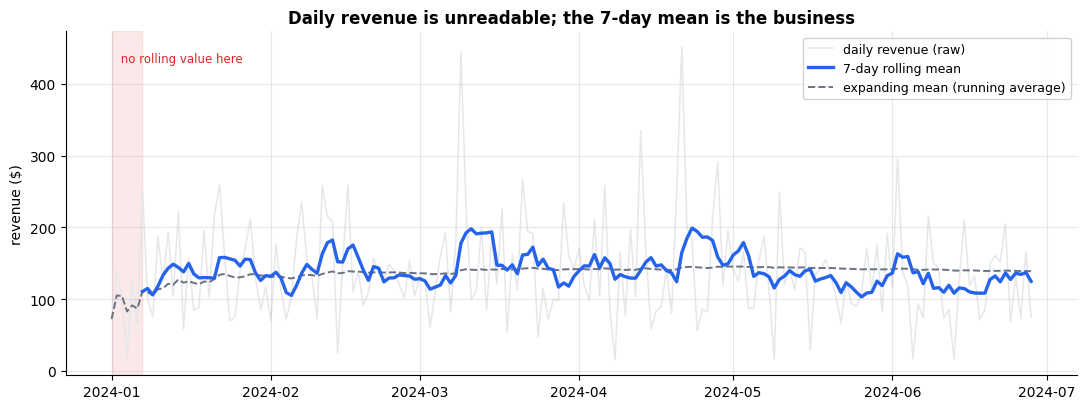

In [ ]:
roll7   = daily.rolling(7).mean()                    # default: needs all 7
roll7mp = daily.rolling(7, min_periods=1).mean()     # emit from row 1
roll7c  = daily.rolling(7, center=True).mean()       # stamp at window centre
expand  = daily.expanding().mean()                   # running mean from the start

print("First 8 days, four ways of smoothing:")
print(pd.DataFrame({"revenue": daily, "rolling(7)": roll7,
                    "min_periods=1": roll7mp, "center=True": roll7c,
                    "expanding()": expand}).head(8).round(2).to_string())

print(f"\nNaNs:  rolling(7)={roll7.isna().sum()}   "
      f"min_periods=1={roll7mp.isna().sum()}   center=True={roll7c.isna().sum()}")
print(f"first real value: rolling(7) at {roll7.first_valid_index():%Y-%m-%d}, "
      f"center=True at {roll7c.first_valid_index():%Y-%m-%d}")
print(f"center=True also loses the END: last real value "
      f"{roll7c.last_valid_index():%Y-%m-%d} vs {roll7.last_valid_index():%Y-%m-%d}")
print(f"\nexpanding().mean() converges to the overall mean: "
      f"{expand.iloc[-1]:.2f} == {daily.mean():.2f}")

# ---------------------------------------------------------------- FIGURE 1
fig, ax = plt.subplots(figsize=(11, 4.2))
ax.plot(daily.index, daily.values, color=C_SOFT, lw=1.1, zorder=1,
        label="daily revenue (raw)")
ax.plot(daily.index, daily.rolling(7).mean(), color=C_DATA, lw=2.4, zorder=3,
        label="7-day rolling mean")
ax.plot(daily.index, daily.expanding().mean(), color=C_GREY, lw=1.4, ls="--",
        zorder=2, label="expanding mean (running average)")
ax.axvspan(daily.index[0], roll7.first_valid_index(), color=C_NA, alpha=0.10,
           zorder=0)
ax.text(daily.index[1], ax.get_ylim()[1] * 0.94, " no rolling value here",
        color=C_NA, fontsize=8.5, va="top")
ax.set_title("Daily revenue is unreadable; the 7-day mean is the business",
             fontsize=12, weight="bold")
ax.set_ylabel(r"revenue (\$)")
ax.set_xlabel("")
ax.legend(loc="upper right", framealpha=0.9, fontsize=9)
plt.tight_layout(); plt.show()


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

The grey line is what the data actually looks like: a saw edge that spikes every seventh day and swings wildly in between. Nobody can read a trend off it, and nobody should try. The blue line is the same series under a 7-day rolling mean — the weekly cycle cancels because a 7-day window holds one of every weekday, and what is left is the shape of the business over six months. The dashed grey line is the expanding mean, which starts jumpy (early on it is averaging very few days) and then flattens as each new day counts for less; the printed value confirms it lands exactly on the overall mean.

The red band at the left is the point of the printed table. `rolling(7)` emits nothing until it has seen seven values, so the blue line does not start where the grey one does. `min_periods=1` fills that band in by averaging whatever is available; `center=True` moves the loss to *both* ends, as the printed first and last valid dates show, in exchange for the smoothed line no longer lagging the raw one by half a window.

**The common misread:** reading the left-hand end of a rolling mean as a real dip or a slow start. There is no line there at all, and if you smoothed with `min_periods=1` there *is* a line but its first few points are averages of one, two and three days — as noisy as the raw series while looking exactly as smooth as the rest of the curve. That is worse than the gap.

</div>

<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ The trap

**The failure:**

```python
df['ma7'] = df['revenue'].rolling(7).mean()
df['ma7'].sum()          # quietly ignores 6 days
df['ma7'].plot()         # line starts a week late; nobody notices
model.fit(df[['ma7']])   # ValueError: Input contains NaN  <- a week later
```

`rolling(w)` produces `NaN` for the first `w - 1` rows, always, because those windows are not full. The cell above prints the exact count for this series. Three consequences, in increasing order of how long they take to find:

- **A plot silently starts late.** Matplotlib skips `NaN` without a word, so the smoothed line just begins partway across the axes and looks deliberate.
- **Aggregations silently shrink.** `.sum()` and `.mean()` skip `NaN` by default, so a rolling column and a raw column in the same frame are summarised over different numbers of rows.
- **A model blows up much later.** scikit-learn will not accept `NaN`, and the traceback points at `fit`, not at the `rolling` call that caused it.

Pick one deliberately: `min_periods=1` to accept unstable early values, `.dropna()` to accept a shorter series, or leave the `NaN` and remember it is there. What you must not do is leave it there *by accident*, which is the default outcome.

</div>

## 8.4 `shift`, `diff`, `pct_change`: comparing a row to another row

Everything so far summarised the series. These three compare it to *itself*, offset in time.

- **`.shift(n)`** slides the values down by `n` rows, leaving `NaN` at the top. It is the primitive; the other two are built on it.
- **`.diff(n)`** is `s - s.shift(n)` — the absolute change.
- **`.pct_change(n)`** is `s / s.shift(n) - 1` — the relative change.

The interesting argument is `n`, and for daily retail data the obvious choice is wrong. `diff(1)` compares today to yesterday, and for this dataset that mostly measures **what day of the week it is**. Saturday beats Friday because it is Saturday. Monday collapses because Sunday was Sunday. None of that is news about the business.

`diff(7)` compares today to the same weekday last week, which holds the weekly cycle fixed and lets an actual change show through. The next cell measures both and puts the difference on the table rather than asserting it.


In [ ]:
change = pd.DataFrame({
    "revenue":  daily,
    "prev_day": daily.shift(1),          # shift is the primitive...
    "dod":      daily.diff(1),           # ...and diff is s - s.shift(1)
    "dod_pct":  daily.pct_change(1),
    "wow":      daily.diff(7),           # same weekday, one week back
    "wow_pct":  daily.pct_change(7),
})
print("shift is the primitive -- diff(1) is exactly revenue - prev_day:")
print(change.head(4).round(2).to_string())
print("identical:", change["dod"].equals(change["revenue"] - change["prev_day"]))

# --- why shift(7) and not shift(1), measured -------------------------------
ORDER = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday",
         "Saturday", "Sunday"]
change["weekday"] = daily.index.day_name()
by_day = change.groupby("weekday")[["dod", "wow"]].mean().reindex(ORDER).round(2)
print("\nMean change, split by weekday:")
print(by_day.to_string())

print(f"\nspread (std) of those seven weekday means:"
      f"   diff(1) = {by_day['dod'].std():.2f}   diff(7) = {by_day['wow'].std():.2f}")
print(f"diff(1) carries {by_day['dod'].std() / by_day['wow'].std():.1f}x more "
      f"weekday structure than diff(7).")
print(f"worst offenders: {by_day['dod'].idxmin()} averages "
      f"{by_day['dod'].min():+.2f}, {by_day['dod'].idxmax()} averages "
      f"{by_day['dod'].max():+.2f} -- pure calendar, no business content.")
print(f"\nNote the noise floor is NOT much lower: std of the change itself is "
      f"{change['dod'].std():.2f} for diff(1) vs {change['wow'].std():.2f} for "
      f"diff(7).\nshift(7) removes the weekly BIAS, not the day-to-day variance.")


shift is the primitive -- diff(1) is exactly revenue - prev_day:
            revenue  prev_day    dod  dod_pct  wow  wow_pct
date                                                       
2024-01-01    72.50       NaN    NaN      NaN  NaN      NaN
2024-01-02   137.75     72.50  65.25     0.90  NaN      NaN
2024-01-03   103.75    137.75 -34.00    -0.25  NaN      NaN
2024-01-04    17.50    103.75 -86.25    -0.83  NaN      NaN
identical: True

Mean change, split by weekday:
             dod   wow
weekday               
Monday    -60.52  2.32
Tuesday    13.12 -0.96
Wednesday -17.62  0.87
Thursday   -3.25  4.01
Friday     39.16 -0.93
Saturday   11.05  3.41
Sunday     14.46 -4.73

spread (std) of those seven weekday means:   diff(1) = 31.67   diff(7) = 3.05
diff(1) carries 10.4x more weekday structure than diff(7).
worst offenders: Monday averages -60.52, Friday averages +39.16 -- pure calendar, no business content.

Note the noise floor is NOT much lower: std of the change itself is 94.52 for 

<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

The top block proves `diff(1)` is literally `revenue - prev_day` — `.equals` returns `True` — so `shift` really is the primitive and `diff` and `pct_change` are conveniences over it. Note the `NaN` in the first row of every derived column: there is no previous day for the first day.

The weekday table is the argument. Under `diff(1)`, each weekday has a large characteristic mean — one weekday averages a big negative number and another a big positive one, as the printed "worst offenders" line names — and those numbers are telling you nothing except which day of the week it is. Under `diff(7)` the same seven means sit close to zero, and the printed spread ratio quantifies the difference. That is what "holding the weekly cycle fixed" means in practice.

**The common misread:** expecting `shift(7)` to make the series quiet. It does not, and the last printed pair says so: the standard deviation of the week-over-week change is barely below the day-over-day one. With only a handful of orders a day, most of the variance here is small-count randomness, and no amount of shifting removes that. `shift(7)` removes the systematic weekday *bias* — which is what would otherwise make you report "Mondays are down" as a finding — and leaves the noise exactly where it was.

</div>

<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ The trap

**The failure — run it and look at the output:**

```python
shuffled = daily.sample(frac=1, random_state=0)   # same rows, wrong order
shuffled.diff().head()
```

```
date
2024-05-18      NaN
2024-01-08    -39.5     <- 'change since yesterday' between MAY and JANUARY
2024-05-05    -13.5
2024-03-13    112.0
```

`.diff()`, `.shift()`, `.rolling()` and `.pct_change()` all work on **row position**, not on the index. They do not sort, they do not check, and they do not warn. On an unsorted index they cheerfully subtract January from May and label the result a daily change.

What makes this genuinely dangerous is that the wreckage is not obviously wrong. The next cell computes the mean absolute `diff()` for the sorted and shuffled versions of the very same data; the two numbers are close enough that no plot, no summary statistic and no reviewer would flinch. You get a plausible number that means nothing.

And the surrounding API is inconsistent about it, which is why the habit has to be yours rather than the library's:

| operation | on an unsorted DatetimeIndex |
|---|---|
| `.resample()` | **sorts internally** — correct answer |
| `.asfreq()` | **reindexes** — correct answer |
| `.loc['2024-03']` | works |
| `.loc['2024-02':'2024-04']` | **raises** `KeyError` |
| `.diff()`, `.shift()`, `.rolling()` | **silently wrong** |

`df.sort_index()` immediately after you build a time-indexed frame, and `assert df.index.is_monotonic_increasing` before anything positional. A `merge`, a `concat`, a `groupby(sort=False)` or a `sample` is all it takes to lose the ordering.

</div>

In [ ]:
# The gotcha above, executed -- because the point is that it does NOT look wrong.
shuffled = daily.sample(frac=1, random_state=0)

print("index sorted?   daily:", daily.index.is_monotonic_increasing,
      "   shuffled:", shuffled.index.is_monotonic_increasing)
print("\nshuffled.diff().head(4) -- 'daily changes' across months:")
print(shuffled.diff().head(4).round(2).to_string())

print(f"\nmean |diff|   sorted: {daily.diff().abs().mean():.2f}"
      f"    shuffled: {shuffled.diff().abs().mean():.2f}")
print("Two summary numbers of the same magnitude. One is meaningful.")
print("\nAnd for contrast, the operations that DO defend themselves:")
print(f"  resample('W').sum() equal on both? "
      f"{daily.resample('W').sum().equals(shuffled.resample('W').sum())}")
print(f"  asfreq('D')         equal on both? "
      f"{daily.asfreq('D').equals(shuffled.asfreq('D'))}")
try:
    shuffled.loc["2024-02":"2024-04"]
except KeyError as e:
    print(f"  loc['2024-02':'2024-04'] on the shuffled index -> "
          f"KeyError: {str(e)[:72]}...")


index sorted?   daily: True    shuffled: False

shuffled.diff().head(4) -- 'daily changes' across months:
date
2024-05-18      NaN
2024-01-08    -39.5
2024-05-05    -13.5
2024-03-13    112.0

mean |diff|   sorted: 75.90    shuffled: 71.84
Two summary numbers of the same magnitude. One is meaningful.

And for contrast, the operations that DO defend themselves:
  resample('W').sum() equal on both? True
  asfreq('D')         equal on both? True
  loc['2024-02':'2024-04'] on the shuffled index -> KeyError: 'Value based partial slicing on non-monotonic DatetimeIndexes with non-e...


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

The shuffled `diff()` head, printed so you can see the dates: consecutive output rows are months apart, and the column is still called a daily change. Then the two mean-absolute-difference numbers — the sorted one and the meaningless one — sitting side by side at the same order of magnitude. That similarity is the whole lesson. A corrupted `diff` does not produce infinities or nulls or a suspicious spike; it produces a number that passes every eyeball test you have.

The bottom block confirms the split in the API. `resample` and `asfreq` return byte-identical results on the sorted and shuffled series, because both build their own index and place data into it. `.loc` with a range of partial strings raises rather than guess. Only the positional family — `diff`, `shift`, `rolling`, `pct_change` — proceeds without checking.

**The common misread:** concluding that pandas will protect you because two of the five things here did. The two that defend themselves do so as a side effect of how they are implemented, not as a safety feature, and the three that do not are the three you reach for most often. `is_monotonic_increasing` is one attribute lookup; check it.

</div>

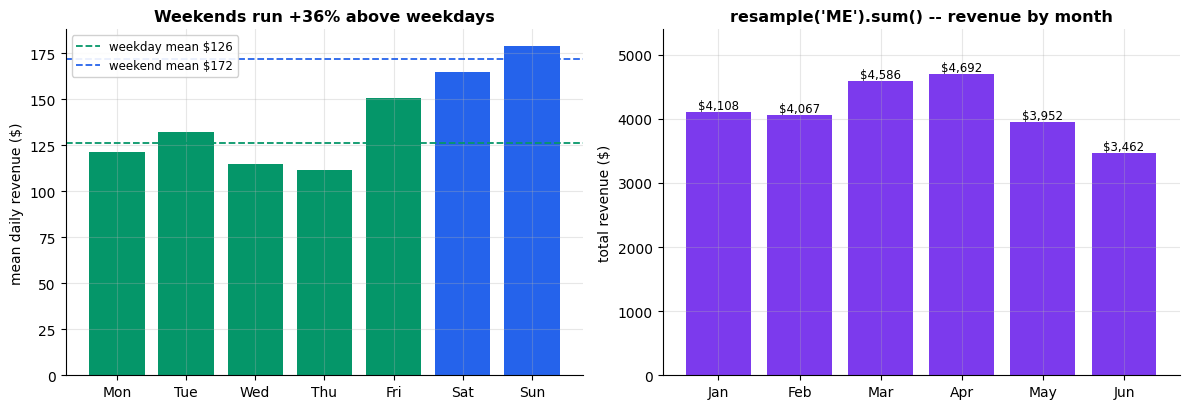

weekday mean 126.14   weekend mean 171.91   ratio 1.363  (lift +36.3%)
days: 129 weekday, 50 weekend

month totals from resample('ME').sum():
date
2024-01-31    4108.00
2024-02-29    4066.75
2024-03-31    4586.50
2024-04-30    4691.75
2024-05-31    3952.25
2024-06-30    3462.00
Freq: ME

days counted per month (watch for a short one):
  Jan 31   Feb 29   Mar 30   Apr 30   May 31   Jun 28


In [ ]:
# ---------------------------------------------------------------- FIGURE 2
prof = daily.groupby(daily.index.dayofweek).mean()
prof.index = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
is_weekend = daily.index.dayofweek >= 5
we, wd = daily[is_weekend].mean(), daily[~is_weekend].mean()
lift = we / wd - 1

monthly = daily.resample("ME").sum()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.2))

bars = ax1.bar(prof.index, prof.values,
               color=[C_GROUP if d < 5 else C_DATA for d in range(7)])
ax1.axhline(wd, color=C_GROUP, ls="--", lw=1.3,
            label=rf"weekday mean \${wd:,.0f}")
ax1.axhline(we, color=C_DATA, ls="--", lw=1.3,
            label=rf"weekend mean \${we:,.0f}")
ax1.set_title(f"Weekends run {lift:+.0%} above weekdays", fontsize=11.5,
              weight="bold")
ax1.set_ylabel(r"mean daily revenue (\$)")
ax1.legend(fontsize=8.5, loc="upper left", framealpha=0.9)

ax2.bar([f"{d:%b}" for d in monthly.index], monthly.values, color=C_IDX)
for x, v in enumerate(monthly.values):
    ax2.text(x, v, rf"\${v:,.0f}", ha="center", va="bottom", fontsize=8.5)
ax2.set_title("resample('ME').sum() -- revenue by month", fontsize=11.5,
              weight="bold")
ax2.set_ylabel(r"total revenue (\$)")
ax2.set_ylim(0, monthly.max() * 1.15)

plt.tight_layout(); plt.show()

print(f"weekday mean {wd:,.2f}   weekend mean {we:,.2f}   "
      f"ratio {we / wd:.3f}  (lift {lift:+.1%})")
print(f"days: {(~is_weekend).sum()} weekday, {is_weekend.sum()} weekend")
print(f"\nmonth totals from resample('ME').sum():")
print(monthly.round(2).to_string())
counts = daily.resample("ME").count()
print("\ndays counted per month (watch for a short one):")
print("  " + "   ".join(f"{d:%b} {n}" for d, n in counts.items()))


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Left: mean daily revenue by weekday, with the two dashed lines giving the weekday and weekend averages and the title carrying the measured lift. The weekend effect is real and it is in the title, computed in this cell — Saturday and Sunday sit clearly above the weekday block, and the two dashed lines are far enough apart that it is not a rendering artefact. This is the signal that made the raw line in Figure 1 unreadable, and the reason a 7-day window is the right smoother for this series rather than a 5- or 10-day one.

Right: `resample('ME').sum()` as a bar per month, each labelled with its total. Below the figure, `resample('ME').count()` prints how many days went into each of those bars — deliberately, because of the trap two sections back. The first and last months of any range are the ones to check: a dataset that starts mid-month or ends mid-month produces a short bar that means "fewer days", not "worse month".

**The common misread:** reading the last month's bar as a decline. Compare it against the printed day counts before you say anything about it. A partial month is shorter for calendar reasons, and it is the single most common way a monthly bar chart tells a story that is not in the data.

</div>

In [ ]:
# ============================================================
#  Time zones: naive vs aware, in sixty seconds
# ============================================================
naive = daily.tail(3)
print(f"naive index tz: {naive.index.tz}      dtype: {naive.index.dtype}")

# tz_localize: ATTACH a zone. The clock times do not move.
la = naive.tz_localize("America/Los_Angeles")
print(f"\ntz_localize('America/Los_Angeles') -- same wall clock, now anchored:")
print(la.index)

# tz_convert: RE-EXPRESS the same instants in another zone. The instants
# do not move; the clock times do.
print(f"\ntz_convert('UTC') -- same instants, different clock:")
print(la.tz_convert("UTC").index)

# Using the wrong one of the two is an error, not a silent mistake:
for label, fn in [("tz_convert on a NAIVE index", lambda: naive.tz_convert("UTC")),
                  ("tz_localize on an AWARE index", lambda: la.tz_localize("UTC"))]:
    try:
        fn()
    except TypeError as e:
        print(f"\n{label}\n  -> TypeError: {e}")

# ...but a naive timestamp that does not exist IS a real-world bug:
try:
    pd.Series([1]).set_axis(pd.to_datetime(["2024-03-10 02:30"])) \
                  .tz_localize("America/Los_Angeles")
except Exception as e:
    print(f"\n2024-03-10 02:30 in Los Angeles\n  -> {type(e).__name__}: "
          f"{str(e)[:96]}...")


naive index tz: None      dtype: datetime64[ns]

tz_localize('America/Los_Angeles') -- same wall clock, now anchored:
DatetimeIndex(['2024-06-26 00:00:00-07:00', '2024-06-27 00:00:00-07:00',
               '2024-06-28 00:00:00-07:00'],
              dtype='datetime64[ns, America/Los_Angeles]', name='date', freq=None)

tz_convert('UTC') -- same instants, different clock:
DatetimeIndex(['2024-06-26 07:00:00+00:00', '2024-06-27 07:00:00+00:00',
               '2024-06-28 07:00:00+00:00'],
              dtype='datetime64[ns, UTC]', name='date', freq=None)

tz_convert on a NAIVE index
  -> TypeError: Cannot convert tz-naive timestamps, use tz_localize to localize

tz_localize on an AWARE index
  -> TypeError: Already tz-aware, use tz_convert to convert.

2024-03-10 02:30 in Los Angeles
  -> NonExistentTimeError: 2024-03-10 02:30:00...


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

A naive index (`tz` is `None`) put through both operations. `tz_localize` *attaches* a zone: the printed clock times are unchanged, but a UTC offset has appeared, so these timestamps now name real instants instead of ambiguous wall-clock readings. `tz_convert` then *re-expresses* those same instants in another zone: the offset and the printed times change together, and no moment has moved.

The two `TypeError`s are pandas refusing to guess — you cannot convert something that has no zone, and you cannot localize something that already has one. The last block is the reason any of this matters: `2024-03-10 02:30` is a timestamp that **never happened** in Los Angeles, because the clocks jumped from 02:00 to 03:00 that morning. It parses perfectly as a naive timestamp. It only becomes an error at the moment you attach a real zone to it.

**The common misread:** treating naive timestamps as safe because they have never caused you a problem. A naive timestamp is not "in UTC" and not "in local time" — it is a clock reading with the zone thrown away, and it compares, sorts, joins and subtracts against other naive timestamps without complaint whether or not they came from the same zone. The bug surfaces as an off-by-a-few-hours in a join, or one duplicated hour and one missing hour per year, and by then it is in the warehouse. Localize at the boundary where data enters, store UTC, convert to local only for display.

</div>

---

## 🎓 Part 8 in one page

| You wanted | You write | Watch out for |
|---|---|---|
| A month, a range of months | `df.loc['2024-03']`, `df.loc['2024-02':'2024-04']` | Endpoint is **inclusive of the whole period**; needs a sorted index for ranges |
| Roll up to weeks / months | `.resample('W')`, `.resample('ME')`, `.resample('MS')` | `'M'`, `'Q'`, `'Y'`, `'H'`, `'T'`, `'S'` were **removed** in pandas 3 |
| More than one answer per bin | `.resample('W').agg(['sum', 'count'])` | Carry `count` whenever you report a `sum` |
| A finer frequency | `.resample('12h')` then `ffill` / `bfill` / `interpolate` | Filling *invents* data; for a flow like revenue, `0` is often correct |
| The trend under the noise | `.rolling(7).mean()`, `.expanding()` | First `w-1` rows are `NaN`; `center=True` loses both ends |
| Today vs yesterday / last week | `.diff(1)`, `.diff(7)`, `.pct_change()` | Positional — **silently wrong** on an unsorted index |
| Whether a day is missing | `.asfreq('D')` | A gap is invisible until you ask; a `sum` over it is quietly low |
| A real instant | `tz_localize` then `tz_convert` | Naive timestamps compare fine and mean nothing |

**The three habits worth keeping**, because each one costs a line and prevents a category of wrong answer:

1. `sort_index()` when you build a time-indexed frame, and `is_monotonic_increasing` before anything positional.
2. `asfreq()` once, early, on any series you believe is regular. Look at the `NaN` count.
3. `.agg(['sum', 'count'])` instead of `.sum()` for anything that leaves your notebook.

---

## ➡️ Part 9: plotting, performance, and the capstone

Figure 1 in this part was written out longhand with `plt.subplots` and two `ax.plot` calls. It did not have to be — `daily.plot()` would have produced most of it, because pandas has plotting built in and it already knows the index is time. Part 9 starts there.

Then the other half: **why your code is slow.** Every operation in Parts 5 through 8 was vectorised, and that was not a stylistic preference. Part 9 measures the difference between a `for` loop over rows, `.apply()`, and a vectorised expression on this exact dataset, and shows the memory tricks — categoricals, downcast dtypes — that make the difference between a frame that fits in RAM and one that does not.

And then the capstone puts all ten parts on one question: load the raw `sales` frame, clean it, reshape it, resample it, and answer the store manager from Part 0 — which product sells best on weekends, by region, excluding the double-scanned days.

---


---

# 9️⃣ Plotting, performance, and a capstone

## The last three things between you and being dangerous with pandas

Eight parts in, you can clean, select, transform, group, reshape and resample.
What is left is the part nobody teaches, because it is not an API — it is
judgement:

1. **Plotting.** `df.plot()` is one method call and covers most of what you
   need. Knowing *where it stops* is worth more than knowing every keyword it
   takes.
2. **Performance.** Almost every slow pandas script is slow for one of a few
   reasons, and every one of them is measurable. We will measure them rather
   than assert them — including the case where the speedup turns out to be
   smaller than the folklore promised, or negative.
3. **The capstone.** Part 0 opened with a store manager's question: *which
   product sells best on weekends, by region, excluding the days the till was
   double-scanned?* We said it was four lines. We are going to write them —
   from the **raw** frame, in one chain — and then take the chain apart line by
   line.

Sections 9.1 and 9.2 work on `tidy`, the frame Part 5 left behind. Section 9.3
goes back to `sales` and rebuilds the whole road in a single expression, which
is the only real proof that the eight parts compose.


## 9.1 `.plot()` and its `kind=` family

`.plot()` is a thin, well-behaved wrapper over matplotlib. Two facts explain
almost all of its behaviour:

- **The index is the x-axis.** For every `kind` except `scatter` and `hexbin`,
  pandas plots values against the index. Half of "why does my chart look like
  that" is an index you did not mean to plot against.
- **Each column is a series.** A DataFrame with four columns gives you four
  lines, four bar groups, four stacked areas — and a legend, for free.

It returns the matplotlib `Axes` (or an array of them), so `ax = df.plot(...)`
hands you the full matplotlib API for anything pandas does not expose. Start
with the simplest case: one Series, one call.


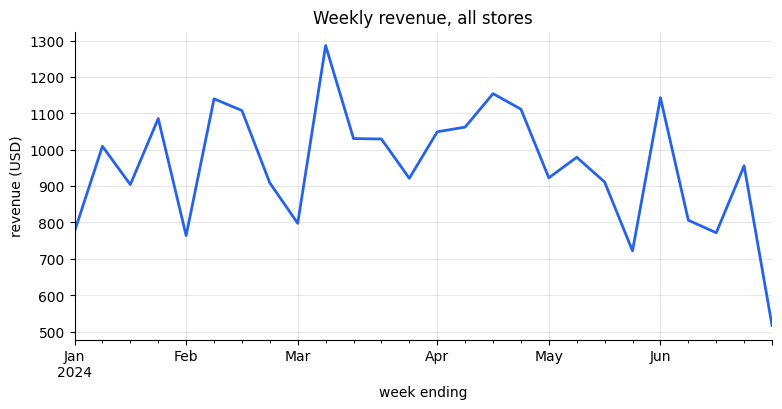

26 weekly buckets, 2024-01-07 to 2024-06-30
last bucket covers 5 days of data, not 7


In [ ]:
import time, tempfile, os

# The whole chart. No matplotlib call of our own except plt.show().
p9_weekly = tidy.set_index("date")["revenue"].resample("W").sum()

ax = p9_weekly.plot(color=C_DATA, lw=2, title="Weekly revenue, all stores")
ax.set_xlabel("week ending")
ax.set_ylabel("revenue (USD)")
plt.show()

print(f"{len(p9_weekly)} weekly buckets, "
      f"{p9_weekly.index.min().date()} to {p9_weekly.index.max().date()}")
print(f"last bucket covers "
      f"{(tidy['date'].max() - p9_weekly.index[-2]).days} days of data, "
      f"not 7")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

A line chart from a single method call — no `plt.plot`, no axis construction, and the x-axis is already dated. That is the resample doing the work: `Series.plot()` takes the **index** as x and the values as y, so putting the dates in the index was the entire setup. The line wanders without much of a trend and then drops off a cliff at the right-hand edge.

**The common misread:** reading that final cliff as a collapse in sales. It is a truncated bucket, and the line printed underneath says how many days it actually covers. `resample` emits a bin for the last partial period whether or not the period finished, so every resampled series you ever plot ends with one. Check the bin edges before you write the word *decline* in a report.

</div>

/tmp/ipykernel_11031/4170237732.py:3: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  p9_monthly    = tidy.pivot_table(index=pd.Grouper(key="date", freq="ME"),


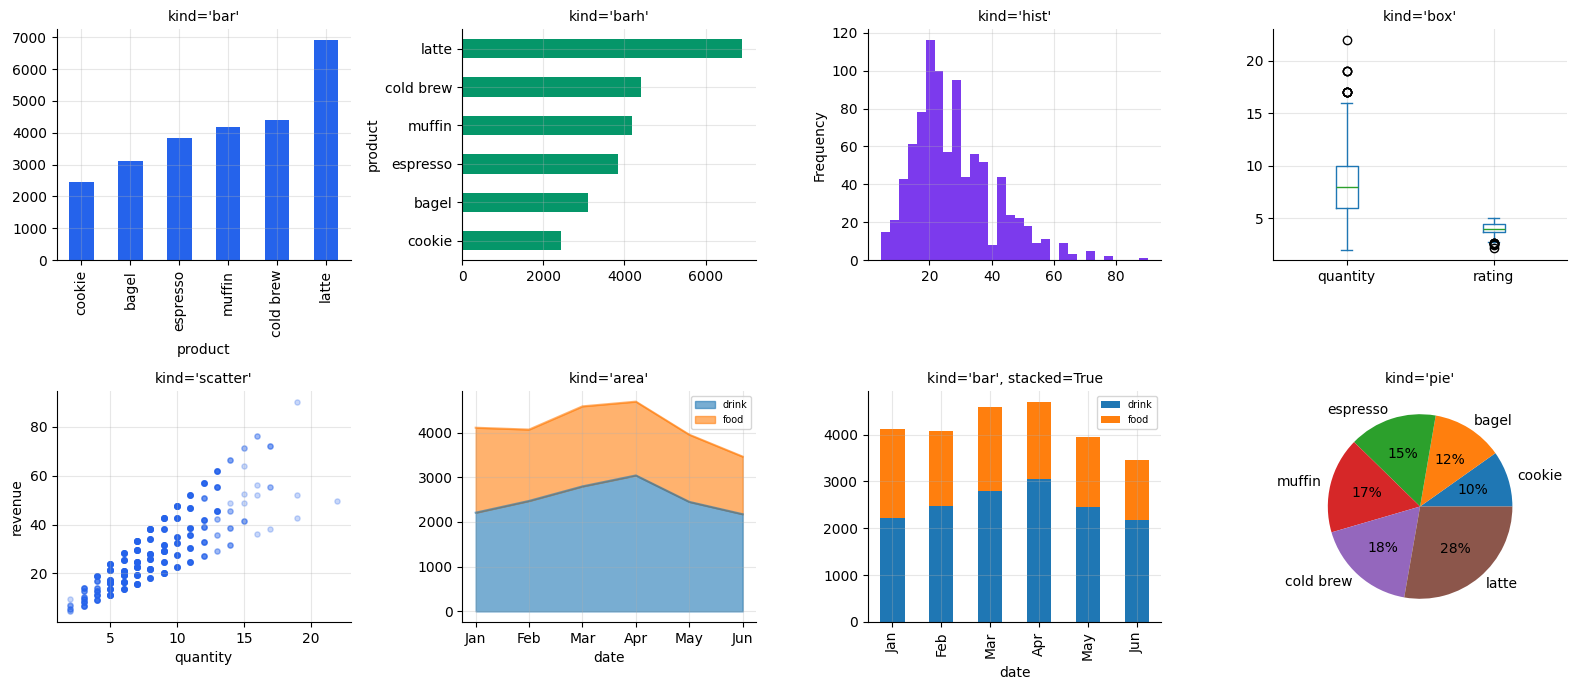

In [ ]:
# ---- one figure, eight kinds -----------------------------------------------
p9_by_product = tidy.groupby("product")["revenue"].sum().sort_values()
p9_monthly    = tidy.pivot_table(index=pd.Grouper(key="date", freq="ME"),
                                 columns="category", values="revenue",
                                 aggfunc="sum")
p9_monthly.index = p9_monthly.index.strftime("%b")     # short month labels

fig, axes = plt.subplots(2, 4, figsize=(16, 7))

p9_by_product.plot(kind="bar",  ax=axes[0, 0], color=C_DATA,  title="kind='bar'")
p9_by_product.plot(kind="barh", ax=axes[0, 1], color=C_GROUP, title="kind='barh'")
tidy["revenue"].plot(kind="hist", bins=30, ax=axes[0, 2], color=C_IDX,
                     title="kind='hist'")
tidy[["quantity", "rating"]].plot(kind="box", ax=axes[0, 3], title="kind='box'")

tidy.plot(kind="scatter", x="quantity", y="revenue", alpha=0.25, s=14,
          color=C_DATA, ax=axes[1, 0], title="kind='scatter'")
p9_monthly.plot(kind="area", alpha=0.6, ax=axes[1, 1], title="kind='area'")
p9_monthly.plot(kind="bar", stacked=True, ax=axes[1, 2],
                title="kind='bar', stacked=True")
p9_by_product.plot(kind="pie", ax=axes[1, 3], autopct="%1.0f%%",
                   ylabel="", title="kind='pie'")
axes[1, 3].grid(False)

for ax in axes.flat:
    ax.title.set_fontsize(10)
    if ax.get_legend() is not None:
        ax.legend(fontsize=7)
plt.tight_layout()
plt.show()


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Eight `kind=` values on the same data, so you can see what each one is *for* rather than what it looks like. `bar` and `barh` show identical numbers, and `barh` is the readable one whenever the labels are words. `hist` shows the shape of one column: revenue is right-skewed — many small orders, a long thin tail of large ones. `box` compares spreads, and also demonstrates its own misuse: `quantity` and `rating` do not share units, so the box plot squashes one against the axis. `scatter` is the one kind that needs `x=` and `y=`, because it is the one kind that does **not** use the index. `area` and `stacked=True` show composition over time; `pie` shows composition at a single instant.

**The common misread:** treating the stacked area and the stacked bar as interchangeable. The area chart implies the x-axis is continuous and that the values between month labels mean something; the bar chart says the months are six separate buckets. Both readings are defensible for months. Neither is defensible for revenue by store, and only the bar chart makes that obvious.

</div>

<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ The trap

**Failure first.** You call `tidy.plot(kind='bar')` on the whole frame and get one bar per order, an unreadable x-axis, and a legend covering the plot.

Nothing went wrong. `kind='bar'` draws one bar per **index entry**, and the index is the row number, so you asked for one bar per row and got it. The fix is never a plotting keyword — it is to aggregate first, so that the index becomes the thing you want on the x-axis:

```python
tidy.groupby('product')['revenue'].sum().plot(kind='bar')
```

Say it as a rule: **if the chart looks wrong, the index is wrong.** `kind='pie'` has the same failure mode and is worse, because a pie of hundreds of slices renders as a solid coloured disc and looks deliberate.

</div>

/tmp/ipykernel_11031/1932509731.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  (tidy.groupby("region")["revenue"].sum().sort_values()


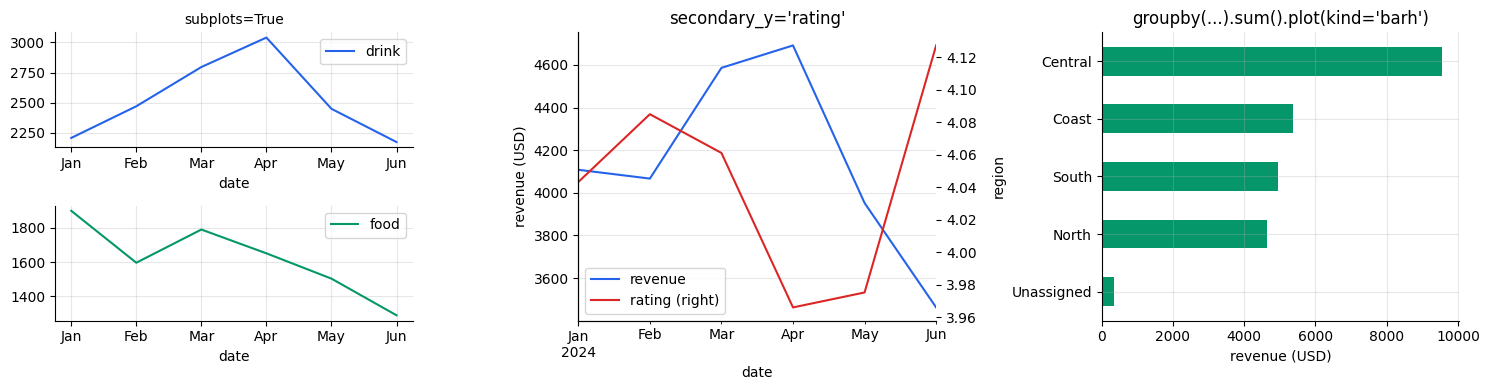

monthly revenue and mean rating, the two lines in the middle panel:
            revenue  rating
date                       
2024-01-31  4108.00    4.04
2024-02-29  4066.75    4.08
2024-03-31  4586.50    4.06
2024-04-30  4691.75    3.97
2024-05-31  3952.25    3.98
2024-06-30  3462.00    4.13


In [ ]:
# ---- three keywords that save you from writing matplotlib -------------------
p9_by_month = (tidy.set_index("date")
                   .resample("ME")
                   .agg(revenue=("revenue", "sum"), rating=("rating", "mean")))

fig = plt.figure(figsize=(15, 4))

# (a) subplots=True -- one panel per column, shared x-axis, no loop
ax_a = [fig.add_subplot(2, 3, 1), fig.add_subplot(2, 3, 4)]
p9_monthly[["drink", "food"]].plot(subplots=True, ax=ax_a, legend=True,
                                   color=[C_DATA, C_GROUP])
ax_a[0].set_title("subplots=True", fontsize=10)

# (b) secondary_y -- two columns, incompatible units, one panel
ax_b = fig.add_subplot(1, 3, 2)
p9_by_month.plot(secondary_y="rating", ax=ax_b, color=[C_DATA, C_NA],
                 title="secondary_y='rating'")
ax_b.set_ylabel("revenue (USD)")

# (c) .plot() straight off a groupby result
ax_c = fig.add_subplot(1, 3, 3)
(tidy.groupby("region")["revenue"].sum().sort_values()
     .plot(kind="barh", ax=ax_c, color=C_GROUP,
           title="groupby(...).sum().plot(kind='barh')"))
ax_c.set_xlabel("revenue (USD)")

plt.tight_layout()
plt.show()

print("monthly revenue and mean rating, the two lines in the middle panel:")
print(p9_by_month.round(2))


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Left: `subplots=True` turns a two-column frame into two stacked panels with a shared x-axis — the loop you would otherwise write, as a keyword. Middle: `secondary_y=` puts revenue (thousands of dollars) and mean rating (a number near 4) on one panel with two y-axes, which is the only honest way to draw them together at all. Right: a groupby result is just a Series with a meaningful index, so `.plot()` works on it directly — which is why so much real pandas plotting code is one line ending in `.plot()`. The printed table underneath is the middle panel as numbers: revenue drifts month to month while mean rating barely moves at all — the comparison the eye cannot reliably make from the two lines.

**The common misread:** believing the two lines in a `secondary_y` chart when they appear to track or cross each other. Two independent axes can be slid and stretched at will, so *any* pair of series can be made to look correlated or anti-correlated by the scaling alone. Use it to put two shapes side by side; never to argue that two quantities are related. The table is what settles that question.

</div>

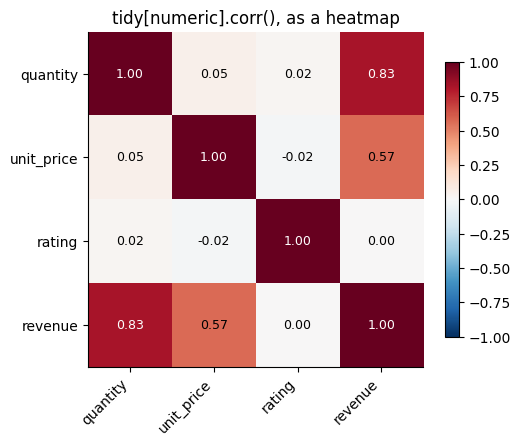

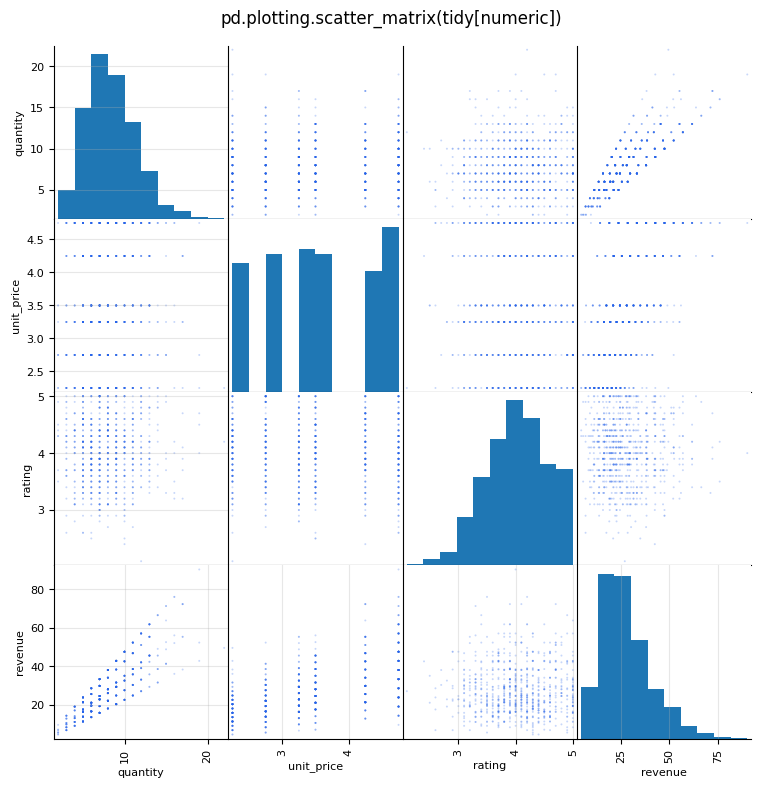

            quantity  unit_price  rating  revenue
quantity       1.000       0.053   0.016    0.826
unit_price     0.053       1.000  -0.018    0.568
rating         0.016      -0.018   1.000    0.004
revenue        0.826       0.568   0.004    1.000


In [ ]:
# ---- looking at every numeric column at once --------------------------------
p9_num  = tidy[["quantity", "unit_price", "rating", "revenue"]]
p9_corr = p9_num.corr()

fig, ax = plt.subplots(figsize=(5.5, 4.5))
im = ax.imshow(p9_corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(p9_corr)), p9_corr.columns, rotation=45, ha="right")
ax.set_yticks(range(len(p9_corr)), p9_corr.index)
for i in range(len(p9_corr)):
    for j in range(len(p9_corr)):
        v = p9_corr.iat[i, j]
        ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=9,
                color="white" if abs(v) > 0.6 else "black")
ax.set_title("tidy[numeric].corr(), as a heatmap")
ax.grid(False)
fig.colorbar(im, ax=ax, shrink=0.82)
plt.tight_layout()
plt.show()

# scatter_matrix builds its own grid of axes, so it gets its own figure
sm = pd.plotting.scatter_matrix(p9_num, figsize=(9, 9), diagonal="hist",
                                alpha=0.25, s=8, color=C_DATA)
for a in sm.flat:
    a.xaxis.label.set_size(8)
    a.yaxis.label.set_size(8)
plt.suptitle("pd.plotting.scatter_matrix(tidy[numeric])", y=0.92)
plt.show()

print(p9_corr.round(3))


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Two views of the same four columns. The heatmap is the summary: `revenue` correlates strongly with `quantity` and moderately with `unit_price`, which is not a discovery — revenue **is** quantity times price, so that corner of the matrix is confirming arithmetic. `rating` correlates with nothing, and *that* is a finding: customers do not rate big orders or expensive items any differently. The scatter matrix is the audit. Look at its `quantity` vs `revenue` panel: the strong correlation is not one cloud, it is **six straight lines**, one per product price. The diagonal shows each column's own distribution, and `unit_price` there is a handful of spikes rather than a curve — the same fact seen from the other side.

**The common misread:** reading a correlation coefficient without the scatter plot. A single number cannot tell one cloud from six lines, and the printed coefficient would have hidden that structure completely. That is why `scatter_matrix` still earns its place even though `.corr()` is quicker to read.

</div>

### When `df.plot()` is enough, and when to drop to matplotlib

**Use `df.plot()` when** you are looking at data rather than publishing it, the
chart carries one message, and the default legend and labels are close enough.
That is most charts you will ever draw — and the one-line form matters more
than it sounds, because it is the difference between actually looking and
deciding it is not worth the trouble.

**Drop to matplotlib when** you need a layout pandas has no keyword for
(annotations, insets, a hand-placed colorbar, panels of different types), when
the figure is going in front of other people, or when you want consistent
styling across a dozen charts. The transition is not a rewrite. `ax =
df.plot(...)` hands you the `Axes`; `fig, axes = plt.subplots(...)` plus
`df.plot(ax=...)` lets you mix both in one figure — which is exactly what the
last three cells did.

**A third option worth knowing:** `df.plot(backend="plotly")` and seaborn both
take a DataFrame directly, for interactive and statistical charts respectively.
Neither is imported here, because a notebook that runs everywhere is worth more
than a notebook with prettier defaults.

---
<div style="background: linear-gradient(135deg, #11998e 0%, #38ef7d 100%); padding: 28px; border-radius: 18px; color: white; margin: 12px 0;">


### 9.2 Performance — measured, not asserted

Every claim below is timed by the cell that makes it. Where the speedup on our
few-hundred-row frame is smaller than the internet promises — or negative — the
cell prints what it actually measured and the text says why the gap widens with
data size, rather than quietly swapping in a bigger benchmark to get a nicer
number.


</div>

In [ ]:
# ---- where do the bytes actually go? ---------------------------------------
p9_text = ["store", "region", "product", "category"]

# the SAME frame, with its four text columns stored three different ways
p9_layouts = {
    "object   (pandas <=2 default)": sales.astype({c: object     for c in p9_text}),
    "str      (pandas 3 default)":   sales,
    "category (what you should do)": sales.astype({c: "category" for c in p9_text}),
}

rows = []
for name, df in p9_layouts.items():
    sh, dp = df.memory_usage(deep=False), df.memory_usage(deep=True)
    rows.append({"layout": name,
                 "shallow KB":    sh.sum() / 1024,
                 "deep KB":       dp.sum() / 1024,
                 "deep/shallow":  dp.sum() / sh.sum(),
                 "text cols, KB": dp[p9_text].sum() / 1024})
p9_mem = pd.DataFrame(rows).set_index("layout").round(2)
print(p9_mem.to_string())

obj_txt = p9_layouts["object   (pandas <=2 default)"].memory_usage(deep=True)[p9_text].sum()
cat_txt = p9_layouts["category (what you should do)"].memory_usage(deep=True)[p9_text].sum()
print(f"\nthe four text columns alone: {obj_txt/1024:.1f} KB as object "
      f"-> {cat_txt/1024:.1f} KB as category  ({obj_txt/cat_txt:.1f}x smaller)")
print("they hold this many distinct values each:")
print("   " + ",  ".join(f"{c}={sales[c].nunique()}" for c in p9_text))

print(f"\ndtype of sales['store'] on THIS pandas: {sales['store'].dtype}")


                               shallow KB  deep KB  deep/shallow  text cols, KB
layout                                                                         
object   (pandas <=2 default)       64.39   359.29          5.58         237.03
str      (pandas 3 default)         64.39   359.29          5.58         237.03
category (what you should do)       40.48   128.49          3.17           6.23

the four text columns alone: 237.0 KB as object -> 6.2 KB as category  (38.1x smaller)
they hold this many distinct values each:
   store=10,  region=4,  product=12,  category=2

dtype of sales['store'] on THIS pandas: object


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

One frame, three text layouts, measured both ways. Read the `deep/shallow` column first, because it is the surprise. Under the legacy **`object`** dtype the two numbers disagree badly: `deep=False` counts one 8-byte pointer per row and stops, `deep=True` follows every pointer and adds the characters — so the shallow figure understates the frame by the factor printed. Under pandas 3's default **`str`** dtype the ratio is `1.00`, because the characters live in one contiguous block that the shallow measurement already sees. Nothing is hidden any more. **`category`** is still the win: the same labels stored once each plus a small integer code per row, and the printed factor is what that is worth on columns with this few distinct values.

**The common misread:** concluding from the `1.00` row that `deep=True` stopped mattering in pandas 3. It matters exactly when a column is `object` — which still happens the moment a column holds mixed types, lists, dicts, `Decimal`s, or anything read in before you set a dtype. `df.info()` also still reports the **shallow** number unless you pass `memory_usage='deep'`, so it will cheerfully tell you an `object` frame is tiny. Part 2 measured the categorical saving on a single column; this is the same lever applied to all four, and the reason to pull it.

</div>

In [ ]:
# ============================================================================
#  Vectorised vs .apply(axis=1) vs .iterrows(), on a ROW-WISE CONDITIONAL.
#  Part 5 timed single-column arithmetic -- the easy case, and the one every
#  tutorial uses. This is the case people genuinely reach for a loop on: a
#  business rule that reads two columns at once and branches.
#
#  The rule: 15% off bulk drink orders; else 10% if the customer rated us
#  4.5 or better; else nothing.
# ============================================================================
def discount_vectorised(df):
    return np.select(
        [(df["category"] == "drink") & (df["quantity"] >= 8),
         df["rating"] >= 4.5],
        [0.15, 0.10],
        default=0.0)

def discount_apply(df):
    def rule(row):
        if row["category"] == "drink" and row["quantity"] >= 8:
            return 0.15
        return 0.10 if row["rating"] >= 4.5 else 0.0
    return df.apply(rule, axis=1).to_numpy()

def discount_iterrows(df):
    out = []
    for _, row in df.iterrows():
        if row["category"] == "drink" and row["quantity"] >= 8:
            out.append(0.15)
        elif row["rating"] >= 4.5:
            out.append(0.10)
        else:
            out.append(0.0)
    return np.array(out)

def p9_timeit(fn, df, repeats):
    fn(df)                                  # warm up; never time the first call
    t0 = time.perf_counter()
    for _ in range(repeats):
        result = fn(df)
    return (time.perf_counter() - t0) / repeats, result

t9_vec, r9_vec = p9_timeit(discount_vectorised, tidy, 30)
t9_app, r9_app = p9_timeit(discount_apply,      tidy, 5)
t9_itr, r9_itr = p9_timeit(discount_iterrows,   tidy, 5)

# If the three do not agree, the benchmark is meaningless.
assert np.allclose(r9_vec, r9_app, equal_nan=True), "apply disagrees"
assert np.allclose(r9_vec, r9_itr, equal_nan=True), "iterrows disagrees"

print(f"{len(tidy)} rows; all three produce identical output\n")
for name, t in [("np.select  (vectorised)", t9_vec),
                (".apply(axis=1)",          t9_app),
                (".iterrows() loop",        t9_itr)]:
    print(f"  {name:<24} {t*1e3:8.3f} ms")
print()
print(f"  vectorised vs .apply(axis=1) : {t9_app/t9_vec:6.1f}x faster")
print(f"  vectorised vs .iterrows()    : {t9_itr/t9_vec:6.1f}x faster")
print(f"\nper row: the loop costs {t9_itr/len(tidy)*1e6:6.2f} microseconds, "
      f"np.select costs {t9_vec/len(tidy)*1e6:.3f}")


894 rows; all three produce identical output

  np.select  (vectorised)     0.507 ms
  .apply(axis=1)              8.178 ms
  .iterrows() loop           44.452 ms

  vectorised vs .apply(axis=1) :   16.1x faster
  vectorised vs .iterrows()    :   87.6x faster

per row: the loop costs  49.72 microseconds, np.select costs 0.567


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Three implementations of one business rule, proved identical by the two `assert`s before anything is compared — timing two programs that compute different answers is worthless. The ratios are the lesson. `np.select` evaluates two boolean arrays over every row in compiled code and picks between two constants. `.apply(axis=1)` constructs a Series object **per row**, hands it to a Python function, and reassembles the results. `.iterrows()` does the same and adds a Python-level loop on top. The last line converts the totals to a per-row cost, which is the number that actually travels.

**The common misread:** seeing a handful of milliseconds and concluding it does not matter. At this size it does not. But the per-row costs are roughly constant, so the *same ratios* hold at a thousand times the rows — where the loop's milliseconds become seconds and the vectorised version is still imperceptible. You are not measuring this frame; you are measuring the slope.

</div>

<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ The trap

**Failure first.** You loop with `.iterrows()`, read `row['quantity']`, compare it to an integer — and either the comparison behaves oddly, or a column that was `int64` comes back as a float, or a number comes back as a string.

`.iterrows()` yields each row as a **Series**, and a Series has exactly one dtype. A row that mixes text and numbers therefore arrives as `object`, every number in it boxed into a Python object; a row of mixed ints and floats arrives as all floats. The row is also a **copy**, so assigning into it silently does nothing to the frame — the classic "my loop ran and changed nothing" bug.

If you truly must iterate, `.itertuples()` is faster and keeps one dtype per field. But the honest fix is the cell above: express the rule with `np.select`, `np.where`, `.mask()` or a `groupby`, and there is no row to iterate over in the first place.

</div>

In [ ]:
# ---- df.eval() and df.query(): worth it at size, and only sometimes --------
try:
    import numexpr
    ENGINE, HAVE_NE = f"numexpr {numexpr.__version__} IS installed", True
except ImportError:
    ENGINE, HAVE_NE = "numexpr is NOT installed on this runtime", False

# eval/query pay off by not materialising temporary arrays, so the frame has
# to be big enough for temporaries to cost something. Three columns is all
# the expressions touch, so we tile only those.
p9_big = pd.concat([tidy[["quantity", "unit_price", "rating"]]] * 400,
                   ignore_index=True)
print(f"{ENGINE}\nbenchmark frame: {len(p9_big):,} rows x 3 columns\n")

EXPR = "quantity * unit_price * 1.0825 - rating * 0.1"
QRY  = "quantity > 5 and unit_price > 3.0 and rating > 4.0"

def plain_arith(df):
    return df["quantity"] * df["unit_price"] * 1.0825 - df["rating"] * 0.1
def eval_arith(df):
    return df.eval(EXPR)
def plain_mask(df):
    return df[(df["quantity"] > 5) & (df["unit_price"] > 3.0) & (df["rating"] > 4.0)]
def query_mask(df):
    return df.query(QRY)

t9_pa, _ = p9_timeit(plain_arith, p9_big, 5)
t9_ea, _ = p9_timeit(eval_arith,  p9_big, 5)
t9_pm, _ = p9_timeit(plain_mask,  p9_big, 5)
t9_qm, _ = p9_timeit(query_mask,  p9_big, 5)

print(f"  {'arithmetic, 3 temporaries':<28} {t9_pa*1e3:8.2f} ms")
print(f"  {'  the same via .eval()':<28} {t9_ea*1e3:8.2f} ms"
      f"   -> {t9_pa/t9_ea:5.2f}x")
print(f"  {'3-condition boolean mask':<28} {t9_pm*1e3:8.2f} ms")
print(f"  {'  the same via .query()':<28} {t9_qm*1e3:8.2f} ms"
      f"   -> {t9_pm/t9_qm:5.2f}x")

speedup = t9_pa / t9_ea
verdict = ("FASTER" if speedup > 1.05 else
           "no faster" if speedup > 0.95 else "SLOWER")
print(f"\nVERDICT on THIS runtime: .eval() is {verdict} than plain arithmetic "
      f"({speedup:.2f}x).")
if HAVE_NE:
    print("  numexpr fuses the whole expression into one pass over the data and")
    print("  never builds the intermediate arrays. The gain grows with the frame")
    print("  and with the number of operations in the expression.")
else:
    print("  With numexpr absent, .eval() parses the string in Python and then")
    print("  performs the same operations you would have written by hand -- so")
    print("  it can only lose. Colab ships numexpr; a bare venv may not.")
print("\nEither way: reach for .query() for READABILITY first, speed second.")

del p9_big


numexpr 2.14.2 IS installed
benchmark frame: 357,600 rows x 3 columns

  arithmetic, 3 temporaries        2.75 ms
    the same via .eval()           5.33 ms   ->  0.52x
  3-condition boolean mask         3.21 ms
    the same via .query()          7.21 ms   ->  0.45x

VERDICT on THIS runtime: .eval() is SLOWER than plain arithmetic (0.52x).
  numexpr fuses the whole expression into one pass over the data and
  never builds the intermediate arrays. The gain grows with the frame
  and with the number of operations in the expression.

Either way: reach for .query() for READABILITY first, speed second.


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

A frame of a few hundred thousand rows, four timings, and a verdict the cell computes instead of one this notebook asserts. `.eval()` and `.query()` exist to hand a whole expression to `numexpr`, which walks the arrays once and never materialises `quantity * unit_price`, then that times `1.0825`, then the subtraction. Whether that wins depends entirely on whether numexpr is installed, which the first printed line tells you. On a runtime without it, pandas parses your string and then does exactly what you would have written by hand, plus the parsing — so it loses, and the cell says so rather than pretending otherwise.

**The common misread:** reading "`query` is faster" somewhere and converting a codebase on that basis. The dependable argument for `.query()` is that `df.query('quantity > 5 and rating > 4')` is readable while `df[(df['quantity'] > 5) & (df['rating'] > 4)]` is not, and that the query form cannot produce the missing-parentheses bug that `&` invites. Speed is a runtime-dependent bonus, and the cell above shows it can be a runtime-dependent penalty.

</div>

In [ ]:
# ---- chunksize: processing a file that does not fit in memory --------------
p9_cols = ["date", "store", "region", "product", "category",
           "quantity", "unit_price", "rating", "revenue"]

with tempfile.TemporaryDirectory() as tmpdir:
    p9_path = os.path.join(tmpdir, "orders.csv")
    pd.concat([tidy[p9_cols]] * 120, ignore_index=True).to_csv(p9_path, index=False)
    print(f"wrote orders.csv: {os.path.getsize(p9_path)/1e6:.1f} MB on disk\n")

    # (a) the way that needs the whole file resident at once
    whole = pd.read_csv(p9_path, parse_dates=["date"])
    whole_mb = whole.memory_usage(deep=True).sum() / 1e6
    whole_total = whole["revenue"].sum()
    print(f"{'whole file':<11}: {len(whole):>8,} rows | {whole_mb:6.1f} MB "
          f"resident | revenue {whole_total:,.2f}")
    del whole

    # (b) the way that never holds more than one chunk
    running, n_rows, n_chunks, peak_mb = 0.0, 0, 0, 0.0
    by_region = pd.Series(dtype="float64")
    for chunk in pd.read_csv(p9_path, chunksize=5_000, parse_dates=["date"]):
        running  += chunk["revenue"].sum()
        n_rows   += len(chunk)
        n_chunks += 1
        peak_mb   = max(peak_mb, chunk.memory_usage(deep=True).sum() / 1e6)
        # partial aggregates combine because sum is ASSOCIATIVE
        by_region = by_region.add(chunk.groupby("region")["revenue"].sum(),
                                  fill_value=0.0)
    print(f"{f'{n_chunks} chunks':<11}: {n_rows:>8,} rows | {peak_mb:6.1f} MB "
          f"resident | revenue {running:,.2f}")

    print(f"\nidentical answer: {np.isclose(running, whole_total)}"
          f"   |   peak memory cut to {peak_mb/whole_mb:.0%} of the full read")
    print("\nregion totals, accumulated one chunk at a time:")
    print(by_region.round(2).to_string())

# TemporaryDirectory deletes the file on the way out of the with-block.
print(f"\ntemp file still on disk? {os.path.exists(p9_path)}")


wrote orders.csv: 6.0 MB on disk

whole file :  107,280 rows |   28.0 MB resident | revenue 2,984,070.00
22 chunks  :  107,280 rows |    1.3 MB resident | revenue 2,984,070.00

identical answer: True   |   peak memory cut to 5% of the full read

region totals, accumulated one chunk at a time:
region
Central       1147590.0
Coast          645360.0
North          556920.0
South          593520.0
Unassigned      40680.0

temp file still on disk? False


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

The same total revenue computed twice — once by loading the whole CSV, once by streaming it in 5,000-row chunks and never holding more than one chunk. The printed percentage is a single chunk's resident memory against the full frame's, which is the entire reason `chunksize` exists. The region totals show the pattern that makes it work: `sum` is associative, so per-chunk sums combine with `.add(..., fill_value=0)` and the final answer is **exact**, not an approximation.

**The common misread:** assuming chunking works for any aggregation. It works for sums, counts, minima and maxima. A **median** does not decompose this way at all, and `nunique` only does if you carry every distinct value you have seen. A mean works only if you accumulate the sum and the count separately and divide at the very end — averaging the chunk averages is wrong the moment the chunks differ in size. If your aggregate is not associative, chunking gives you a wrong answer and no warning.

</div>

### When to reach for something that is not pandas

An honest paragraph, with no benchmark in it, because this notebook did not run
one.

pandas is a single-machine, largely single-core library built on NumPy arrays
with an eager execution model: every step of a chain materialises its result.
That design is why it is so pleasant to explore with, and it is also where its
limits come from. Three tools take different exits. **Polars** keeps the
single-machine model but adds a query optimiser, a columnar Arrow layout and
real multi-threading — usually the smallest change that buys a large factor on
the same laptop, with an API different enough to be a rewrite and similar
enough that the rewrite is mechanical. **DuckDB** is an embedded analytical
database: it reads Parquet, CSV and even pandas frames in place, and you write
SQL. When the operation is naturally a join plus a group-by over files larger
than memory, it will beat a pandas pipeline you would enjoy maintaining.
**Dask** keeps the pandas API almost exactly and spreads it over cores or
machines; that familiarity is both its selling point and its trap, because
partitioning is now yours to think about and one careless shuffle can be slower
than the single-machine version you left behind.

The threshold in practice is about pain rather than row count. If the frame
fits in memory with room to spare and the slow step is an `.apply`, fix the
`.apply` — 9.2 measured what that is worth. If you are reading files you cannot
hold, reach for chunking, or for DuckDB. If you have already vectorised,
already used categoricals, already narrowed to the columns you need, and it is
*still* too slow, that is the moment switching libraries is the cheapest
remaining move. Not before.

---


## 9.3 The capstone

Part 0 promised this. The store manager's question, in full:

> **Which product sells best on weekends, in each region, once the
> double-scanned rows and the impossible quantities are thrown out?**

Everything needed is in the **raw** `sales` frame — not `tidy`, not `clean`,
the frame as it arrived — and every operation needed has appeared in Parts 1–8.
Below it is one chain: raw frame in, finished answer out. No intermediate
variable, no loop, no `if`, no `for`.

Read it once before reading the explanation. It should be *almost* readable
already, and that is the entire point of nine parts.

It is not a copy of Part 4's cleaning. It makes two different decisions —
deliberately, and the line-by-line breakdown says which and why. Cleaning is
a set of choices about *your* question, not a fixed recipe you replay.


In [ ]:
# ============================================================================
#  RAW  ->  ANSWER, in a single expression.
#  Weekend revenue mix by region: what share of each region's weekend money
#  does each product bring in?
# ============================================================================
weekend_mix = (
    sales                                                   # the raw frame, untouched
    .drop_duplicates()                                      # 1. the double-scanned batch
    .assign(                                                # 2. the dtypes that arrived wrong
        date       = lambda d: pd.to_datetime(d["date"], format="%Y-%m-%d"),
        unit_price = lambda d: d["unit_price"].str.removeprefix("$").astype("float64"),
        store      = lambda d: d["store"].str.strip().str.title(),
        product    = lambda d: d["product"].str.strip().str.lower(),
    )
    .assign(                                                # 3. a missing region is knowable
        region = lambda d: d["region"].fillna(d["store"].map(REGIONS)),
    )
    .loc[lambda d: d["quantity"] > 0]                       # 4. drops the -1s AND the NaNs
    .assign(                                                # 5. the two derived columns
        revenue = lambda d: d["quantity"] * d["unit_price"],
        weekend = lambda d: d["date"].dt.dayofweek >= 5,
    )
    .loc[lambda d: d["weekend"]]                            # 6. the question said weekends
    .groupby(["region", "product"])["revenue"].sum()        # 7. split - apply - combine
    .unstack("product")                                     # 8. long -> wide
    .fillna(0.0)                                            # 9. a pair that never sold
    .pipe(lambda w: w.div(w.sum(axis=1), axis=0) * 100)     # 10. row-wise share, in %
    .round(1)
)

print("weekend revenue mix -- % of each region's weekend revenue\n")
print(weekend_mix.to_string())

winner = weekend_mix.idxmax(axis=1)
print("\nthe answer the manager asked for:")
for region, product in winner.items():
    print(f"   {region:<9} -> {product:<10} "
          f"{weekend_mix.loc[region, product]:5.1f}% of weekend revenue")

print(f"\n{len(sales)} raw rows in, {weekend_mix.size} numbers out, "
      f"and every row sums to {weekend_mix.sum(axis=1).round(0).unique()}")


weekend revenue mix -- % of each region's weekend revenue

product  bagel  cold brew  cookie  espresso  latte  muffin
region                                                    
Central   10.3       24.3    14.6      12.2   21.6    16.9
Coast      9.7       13.0    13.5      15.0   30.6    18.2
North     11.9       17.8     7.5      10.4   42.4    10.0
South     21.5       12.3     5.2      13.1   24.2    23.6

the answer the manager asked for:
   Central   -> cold brew   24.3% of weekend revenue
   Coast     -> latte       30.6% of weekend revenue
   North     -> latte       42.4% of weekend revenue
   South     -> latte       24.2% of weekend revenue

914 raw rows in, 24 numbers out, and every row sums to [100.]


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

The finished answer — and pleasingly, it is not the boring one. Read each row as a composition: rows sum to 100, so these are *shares of that region's own weekend revenue*, which makes regions of very different sizes comparable. Latte takes the largest share in three of the four regions; one region breaks the pattern, and the figure below rings it. Note that this result survived the cleaning: the duplicated batch and the negative quantities would each have nudged these shares, quietly.

**The common misread:** taking the largest number in the table as "the best-selling product overall". It is not a ranking of products — it is a ranking *within* each region after every row was normalised separately. A product with a 42% share of a small region sells far less than one with a 21% share of a large one. If you want absolute dollars, delete step 10; the fact that this is a one-line edit is exactly why the normalisation was written as its own step.

</div>

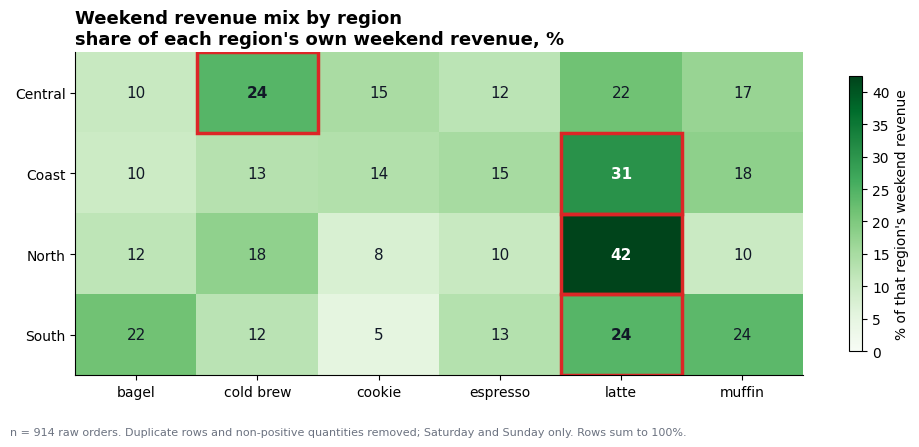

In [ ]:
# ---- the same answer, as the figure you would actually put in the deck ------
fig, ax = plt.subplots(figsize=(10, 4.2))

p9_vals = weekend_mix.to_numpy()
p9_hi   = p9_vals.max()
im = ax.imshow(p9_vals, cmap="Greens", aspect="auto", vmin=0, vmax=p9_hi)

ax.set_xticks(range(weekend_mix.shape[1]), weekend_mix.columns)
ax.set_yticks(range(weekend_mix.shape[0]), weekend_mix.index)
ax.grid(False)

for i, region in enumerate(weekend_mix.index):
    for j, product in enumerate(weekend_mix.columns):
        v = weekend_mix.iat[i, j]
        ax.text(j, i, f"{v:.0f}", ha="center", va="center", fontsize=11,
                color="white" if v > 0.6 * p9_hi else "#111827",
                weight="bold" if product == winner[region] else "normal")
    j = list(weekend_mix.columns).index(winner[region])          # ring the leader
    ax.add_patch(plt.Rectangle((j - 0.5, i - 0.5), 1, 1, fill=False,
                               edgecolor=C_NA, lw=2.5))

ax.set_title("Weekend revenue mix by region\n"
             "share of each region's own weekend revenue, %",
             loc="left", fontsize=13, weight="bold")
fig.colorbar(im, ax=ax, shrink=0.85, label="% of that region's weekend revenue")
fig.text(0.01, -0.05,
         f"n = {len(sales)} raw orders. Duplicate rows and non-positive "
         f"quantities removed; Saturday and Sunday only. Rows sum to 100%.",
         fontsize=8, color=C_GREY)
plt.tight_layout()
plt.show()


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

The table above as a figure that can leave the notebook on its own: the title states what is measured and in what units, the colour scale is sequential because a share has a meaningful zero, every cell is labelled so no one has to eyeball a colour, each region's leader is ringed and bolded, and the footnote records what was excluded and what the rows sum to. The one region whose ring sits in a different column is visible in half a second, which is the job. This is matplotlib rather than `.plot()` because rings, per-cell text colour and a footnote have no keyword — the escape hatch from 9.1, taken for the reason given there.

**The common misread:** comparing colour intensity *down* a column. Colour encodes share-of-region and every row was normalised separately, so a dark cell in one row and a dark cell in another mean "a large share of two different totals". The rings compare within rows, which is the only comparison this normalisation licenses — and it is why the footnote says the rows sum to 100.

</div>

### The chain, line by line

Ten steps, and every one is something an earlier part introduced.

| # | Step | What it does | Part |
|---|---|---|---|
| 1 | `.drop_duplicates()` | Removes the double-scanned batch. It goes first, because a duplicate row would otherwise be cleaned twice and then summed twice. | 4 |
| 2 | `.assign(date=…, unit_price=…, store=…, product=…)` | Four dtype and whitespace repairs in one call. `assign` takes keyword arguments, so all four `lambda d` see the same input frame. | 4, 5 |
| 3 | `.assign(region=… .fillna(d["store"].map(REGIONS)))` | The missing regions are not *unknown*, they are *unrecorded* — the store name determines the region, so a mapping recovers them exactly. Part 4 made the more conservative choice and labelled them `"Unassigned"`; both are defensible, and this one is only available because we repaired `store` first, in step 2. | 4 |
| 4 | `.loc[lambda d: d["quantity"] > 0]` | Drops the six impossible `-1`s **and** the unrecorded `NaN`s with one comparison, because `NaN > 0` is `False`. | 3, 4 |
| 5 | `.assign(revenue=…, weekend=…)` | Both derived columns, both vectorised, both one expression. `.dt.dayofweek >= 5` is the entire weekend test. | 5 |
| 6 | `.loc[lambda d: d["weekend"]]` | The filter the question asked for. Kept separate from step 5 so the boolean column exists as a column, rather than being buried in the mask. | 3 |
| 7 | `.groupby(["region", "product"])["revenue"].sum()` | Split-apply-combine on two keys. The result is a Series with a two-level index. | 6 |
| 8 | `.unstack("product")` | Moves the inner index level out into columns — long becomes wide, and the shape becomes something a human reads. | 7 |
| 9 | `.fillna(0.0)` | `unstack` creates a cell for every region×product pair; a pair that never sold on a weekend arrives as `NaN`, and here that genuinely means zero. | 4, 7 |
| 10 | `.pipe(lambda w: w.div(w.sum(axis=1), axis=0) * 100)` | Row-wise normalisation. The `axis=0` on `div` means "align the divisor on the index" — Part 1's alignment rule, doing real work. | 1, 7 |

**Why `lambda` inside `.loc` and `.assign`.** `sales.loc[sales["quantity"] > 0]`
would work here, but only because `sales` happens to still exist as a name.
Inside a chain there is no name for the intermediate frame, and `lambda d: …`
is how you refer to *whatever the previous step just produced*. That single
trick is what turns a pile of temporary variables into one expression — and it
is also why this chain never has to think about `SettingWithCopyWarning`: it
never assigns into anything, it only produces new frames.

**Why `.pipe` for the last step.** `.assign` adds columns; `.pipe` transforms
the frame as a whole. A row-wise normalisation needs every column at once, so
it cannot be an `assign`. `.pipe(f)` is just `f(df)`, written so that it stays
inside the chain instead of breaking it.

**And note what is *not* in the chain.** No loop. No `if`. No index bookkeeping.
No temporary DataFrame you have to remember the name of. That is what the
previous eight parts were for.


---

## 9.4 The whole notebook, on one page

### Cheat sheet — operation, syntax, and the thing that bites

| Operation | Syntax | The gotcha |
|---|---|---|
| Column | `df[["a", "b"]]` | `df["a"]` is a Series, `df[["a"]]` is a DataFrame. Different objects, different methods. |
| Rows by label | `df.loc[3:5]` | `.loc` slices are **inclusive** of the endpoint. `.iloc[3:5]` is not. |
| Rows by position | `df.iloc[3:5]` | Positions ignore the index. After a filter, row `0` may carry label `417`. |
| Boolean filter | `df[df["q"] > 5]` | Needs `&`, `\|`, `~` — not `and`, `or`, `not` — and each clause needs its own parentheses. |
| Readable filter | `df.query("q > 5 and r > 4")` | Column names with spaces need backticks; Python variables need `@`. |
| Find missing | `df.isna().sum()` | `NaN != NaN`, so `s == np.nan` is never true. `None` in a text column counts as missing too. |
| Fill missing | `df["c"].fillna(v)` | One `.fillna(0)` across a whole frame is almost always wrong: different columns are missing for different reasons. |
| Duplicates | `df.drop_duplicates(subset=…)` | Keeps the **first** by default. Without `subset` it compares every column, including ones you do not care about. |
| Cast dtype | `s.astype("float64")` | Raises on bad values — a feature. Use `pd.to_numeric(s, errors="coerce")` when you want `NaN` instead, then count what it ate. |
| Category | `s.astype("category")` | Large memory win on repeated labels; changes `groupby` behaviour via `observed=`. |
| Strings | `s.str.strip().str.title()` | `.str` propagates missing values rather than raising — a `NaN` stays `NaN`, it does not become `"nan"`. |
| Parse dates | `pd.to_datetime(s, format=…)` | Without `format=`, inference is a *guess* that can differ between files. Pass it. |
| Date parts | `s.dt.dayofweek` | Monday is `0`, so weekends are `>= 5`. `.dt.week` is gone — use `.dt.isocalendar().week`. |
| New column | `df.assign(c=lambda d: …)` | Returns a **new** frame. `df["c"] = …` mutates in place: fine at top level, impossible in a chain. |
| Row-wise rule | `np.select([conds], [vals], default=)` | The alternative is `.apply(axis=1)`, and §9.2 measured exactly what that costs. |
| Group | `df.groupby("k")["v"].sum()` | `dropna=True` by default: rows with a missing key **vanish**, and your totals no longer add up. |
| Named agg | `.agg(x=("v", "sum"))` | `agg` reduces, `transform` returns the original shape, `apply` does whatever the function does. Choose deliberately. |
| Long → wide | `df.pivot_table(…)` | `pivot` raises on duplicate index/column pairs; `pivot_table` silently *averages* them. Know which you asked for. |
| Wide → long | `df.melt(id_vars=[…])` | Everything not named in `id_vars` gets melted — including the column you forgot about. |
| Join | `a.merge(b, on="k", how="left")` | Check `len()` before and after. A many-to-many join multiplies rows and looks like success. |
| Stack | `pd.concat([a, b])` | Duplicate index labels survive. Pass `ignore_index=True` unless the index means something. |
| Resample | `s.resample("ME").sum()` | Needs a `DatetimeIndex`, and the last bucket is usually partial. |
| Rolling | `s.rolling(7).mean()` | The first six values are `NaN` by design. `min_periods=1` removes them and changes the meaning. |
| Plot | `df.plot(kind="bar")` | The index is the x-axis. If the chart looks wrong, the index is wrong. |
| Memory | `df.memory_usage(deep=True)` | Without `deep=True` you are counting pointers, not characters. |
| Copy | `df.copy()` | A slice may be a view. `.copy()` is how you stop "may" from being part of the sentence. |

### 10 mistakes that will bite you

1. **`and` / `or` inside a boolean mask.** `df[a > 1 and b > 2]` raises *"the
   truth value of a Series is ambiguous"*. Element-wise logic is `&`, `|`, `~`
   — and they bind *tighter* than `>`, so every clause needs parentheses.
2. **Chained assignment.** `df[df.a > 1]["b"] = 0` writes into a temporary
   object and throws it away. One `.loc` instead: `df.loc[df.a > 1, "b"] = 0`.
3. **Forgetting that operations return copies.** `df.dropna()` does not modify
   `df`. Neither do `rename`, `sort_values`, `reset_index`, `fillna`, `astype`,
   `drop_duplicates` or `assign`. Bind the result or nothing happened.
4. **`.iloc` when you meant `.loc`.** After any filter, position and label
   disagree. `.iloc[0]` is the first row *now*; `.loc[0]` is the row that was
   first before you filtered — if it survived at all.
5. **Comparing against `np.nan`.** `NaN == NaN` is `False`, so `s == np.nan`
   selects nothing, silently. Use `.isna()`.
6. **A blanket `.fillna(0)`.** Zero is a value. A missing rating filled with
   zero drags the mean down and invents a one-star review nobody wrote.
7. **`groupby` quietly dropping missing keys.** Rows whose key is `NaN` are
   excluded by default, so the group totals do not reconcile with the frame
   total and nothing warns you. `dropna=False` keeps them visible.
8. **Merging without checking the row count.** `len(merged) > len(left)` on a
   left join means the key was not unique on the right, and every downstream
   sum is now inflated. Check every single time.
9. **Assuming the index is decoration.** Arithmetic between Series aligns on
   the **index**, not on position. Two same-length Series with different
   indexes give you a longer result full of `NaN`, not an element-wise sum.
10. **Writing a `for` loop over rows.** Whatever the loop does, some
    combination of `np.select`, `.where`, `.map`, a vectorised expression or a
    `groupby` does it — and §9.2 measured the difference on a rule that
    genuinely reads two columns and branches.

### Exercises

No solutions. Each one is answerable with operations from this notebook, and
each states a check so you know when you are right.

1. **The weekday version.** Rerun the capstone chain for weekdays instead of
   weekends by changing one character, binding the result as `weekday_mix`.
   Then compute `weekend_mix - weekday_mix` and name the single region×product
   cell that moves most. *Check: the difference frame has the same shape as
   `weekend_mix`, and every one of its rows sums to approximately zero — if
   yours does not, you normalised before subtracting somewhere you should not
   have.*

2. **Dollars, not shares.** Produce the same table in absolute revenue by
   deleting exactly one step from the chain, then answer a question the share
   table cannot: which region takes the most weekend money in total? *Check:
   the grand total of your table should equal
   `tidy.loc[tidy["is_weekend"], "revenue"].sum()` — and if it does not,
   work out which cleaning step differs between `tidy` and the capstone chain.
   That discrepancy is the exercise.*

3. **Make the loop hurt.** Time `discount_iterrows` on
   `pd.concat([tidy] * 50, ignore_index=True)`. Predict the runtime *first*,
   from the per-row microsecond cost §9.2 printed, then measure. *Check: your
   prediction should land within roughly 20% of the measurement. If it is far
   off, you have found a cost that is not linear in the number of rows — what
   is it, and does `.itertuples()` have the same problem?*

4. **A chunked mean.** The chunking cell computed a sum, which is associative.
   Compute the **mean rating** over the same temporary CSV using `chunksize`,
   without ever holding the full frame. *Hint: one accumulator is not enough,
   and `rating` has missing values, so `len(chunk)` is the wrong denominator.
   Check: `np.isclose` against the whole-file `.mean()`.*

5. **A chart that survives a sceptic.** Pick one claim from the capstone — say,
   that one region's leading product differs from the rest — and build a single
   figure that a sceptic could not wave away: show the sample size behind each
   cell, or the same breakdown month by month to prove it is not one good
   weekend. Write the caption first, then build the chart that earns it.
   *Check: your caption ends with "The common misread:" and you can honestly
   finish that sentence.*

### References

- **pandas User Guide** — `pandas.pydata.org/docs/user_guide/index.html`.
  *10 minutes to pandas* is the fastest re-orientation; *Indexing and selecting
  data*, *Group by*, *Reshaping and pivot tables* and *Time series* are the
  four pages that repay a full read.
- **Enhancing performance** —
  `pandas.pydata.org/docs/user_guide/enhancingperf.html`. The official version
  of §9.2, including the `eval`/`query` internals and the Cython and Numba
  escape hatches this notebook did not cover.
- **Scaling to large datasets** —
  `pandas.pydata.org/docs/user_guide/scale.html`. Chunking, dtype choice, and
  the project's own honest account of when to leave pandas.
- **Visualization** —
  `pandas.pydata.org/docs/user_guide/visualization.html`. Every `kind=` with a
  picture, plus the plotting backends.
- **Copy-on-Write** —
  `pandas.pydata.org/docs/user_guide/copy_on_write.html`. Why the
  view-versus-copy trap behaves differently in modern pandas than in the Stack
  Overflow answers you will find for it.
- **Comparison with SQL, spreadsheets and R** —
  `pandas.pydata.org/docs/getting_started/comparison/index.html`. If you
  already think in one of those, this is the shortest bridge.

---
## 🗺️ The Ten Parts

Each part builds on the one before it, on a single dataset that is introduced in Part 0 and never leaves. By the end you will have cleaned it, reshaped it, grouped it, resampled it and plotted it.

| Part | What it covers | |
|---|---|---|
| **0** | Why pandas, and the one dataset we use |
| **1** | Series and DataFrame: the two objects |
| **2** | Loading data and looking at it |
| **3** | Selection: loc, iloc, and boolean masks |
| **4** | Cleaning: missing values, dtypes, duplicates |
| **5** | Transforming: vectorised ops, strings, dates |
| **6** | GroupBy: split, apply, combine |
| **7** | Reshaping: pivot, melt, merge, concat |
| **8** | Time series: resampling and rolling windows |
| **9** | Plotting, performance, and a capstone |  &larr; **you are here**


<div style="background: linear-gradient(135deg, #11998e 0%, #38ef7d 100%); padding: 28px; border-radius: 18px; color: white; margin: 12px 0;">


### 🐼 That is the whole thing.

You started with a frame that had text where the numbers should be, missing
values in three columns for three different reasons, fourteen duplicated rows
and six impossible quantities. You finished with a ten-step expression that
turns it into an answer, and a figure you would put in front of a manager.

Nothing in that chain was exotic. `drop_duplicates`, `assign`, `loc`, `groupby`,
`unstack`, `div`. The distance between here and where you started is not more
API surface — it is knowing which six of them, in which order, and what each one
does to the index on the way through.

**The index is the thing.** If you keep one sentence from nine parts, keep that
one. pandas aligns on the index, plots against the index, groups into an index
and joins on an index. Every surprise in this notebook was the index doing
something you had not thought about yet.

Now go break something with real data.


</div>